# Simple plots for GRL paper

In [247]:
import os
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.optimize import minimize

import statsmodels.api as sm

In [248]:
import seaborn as sns

## Font solutions:
## https://alexanderlabwhoi.github.io/post/2021-03-missingfont/

# print(mpl.matplotlib_fname())
# mpl.rcParams['font.family'] = 'sans-serif'
# mpl.rcParams['font.sans-serif'] = 'Arial'

# mpl.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
#     "mathtext.fontset": "stixsans",
# })

### EARLIER VERSION
# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["STIXGeneral"],  # or "CMU Serif"
#     "mathtext.fontset": "cm",
#     "mathtext.rm": "serif",
#     "mathtext.it": "serif:italic",
#     "mathtext.bf": "serif:bold",
# })

### JCLI Test
sns.set_context("paper")
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["TeX Gyre Termes", "Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",         # matches Times-style math
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
})

# Tell matplotlib to embed fonts properly for AMS journals
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


In [249]:
global_dpath = '~/work/hist_sst/data/'

In [250]:
## Keep full data handy, but choose calculation period in one place
data_tsel = slice(2001, 2024)
default_tsel = slice(2001, 2024)
alt_tsel = slice(2006, 2024)

## keep this alias so older cells still run
ceres_tsel = default_tsel


# Functions

In [251]:
def hac_trend(y, years=None, maxlags=2):
    y = np.asarray(y, dtype=float)

    if years is None:
        years = np.arange(len(y), dtype=float)
    else:
        years = np.asarray(years, dtype=float)

    mask = np.isfinite(y) & np.isfinite(years)
    y = y[mask]
    years = years[mask]

    ## center time so the intercept is the value near the middle of the period
    t = years - years.mean()

    ## fit y = a + b*t
    X = sm.add_constant(t)
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    trend_per_year = fit.params[1]
    se_per_year = fit.bse[1]

    trend_per_decade = 10 * trend_per_year
    se_per_decade = 10 * se_per_year

    return {
        "trend_per_decade": trend_per_decade,
        "se_per_decade": se_per_decade,
        "ci90_per_decade": (
            trend_per_decade - 1.645 * se_per_decade,
            trend_per_decade + 1.645 * se_per_decade,
        ),
        "fit": fit,
    }

# ERF

In [252]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'

In [253]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(2000, 2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")
erf_total_all = erf_total.sel(time=data_tsel)


CPU times: user 204 ms, sys: 963 ms, total: 1.17 s
Wall time: 3.14 s


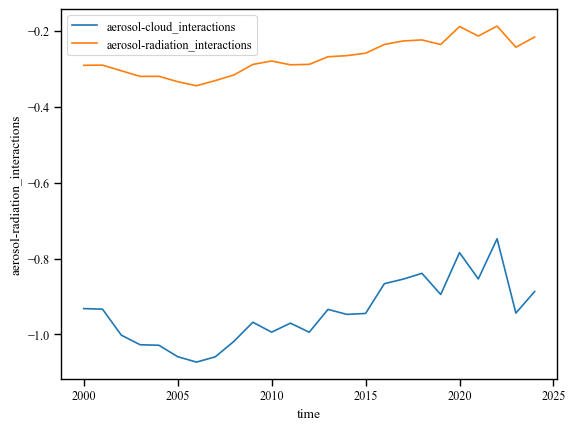

In [254]:
key = 'volcanic'
for key in [
           'aerosol-cloud_interactions',
           'aerosol-radiation_interactions']:
    ds_erf[key].mean(dim='ensemble').plot(label=key)

plt.legend()
plt.show()

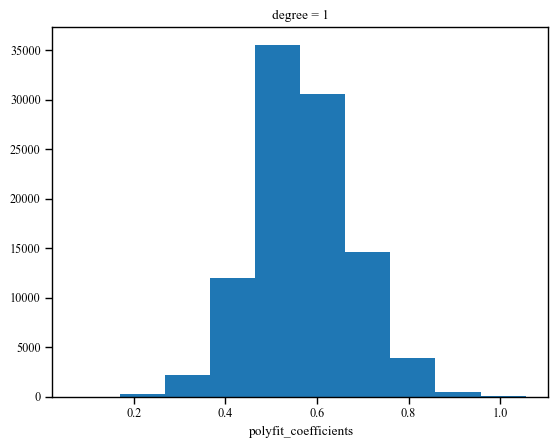

[0.4037941  0.56274148 0.75457697]
<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.57)
Coordinates:
    degree   int64 8B 1 0.1074034812746195


In [255]:
dFdt = 10*erf_total.sel(time=ceres_tsel).polyfit(deg=1,dim='time').polyfit_coefficients[0]

dFdt.plot.hist()
plt.show()

print(dFdt.quantile([0.05,0.50, 0.95]).values)
print(dFdt.mean().round(2), dFdt.std().values)

In [256]:
## set parameters
dFdt_mu = dFdt.mean().values
dFdt_sig = dFdt.std(ddof=1).values
print(dFdt_mu.round(2), dFdt_sig.round(2))

0.57 0.11


## N (EEI): TOA imbalance

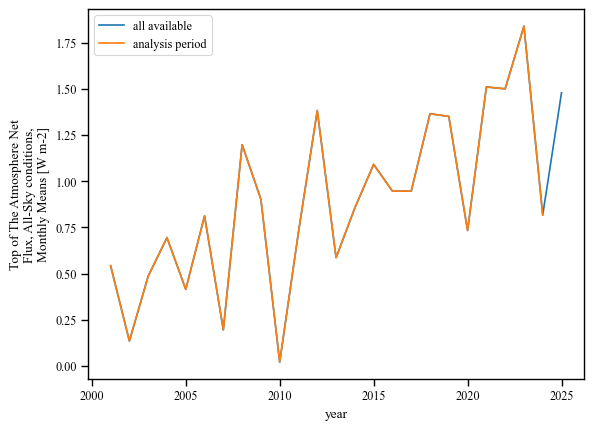

In [257]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01', '2025-12-31')
).groupby('time.year').mean()

N_all = ceres['gtoa_net_all_mon'].sel(year=data_tsel)
N = N_all.sel(year=ceres_tsel)

ceres['gtoa_net_all_mon'].plot(label='all available')
N.plot(label='analysis period')
plt.legend()
plt.show()


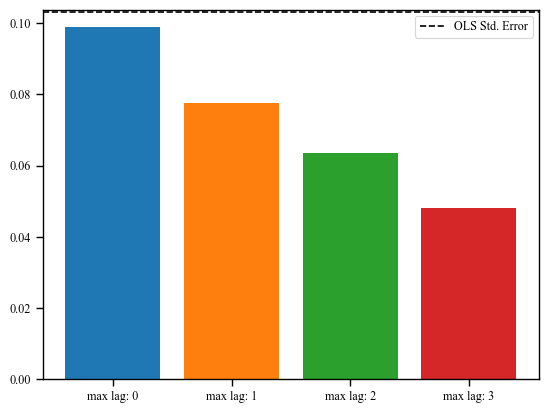

In [258]:
## no ensemble, so check std error of regression different ways

for i in np.arange(0,4,1):
    plt.bar(x='max lag: ' + str(i),height=hac_trend(N,maxlags=i)['se_per_decade'])

plt.axhline(linregress(N.year, N).stderr*10,c='k',label='OLS Std. Error',ls='--')
plt.legend()
# plt.ylim(0,.11)
plt.show()

In [259]:
## set parameters
ols_N = linregress(N.year, N)
dNdt_mu = 10 * ols_N.slope
dNdt_sig = 10 * ols_N.stderr
print(dNdt_mu.round(2), dNdt_sig.round(2))

0.45 0.1


# Temperature

In [260]:
gmst_dict = {}

In [281]:
## Thorne
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/ipcc_ensemble.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
).sel(year=data_tsel)

gmst_dict['Thorne'] = gmst_ens


In [262]:
## HadCRUT5.1
path = global_dpath + 'other_recon/hadcrut5/'
fname = 'HadCRUT.5.1.0.0.analysis.ensemble_series.global.monthly.nc'
gmst_dict['HadCRUT5.1'] = (
    xr.open_dataset(path + fname)['tas']
    .sel(time=slice('2001-01-01', '2025-12-31'))
    .groupby('time.year')
    .mean()
    .sel(year=data_tsel)
).rename({'realization': 'ens'})

gmst_dict['HadCRUT5.1']


<xarray.DataArray 'tas' (ens: 200, year: 24)> Size: 38kB
array([[0.49662672, 0.53741708, 0.53343155, ..., 0.76944539, 1.10327949,
        1.15466701],
       [0.48377238, 0.51805041, 0.53147202, ..., 0.7894848 , 1.10699201,
        1.20103332],
       [0.48640502, 0.53506828, 0.55500261, ..., 0.8181999 , 1.10440103,
        1.18334382],
       ...,
       [0.50361812, 0.53349545, 0.54329597, ..., 0.81511452, 1.1149777 ,
        1.20507676],
       [0.48853593, 0.5338186 , 0.57660255, ..., 0.81380523, 1.09472718,
        1.17325025],
       [0.47725965, 0.54824253, 0.52117868, ..., 0.83356543, 1.11384827,
        1.15010459]], shape=(200, 24))
Coordinates:
  * ens        (ens) int64 2kB 1 2 3 4 5 6 7 8 ... 194 195 196 197 198 199 200
  * year       (year) int64 192B 2001 2002 2003 2004 ... 2021 2022 2023 2024
    latitude   float64 8B ...
    longitude  float64 8B ...
Attributes:
    long_name:     blended air_temperature_anomaly over land with sea_water_t...
    units:         K
    cell_methods:  area: mean (interval: 5.0 degrees_north 5.0 degrees_east) ...

In [263]:
## Cooper et al. 2025
path = global_dpath + 'public_share/ens_members/'
fname = 'ensmembers_tas_1850-2023.nc'
c25_load = xr.open_dataset(path + fname)['gmean'].sel(time=slice('2001-01-01', '2025-01-01'))
c25_load = c25_load.rename({'ens': 'ensemble'})
c25_tas = (
    c25_load
    .groupby('time.year')
    .mean(dim=['time'])
    .stack(ens=['prior', 'ensemble'])
    .sel(year=data_tsel)
)

gmst_dict['C25'] = c25_tas



HadCRUT5.1
 0.242 0.005
0.233 0.242 0.252

C25
 0.239 0.022
0.203 0.24 0.28

Thorne
 0.249 0.015
0.225 0.249 0.274


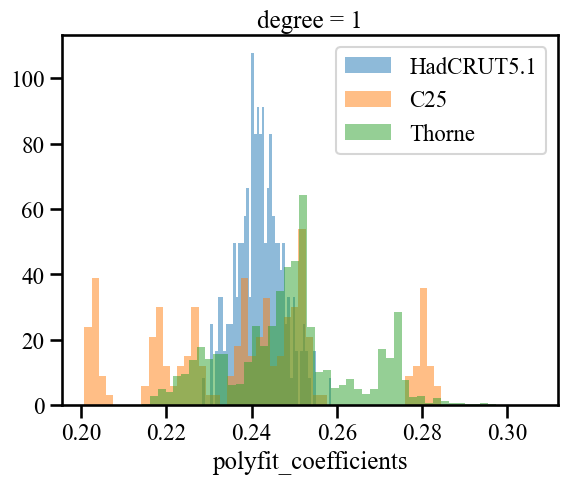

In [282]:
for key,ds in gmst_dict.items():
    # dTdt = gmst_ens.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Thorne et al.',density=True)
    
    # dTdt = c25_tas.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Cooper et al. 2025',density=True)
    
    dTdt = 10*gmst_dict[key].polyfit(deg=1,dim='year').polyfit_coefficients[0]
    dTdt.plot.hist(bins=50,alpha=0.5,label=key,density=True)

    print('\n' + key + '\n', dTdt.mean().round(3).values, dTdt.std(ddof=1).round(3).values)
    print(dTdt.quantile(0.05).round(3).values, dTdt.quantile(0.5).round(3).values, dTdt.quantile(0.95).round(3).values)
plt.legend()
plt.show()

In [283]:
for i in range(8):
    temp = dTdt.unstack().isel(prior=i)
    temp.plot.hist(label=temp.prior.values,alpha=0.5)
plt.legend()
plt.show()

ValueError: Dimensions {'prior'} do not exist. Expected one or more of ('ensemble',)

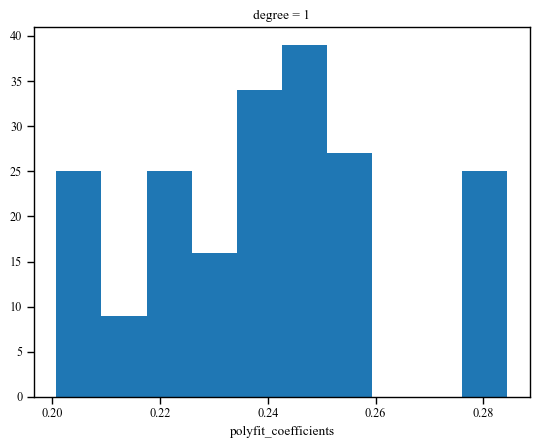

In [266]:
## choose middle
dTdt_mu  = 0.23
dTdt_sig = 0.013 # also matches BEST
dTdt.unstack().plot.hist()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

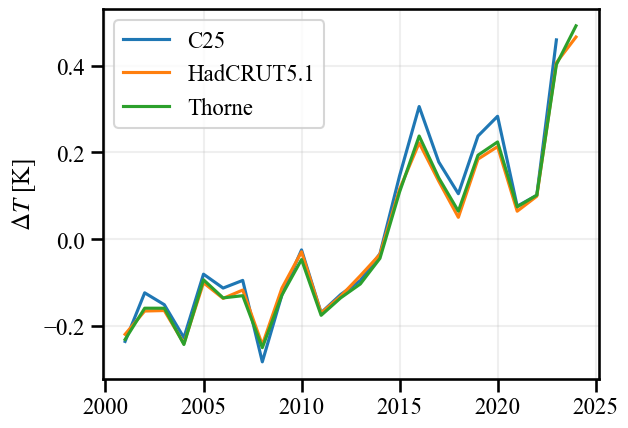

In [284]:
sns.set_context('talk')
key='C25'
(gmst_dict[key].mean(dim='ens') - gmst_dict[key].mean()).plot(label=key)

key='HadCRUT5.1'
(gmst_dict[key].mean(dim='ens') - gmst_dict[key].mean()).plot(label=key)

key='Thorne'
(gmst_dict[key].mean(dim='ensemble') - gmst_dict[key].mean()).plot(label=key)

plt.legend()
plt.xlabel('')
plt.ylabel('$\Delta T$ [K]')
plt.grid(alpha=0.2)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

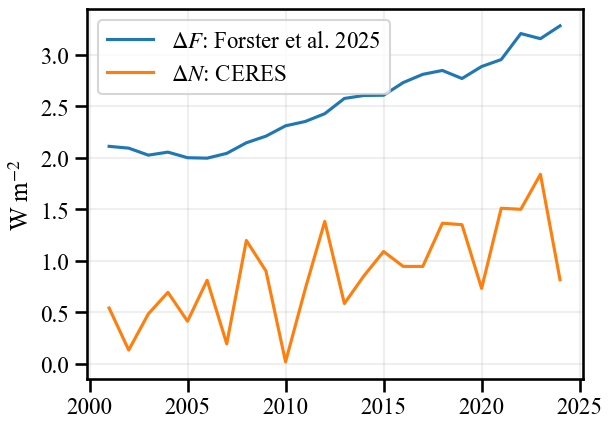

In [285]:
sns.set_context('talk')
key='$\Delta F$: Forster et al. 2025'
erf_total.sel(time=ceres_tsel).mean(dim='ensemble').plot(label=key)


N.plot(label='$\Delta N$: CERES')

plt.legend()
plt.xlabel('')
plt.ylabel('W m$^{-2}$')
plt.grid(alpha=0.2)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

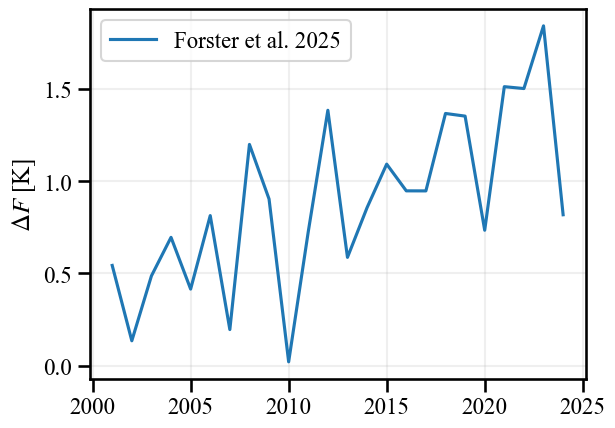

In [286]:
sns.set_context('talk')
key='Forster et al. 2025'
ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).plot(label=key)

plt.legend()
plt.xlabel('')
plt.ylabel('$\Delta F$ [K]')
plt.grid(alpha=0.2)
plt.show


# Pattern Effect

In [270]:
# from C25
dlamb_mu = 0.09 #median, mean is 0.09 for 2001-2023
dlamb_sig = 0.29 # all spread, including ic error

dlamb_mu = 0.00 #median, mean is 0.09 for 2001-2023
# dlamb_sig = 0.175 # cross-model spread, including ic error
dlamb_sig = 0.2 # cross-model spread, including ic error

# Correlated errors in N and T

In [271]:
## add internal low-frequency variability in 23-year N and T trends
## estimated from non-overlapping piControl blocks in CESM2 and MPI-ESM1-2-LR

# ## 2001-2023
# iv_cov_cesm2 = np.array([
#     [0.048707**2, -0.001062],
#     [-0.001062,  0.104263**2],
# ])

# iv_cov_mpi = np.array([
#     [0.063137**2, -0.003081],
#     [-0.003081,  0.080356**2],
# ])

# ## 2006-2023
# iv_cov_cesm2 = np.array([
#     [0.075808**2, -0.002138],
#     [-0.002138,  0.144837**2],
# ])

# iv_cov_mpi = np.array([
#     [0.067820**2, -0.003764],
#     [-0.003764,  0.124949**2],
# ])

## 2006-2024 (63 blocks CESM2, 52 for MPI)
iv_cov_cesm2 = np.array([
    [0.074407**2, -0.002356],
    [-0.002356,  0.131178**2],
])

iv_cov_mpi = np.array([
    [0.065739**2, -0.003584],
    [-0.003584,  0.118013**2],
])


## simple equal-model average covariance matrix
iv_cov = 0.5 * (iv_cov_cesm2 + iv_cov_mpi)

# Monte Carlo

In [272]:
rng = np.random.default_rng(123)
mc_n = 100000

In [273]:
## rows are [dT internal variability, dN internal variability]
iv_err = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=iv_cov,
    size=mc_n,
)

Tdot_ens_iv = iv_err[:, 0]
Ndot_ens_iv = iv_err[:, 1]

print("internal variability covariance matrix:")
print(pd.DataFrame(iv_cov, index=["dTdt", "dNdt"], columns=["dTdt", "dNdt"]))

print("\nadded internal variability:")
print("sigma dTdt =", np.sqrt(iv_cov[0, 0]).round(4), "K/dec")
print("sigma dNdt =", np.sqrt(iv_cov[1, 1]).round(4), "W/m2/dec")
print("corr =", (iv_cov[0, 1] / np.sqrt(iv_cov[0, 0] * iv_cov[1, 1])).round(3))

internal variability covariance matrix:
          dTdt      dNdt
dTdt  0.004929 -0.002970
dNdt -0.002970  0.015567

added internal variability:
sigma dTdt = 0.0702 K/dec
sigma dNdt = 0.1248 W/m2/dec
corr = -0.339


In [274]:
rng = np.random.default_rng(123)
mc_n = 1000000

## F2x
F2x_ens = rng.normal(loc= 3.93, scale=0.29, size=mc_n)

In [275]:
## T
key = 'HadCRUT5.1'
Tin = 10*gmst_dict[key].polyfit(deg=1,dim='year').polyfit_coefficients[0]
Tdot_ens = rng.choice(Tin, size=mc_n, replace=True) + Tdot_ens_iv/10
plt.hist(Tdot_ens)
plt.hist(rng.choice(Tin, size=mc_n, replace=True),alpha=0.2)
plt.show()

ValueError: operands could not be broadcast together with shapes (1000000,) (100000,) 

In [276]:
## N
Ndot_ens = rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n) + Ndot_ens_iv/10
plt.hist(Ndot_ens)
plt.hist(rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n),alpha=0.4)
plt.show()

ValueError: operands could not be broadcast together with shapes (1000000,) (100000,) 

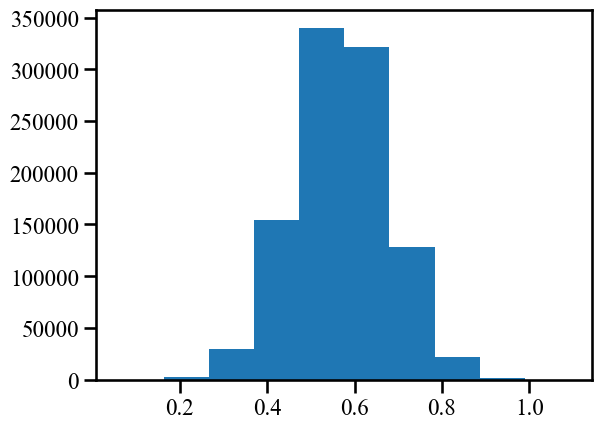

In [277]:
## F
Fdot_ens = rng.normal(loc=dFdt_mu, scale=dFdt_sig, size=mc_n)
plt.hist(Fdot_ens)
plt.show()

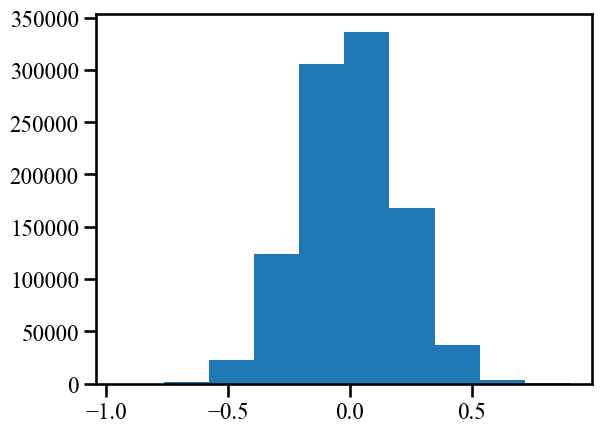

In [278]:
## dlamb
dlamb_ens = rng.normal(loc=dlamb_mu, scale=dlamb_sig, size=mc_n)
plt.hist(dlamb_ens)
plt.show()

In [122]:
lam_ens = (Ndot_ens - Fdot_ens) / Tdot_ens + dlamb_ens
lam_ens = lam_ens[np.isfinite(lam_ens)]

kde = gaussian_kde(lam_ens)

# lam_grid = np.linspace(*np.quantile(lam_ens, [0.001, 0.999]), 1000)
lam_grid = np.linspace(-10,10, 1000)
loglike = np.log(kde(lam_grid))
loglike -= loglike.max()  # optional normalization for plotting

/glade/derecho/scratch/vcooper/tmp/ipykernel_7799/2387335318.py:8: RuntimeWarning: divide by zero encountered in log
  loglike = np.log(kde(lam_grid))


In [123]:
%%time
### SCORE T version
### Score N version

like_N = np.zeros(len(lam_grid))
like_T = np.zeros(len(lam_grid))

for i,lam in enumerate(lam_grid):
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

like_N = like_N/like_N.max()
like_T = like_T/like_T.max()

CPU times: user 20.9 s, sys: 34.4 ms, total: 21 s
Wall time: 23.4 s


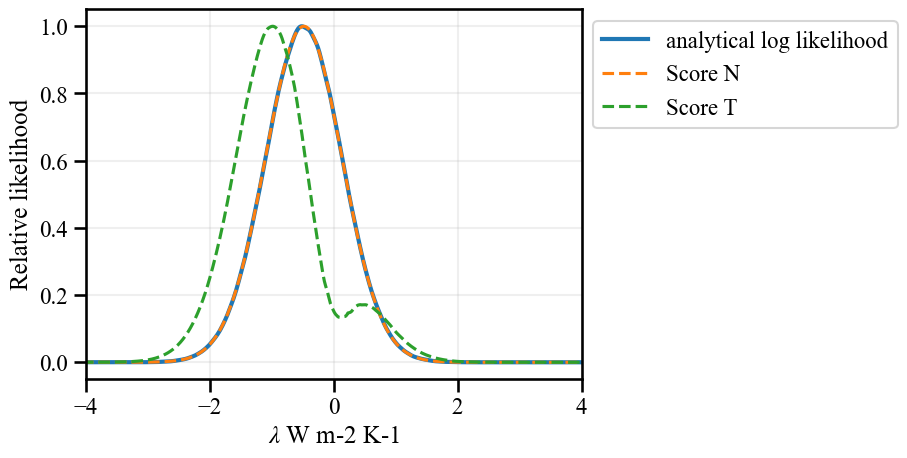

In [124]:
like_N = like_N/like_N.max()
like_T = like_T/like_T.max()
# plt.plot(lam_grid,kde(lam_grid)/kde(lam_grid).max(), label='analytical likelihood',lw=4)
plt.plot(lam_grid,np.exp(loglike), label='analytical log likelihood',lw=3)
plt.plot(lam_grid,like_N,label='Score N',ls='--')
plt.plot(lam_grid,like_T,label='Score T',ls='--')
plt.xlabel('$\lambda$ W m-2 K-1')
plt.ylabel('Relative likelihood')
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=[1,1])

plt.xlim(-4,4)
plt.show()

In [125]:
# S_grid = np.linspace(0.1, 10, 500)  ## choose ECS range to plot
S_grid = np.linspace(0.01, 20, 500)  ## choose ECS range to plot

lam_from_S = -3.93 / S_grid
# lam_from_S = -F2x_ens / S_grid

loglike_S = np.log(kde(lam_from_S))
loglike_S -= np.nanmax(loglike_S)

/glade/derecho/scratch/vcooper/tmp/ipykernel_7799/3007673596.py:7: RuntimeWarning: divide by zero encountered in log
  loglike_S = np.log(kde(lam_from_S))


In [126]:
%%time
### SCORE T version
### Score N version

S_like_N = np.zeros(len(S_grid))
S_like_T = np.zeros(len(S_grid))

for i,s in enumerate(S_grid):
    lam = -F2x_ens/s
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    S_like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    S_like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

S_like_N = S_like_N/S_like_N.max()
S_like_T = S_like_T/S_like_T.max()

CPU times: user 12.8 s, sys: 13.2 ms, total: 12.8 s
Wall time: 14 s


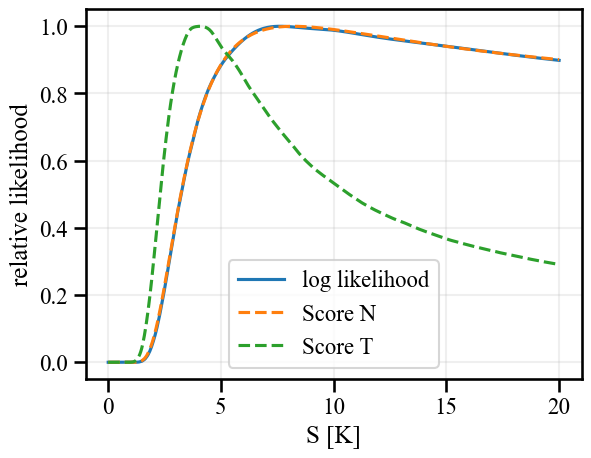

In [127]:
plt.plot(S_grid,np.exp(loglike_S), label='log likelihood')
plt.plot(S_grid,S_like_N,label='Score N',ls='--')
plt.plot(S_grid,S_like_T,label='Score T',ls='--')

plt.xlabel("S [K]")
plt.ylabel("relative likelihood")
# plt.xlim(0,10)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

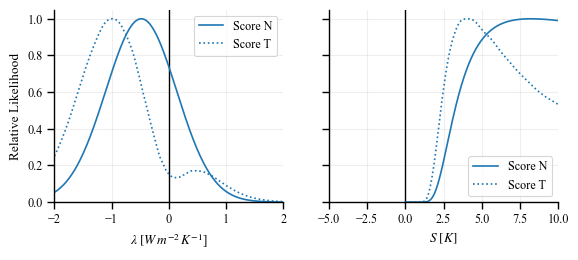

In [128]:
## Combined likelihood: my preferred figure
sns.set_context('paper')
fig, axs = plt.subplots(1,2, figsize=(6.5,2.5), sharey=True)
comc ='tab:blue'
plt.sca(axs[0])

# plt.plot(lam_grid,np.exp(loglike), label='analytical log likelihood',lw=3)
like_N = like_N/like_N.max()
like_T = like_T/like_T.max()
plt.axvline(0,c='k',lw=1)
plt.plot(lam_grid,like_N,label='Score N',ls='-', c=comc)
plt.plot(lam_grid,like_T,label='Score T',ls=':', c=comc)
plt.xlabel('$\lambda \ [W \, m^{-2} \, K^{-1}$]')
plt.ylabel('Relative Likelihood')
plt.grid(alpha=0.2)
plt.legend()
plt.xlim(-2,2)
# plt.legend(bbox_to_anchor=[1,1])

plt.sca(axs[1])
plt.axvline(0,c='k',lw=1)
# plt.plot(S_grid,np.exp(loglike_S), label='log likelihood')
plt.plot(S_grid,S_like_N,label='Score N',ls='-', c=comc)
plt.plot(S_grid,S_like_T,label='Score T',ls=':', c=comc)

plt.xlabel("$S \ [K]$")
# plt.ylabel("Relative Likelihood")
plt.xlim(-5,10)
plt.ylim(0,)
plt.grid(alpha=0.2)
plt.legend()

sns.despine()

plt.show()

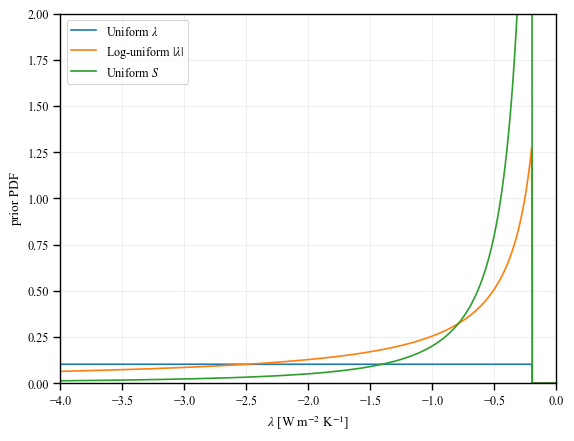

In [129]:
c = 3.93

lam_lo = -10
lam_hi = -0.2   ## corresponds to S ≈ 20 K

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area

## make sure lambda grid is increasing
lam_plot = np.linspace(lam_lo, 0, 2000)

## uniform lambda prior
pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

## log-uniform |lambda| prior, equivalently log-uniform S
pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

## uniform S prior
pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = 1 / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)

plt.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$')
plt.plot(lam_plot, pL_log_uniform, label=r'Log-uniform $|\lambda|$')
plt.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$')

plt.ylim(0,2)
plt.xlim(-4, 0)
plt.xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
plt.ylabel('prior PDF')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

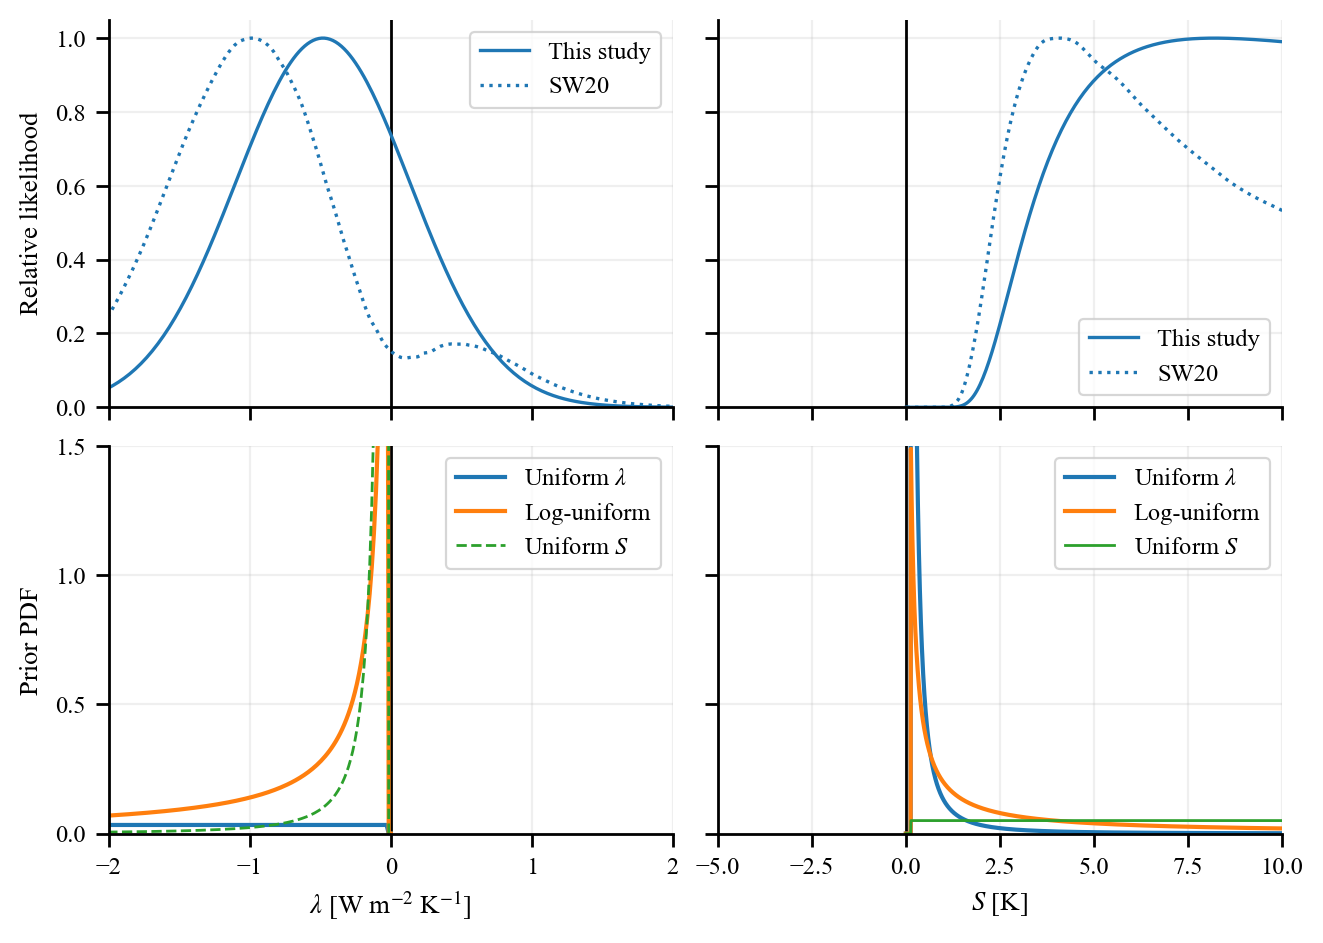

In [130]:
## Combined likelihood + priors
sns.set_context('paper')

c = 3.93
comc = 'tab:blue'

lam_lo = -30
lam_hi = -0.02   ## 0.2 corresponds to S ≈ 20 K

S_lo = -c / lam_lo
S_hi = -c / lam_hi

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf


## ---------- prior PDFs in lambda space ----------

lam_plot = np.linspace(lam_lo, 0, 2000)

pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = c / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)


## ---------- prior PDFs in S space ----------

S_plot = np.linspace(0, 20, 3000)

pS_uniform_lam = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_lam[mask] = c / S_plot[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_plot)

pS_log_uniform = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_log_uniform[mask] = 1 / S_plot[mask]
pS_log_uniform = normalize(pS_log_uniform, S_plot)

pS_uniform_S = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_plot)


## ---------- figure ----------

fig, axs = plt.subplots(
    2, 2,
    figsize=(6.5, 4.6),
    sharex='col',sharey='row',
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1., 1]},
    dpi=200,
)

## lambda likelihood
ax = axs[0, 0]
like_N = like_N / like_N.max()
like_T = like_T / like_T.max()

ax.axvline(0, c='k', lw=1)
ax.plot(lam_grid, like_N, label='This study', ls='-', c=comc)
ax.plot(lam_grid, like_T, label='SW20', ls=':', c=comc)
ax.set_ylabel('Relative likelihood')
ax.set_xlim(-2, 2)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## S likelihood
ax = axs[0, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_grid, S_like_N, label='This study', ls='-', c=comc)
ax.plot(S_grid, S_like_T, label='SW20', ls=':', c=comc)
ax.set_xlim(-5, 10)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## lambda priors
ax = axs[1, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$', lw=1.5)
ax.plot(lam_plot, pL_log_uniform, label=r'Log-uniform', lw=1.5, ls='-')
ax.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$', lw=1, ls='--')
ax.set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
ax.set_ylabel('Prior PDF')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.2)
ax.legend()
ax.set_yticks(np.arange(0,1.51,0.5))

## S priors
ax = axs[1, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, pS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5,ls='-')
ax.plot(S_plot, pS_log_uniform, label=r'Log-uniform', lw=1.5, ls='-')
ax.plot(S_plot, pS_uniform_S, label=r'Uniform $S$', lw=1, ls='-')
ax.set_xlabel(r'$S$ [K]')
ax.set_xlim(-5, 10)
ax.set_ylim(0, 1.5)
ax.grid(alpha=0.2)
ax.legend()

sns.despine()
plt.show()

## Combined all with posteriors

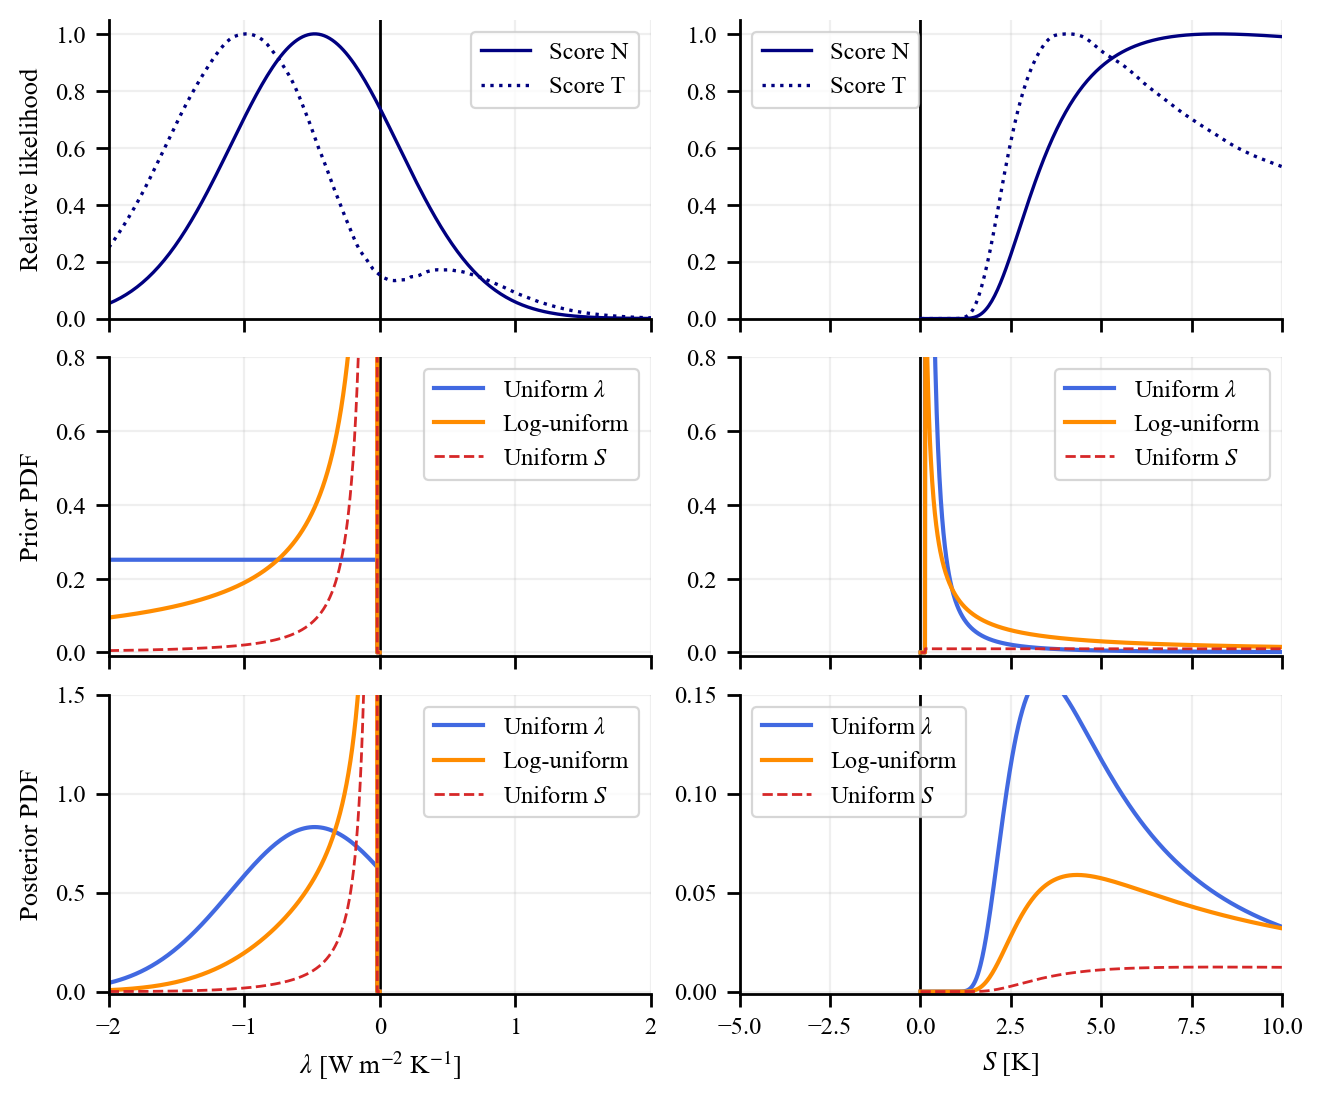

0.2 -19.65 0.0
0.5 -7.86 0.0
1 -3.93 3.3341420278786336e-22
1.5 -2.62 0.002020760406083424
2 -1.965 0.038935355773954634
3 -1.31 0.2649414431256977
4 -0.9825 0.46376921057880477


In [131]:
## Combined likelihood + priors + posteriors
sns.set_context('paper')

c = 3.93
comc = 'tab:blue'

lam_lo = -30
lam_hi = -0.02   ## -0.2 corresponds to S ≈ 20 K; -0.02 corresponds to S ≈ 200 K

S_lo = -c / lam_lo
S_hi = -c / lam_hi

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf


## ---------- plotting grids ----------

# lam_plot = np.linspace(lam_lo, -0.001, 8000)
lam_plot = np.linspace(-4, -0.001, 8000)
# S_plot = np.linspace(0.00001, S_hi, 8000)
S_plot = np.linspace(0.00001, 100, 8000)


## ---------- prior PDFs in lambda space ----------

pL_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform[mask] = 1
pL_uniform = normalize(pL_uniform, lam_plot)

pL_log_uniform = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_log_uniform[mask] = 1 / np.abs(lam_plot[mask])
pL_log_uniform = normalize(pL_log_uniform, lam_plot)

pL_uniform_S = np.zeros_like(lam_plot)
mask = (lam_plot >= lam_lo) & (lam_plot <= lam_hi)
pL_uniform_S[mask] = c / lam_plot[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_plot)


## ---------- prior PDFs in S space ----------

pS_uniform_lam = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_lam[mask] = c / S_plot[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_plot)

pS_log_uniform = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_log_uniform[mask] = 1 / S_plot[mask]
pS_log_uniform = normalize(pS_log_uniform, S_plot)

pS_uniform_S = np.zeros_like(S_plot)
mask = (S_plot >= S_lo) & (S_plot <= S_hi)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_plot)


## ---------- likelihoods interpolated onto plotting grids ----------

## avoid repeated in-place renormalization
like_N_rel = like_N / np.nanmax(like_N)
like_T_rel = like_T / np.nanmax(like_T)

## sort lambda grid before interpolation, in case lam_grid is not increasing
isort = np.argsort(lam_grid)
lam_grid_sort = lam_grid[isort]
like_N_sort = like_N_rel[isort]
like_T_sort = like_T_rel[isort]

like_N_plot = np.interp(lam_plot, lam_grid_sort, like_N_sort, left=0, right=0)
like_T_plot = np.interp(lam_plot, lam_grid_sort, like_T_sort, left=0, right=0)

## choose one likelihood for posterior
# like_for_post = kde(lam_plot)
like_for_post = like_N_plot
# like_for_post = like_T_plot

## lambda posteriors
postL_uniform = normalize(like_for_post * pL_uniform, lam_plot)
postL_log_uniform = normalize(like_for_post * pL_log_uniform, lam_plot)
postL_uniform_S = normalize(like_for_post * pL_uniform_S, lam_plot)

## S-space likelihood from the same lambda-space likelihood
lam_from_S_plot = -c / S_plot
like_S_for_post = np.interp(
    lam_from_S_plot,
    lam_plot,
    like_for_post,
    left=0,
    right=0
)

postS_uniform_lam = normalize(like_S_for_post * pS_uniform_lam, S_plot)
postS_log_uniform = normalize(like_S_for_post * pS_log_uniform, S_plot)
postS_uniform_S = normalize(like_S_for_post * pS_uniform_S, S_plot)


## ---------- figure ----------

fig, axs = plt.subplots(
    3, 2,
    figsize=(6.5, 5.4),
    sharex='col',
    # sharey='row',
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1, 1, 1]},
    dpi=200,
)


## ---------- row 1: likelihoods ----------
comc = 'navy'

## lambda likelihood

ax = axs[0, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_grid, like_N_rel, label='Score N', ls='-', c=comc)
ax.plot(lam_grid, like_T_rel, label='Score T', ls=':', c=comc)
ax.set_ylabel('Relative likelihood')
ax.set_xlim(-2, 2)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()

## S likelihood
ax = axs[0, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_grid, S_like_N, label='Score N', ls='-', c=comc)
ax.plot(S_grid, S_like_T, label='Score T', ls=':', c=comc)
ax.set_xlim(-5, 10)
ax.set_ylim(0, )
ax.grid(alpha=0.2)
ax.legend()


## ---------- row 2: priors ----------
c_unilamb = 'royalblue'
c_loglamb = 'darkorange'
c_unifs   = 'tab:red'

## lambda priors
ax = axs[1, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, pL_uniform, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(lam_plot, pL_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(lam_plot, pL_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_ylabel('Prior PDF')
ax.set_xlim(-2, 2)
ax.grid(alpha=0.2)
ax.legend()


## S priors
ax = axs[1, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, pS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(S_plot, pS_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(S_plot, pS_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlim(-5, 10)
ax.grid(alpha=0.2)
ax.legend()

for ax in axs[1,:]:
    ax.set_ylim(-0.01, 0.8)

## ---------- row 3: posteriors ----------
## lambda posteriors
ax = axs[2, 0]
ax.axvline(0, c='k', lw=1)
ax.plot(lam_plot, postL_uniform, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(lam_plot, postL_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(lam_plot, postL_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
ax.set_ylabel('Posterior PDF')
ax.set_xlim(-2, 2)
ax.grid(alpha=0.2)
ax.legend()
ax.set_ylim(-0.01, 1.5)

## S posteriors
ax = axs[2, 1]
ax.axvline(0, c='k', lw=1)
ax.plot(S_plot, postS_uniform_lam, label=r'Uniform $\lambda$', lw=1.5, c=c_unilamb)
ax.plot(S_plot, postS_log_uniform, label=r'Log-uniform', lw=1.5, c=c_loglamb)
ax.plot(S_plot, postS_uniform_S, label=r'Uniform $S$', lw=1, ls='--', c=c_unifs)
ax.set_xlabel(r'$S$ [K]')
ax.set_xlim(-5, 10)
ax.grid(alpha=0.2)
ax.legend()
ax.set_ylim(-0.001, .15)

sns.despine()
plt.show()

for S in [0.2, 0.5, 1, 1.5, 2, 3, 4]:
    lam = -c / S
    print(S, lam, kde([lam])[0])

Uniform $\lambda$
  mode        = 3.40 K
  mean        = 10.24 K
  median      = 5.85 K
  likely      = 3.31–14.43 K
  very likely = 2.47–34.79 K

Log-uniform
  mode        = 4.33 K
  mean        = 26.05 K
  median      = 15.70 K
  likely      = 5.51–51.35 K
  very likely = 3.41–81.97 K

Uniform $S$
  mode        = 8.01 K
  mean        = 49.75 K
  median      = 48.89 K
  likely      = 17.54–82.39 K
  very likely = 7.50–94.80 K



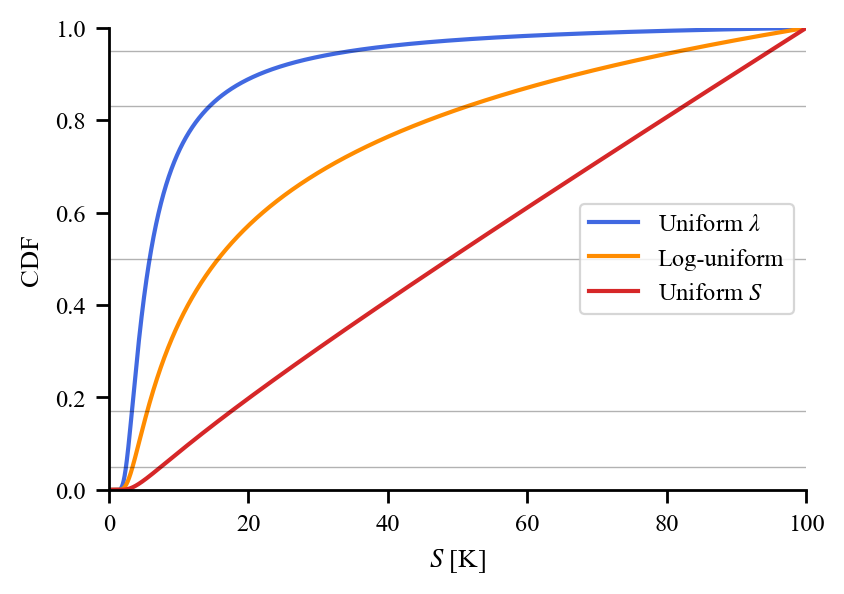

In [132]:
def pdf_to_cdf(x, pdf):
    x = np.asarray(x)
    pdf = np.asarray(pdf)

    isort = np.argsort(x)
    x = x[isort]
    pdf = pdf[isort]

    pdf = np.where(np.isfinite(pdf), pdf, 0)
    pdf = pdf / np.trapezoid(pdf, x)

    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))
    cdf = cdf / cdf[-1]

    return x, pdf, cdf


def summarize_pdf(name, x, pdf):
    x, pdf, cdf = pdf_to_cdf(x, pdf)

    q05, q17, q50, q83, q95 = np.interp(
        [0.05, 0.17, 0.50, 0.83, 0.95],
        cdf,
        x,
    )

    mean = np.trapezoid(x * pdf, x)
    mode = x[pdf.argmax()]

    print(f"{name}")
    print(f"  mode        = {mode:.2f} K")
    print(f"  mean        = {mean:.2f} K")
    print(f"  median      = {q50:.2f} K")
    print(f"  likely      = {q17:.2f}–{q83:.2f} K")
    print(f"  very likely = {q05:.2f}–{q95:.2f} K")
    print()

    return x, cdf


pdfs = {
    r"Uniform $\lambda$": (postS_uniform_lam, c_unilamb),
    r"Log-uniform": (postS_log_uniform, c_loglamb),
    r"Uniform $S$": (postS_uniform_S, c_unifs),
}

plt.figure(figsize=(4.5, 3), dpi=200)

for name, (pdf, color) in pdfs.items():
    x, cdf = summarize_pdf(name, S_plot, pdf)
    plt.plot(x, cdf, label=name, c=color, lw=1.5)

plt.axhline(0.05, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.17, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.50, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.83, c='k', lw=0.5, alpha=0.3)
plt.axhline(0.95, c='k', lw=0.5, alpha=0.3)

plt.xlim(0, 100)
plt.ylim(0, 1)
plt.xlabel(r"$S$ [K]")
plt.ylabel("CDF")
# plt.grid(alpha=0.2)
plt.legend()
sns.despine()
plt.show()

# Figures

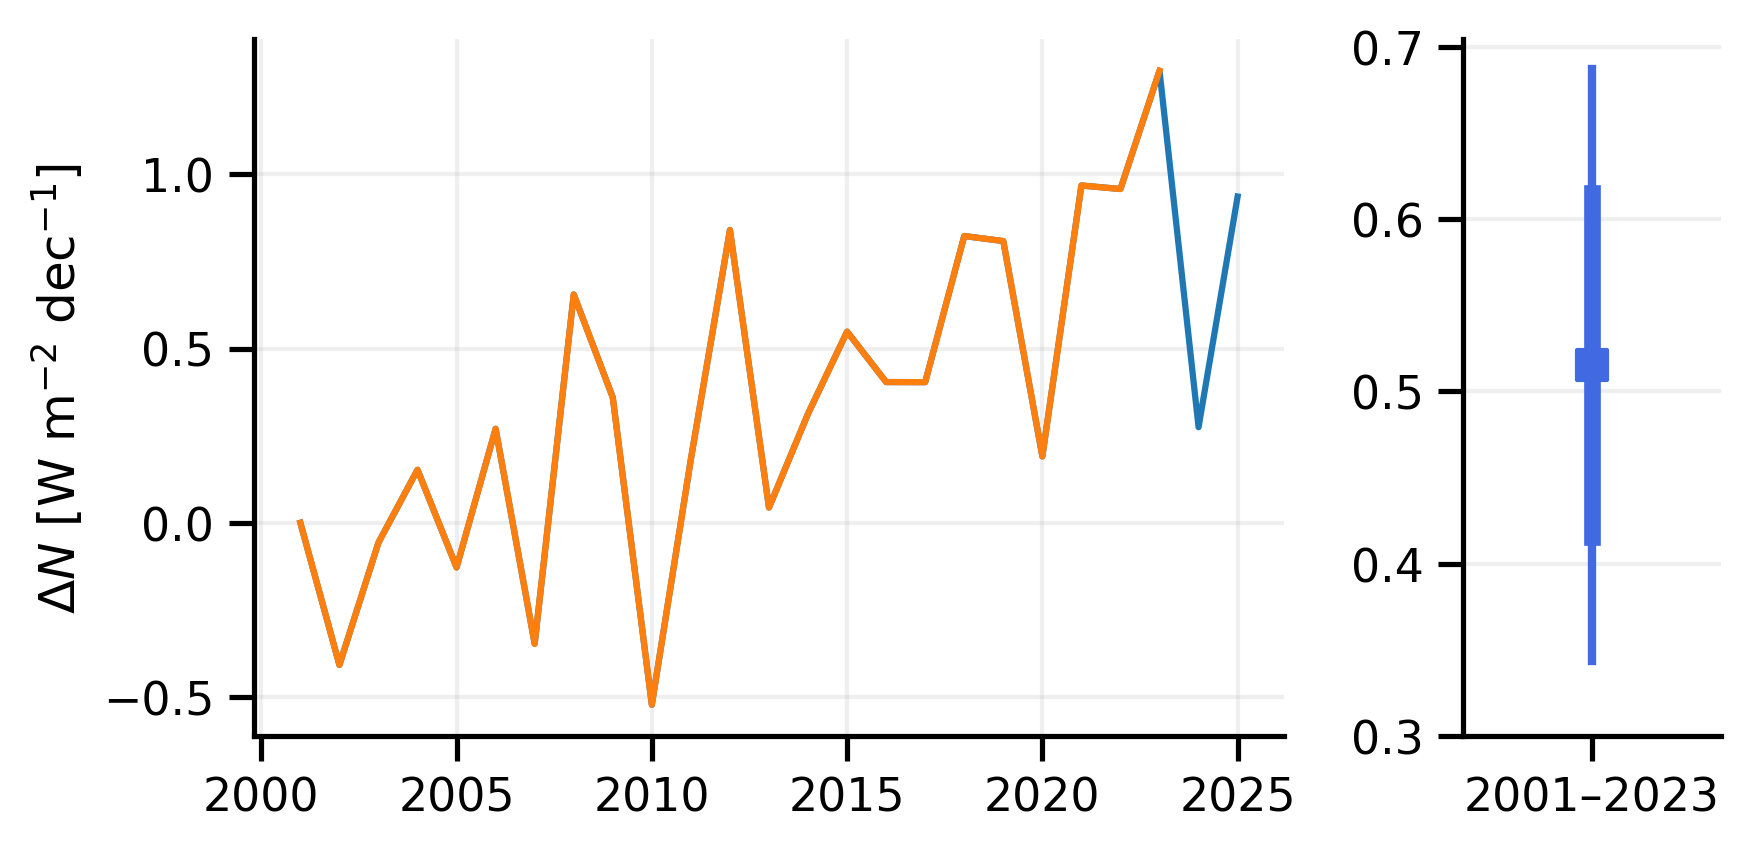

In [384]:
sns.set_context('notebook')
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=300)

plt.sca(axs[0])
plt.plot(ceres.year, ceres['gtoa_net_all_mon']-ceres['gtoa_net_all_mon'].sel(year=2001),ls='-')
plt.plot(N.year, N-N[0])
plt.grid(alpha=0.2)
# plt.ylabel(r"$dN/dt$ [W m$^{-2}$ dec$^{-1}$]")
plt.ylabel(r"$\Delta N$ [W m$^{-2}$ dec$^{-1}$]")

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Ndot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Ndot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Ndot_ens,[0.17,.83]),c=col,lw=4)


# res = linregress(N.year, N)
# plt.scatter(-0.5,10*res.slope)
# plt.plot(-0.5+np.array([0,0]),10*np.array([-1,1])*res.stderr+10*res.slope,c=col,lw=2)
plt.xticks(ticks=[0],labels=['2001–2023'])
plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')

sns.despine()
plt.tight_layout()

plt.show()

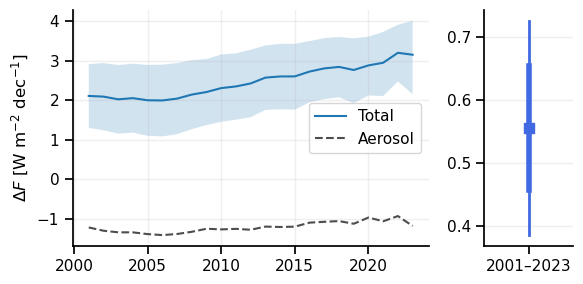

In [395]:
sns.set_context('notebook')
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=100)

plt.sca(axs[0])
# plt.plot(erf_total.time, erf_total.mean(dim='ensemble'),ls='-')
plt.plot(erf_total.time.sel(time=ceres_tsel), erf_total.sel(time=ceres_tsel).mean(dim='ensemble'),
         ls='-', label='Total')

q = erf_total.sel(time=ceres_tsel).quantile([0.05,0.95],dim='ensemble')
plt.fill_between(erf_total.time.sel(time=ceres_tsel), y1=q[0], y2=q[1],alpha=0.2,lw=0)

aer_erf = ds_erf.sel(time=ceres_tsel)['aerosol-radiation_interactions'].mean(dim='ensemble')
aer_erf = aer_erf + ds_erf.sel(time=ceres_tsel)['aerosol-cloud_interactions'].mean(dim='ensemble')

plt.plot(aer_erf.time, aer_erf, label='Aerosol',ls='--',c='0.3')
plt.grid(alpha=0.2)
plt.legend()
plt.ylabel(r"$\Delta F$ [W m$^{-2}$ dec$^{-1}$]")

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Fdot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Fdot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Fdot_ens,[0.17,.83]),c=col,lw=4)


plt.xticks(ticks=[0],labels=['2001–2023'])
# plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')

sns.despine()
plt.tight_layout()

plt.show()

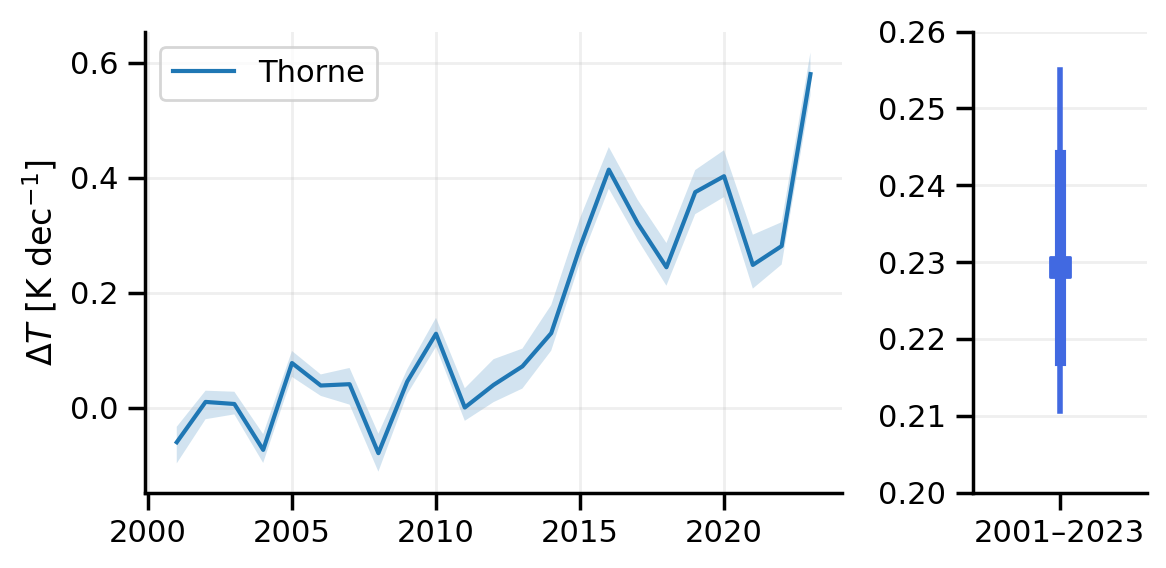

In [378]:
fig,axs = plt.subplots(1,2,figsize=(6,3),width_ratios=[4,1],dpi=200)
plt.sca(axs[0])

key='Thorne'
(gmst_dict[key].mean(dim='ensemble') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

q = (gmst_dict[key].sel(year=ceres_tsel) - 
     gmst_dict[key].sel(year=slice(2001,2006)).mean(dim='year')).quantile([0.05,0.95],dim='ensemble')
plt.fill_between(erf_total.time.sel(time=ceres_tsel), y1=q[0], y2=q[1],alpha=0.2,lw=0)

# key='C25'
# (gmst_dict[key].mean(dim='ens') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

# key='HadCRUT5.1'
# (gmst_dict[key].mean(dim='ens') - gmst_dict[key].sel(year=slice(2001,2006)).mean()).plot(label=key)

plt.ylabel(r"$\Delta T$ [K dec$^{-1}$]")
plt.legend()
plt.xlabel('')
plt.grid(alpha=0.2)

col = 'royalblue'
plt.sca(axs[1])
plt.scatter(0,Tdot_ens.mean(),c=col,s=50,zorder=3,marker='s')
plt.plot([0,0],np.quantile(Tdot_ens,[0.05,.95]),c=col,lw=2)
plt.plot([0,0],np.quantile(Tdot_ens,[0.17,.83]),c=col,lw=4)


plt.xticks(ticks=[0],labels=['2001–2023'])
# plt.yticks(np.arange(0.3,0.71,0.1))
plt.grid(alpha=0.2,axis='y')
plt.ylim(0.2,0.26)

sns.despine()
plt.tight_layout()


plt.show()

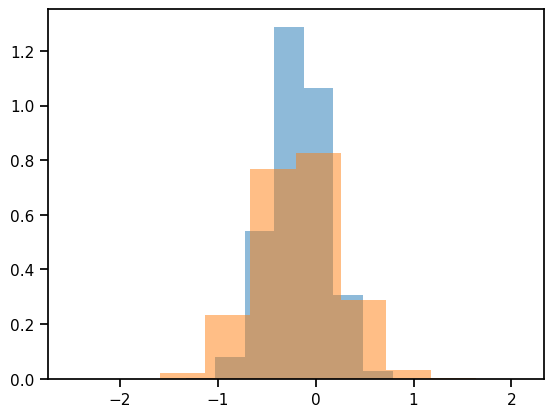

In [126]:
plt.hist(rng.normal((dNdt_mu - dFdt_mu)/dTdt_mu, 0.28, size=mc_n*10),density=True,alpha=0.5)
plt.hist(rng.normal((dNdt_mu - dFdt_mu)/dTdt_mu, 0.414, size=mc_n*10),density=True,alpha=0.5)
plt.show()

## Scratch

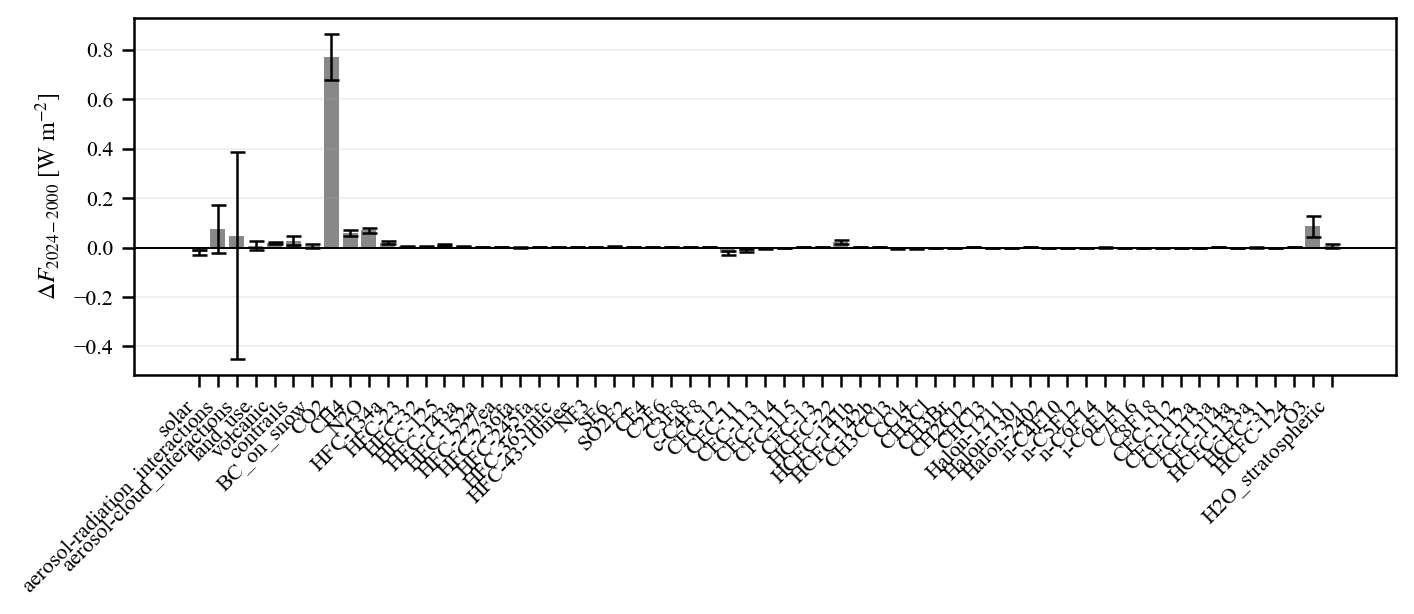

,mean,q05,q95
variable,,,
solar,-0.019,-0.030,-0.008
aerosol-radiation_interactions,0.075,-0.023,0.173
aerosol-cloud_interactions,0.045,-0.451,0.385
land_use,0.005,-0.011,0.026
volcanic,0.017,0.013,0.021
...,...,...,...
HCFC-133a,0.000,0.000,0.000
HCFC-31,0.000,0.000,0.000
HCFC-124,0.000,0.000,0.000


In [403]:
## ERF component changes from 2000 to 2024
plot_vars = list(ds_erf.data_vars)  ## edit this list to plot a subset later
# plot_vars = ["co2", "aerosol-cloud_interactions", "aerosol-radiation_interactions"]

y0 = 2000
y1 = 2024

rows = []
for var in plot_vars:
    da = ds_erf[var]

    tdim = "time" if "time" in da.dims else "year"
    edims = [d for d in da.dims if d != tdim]

    diff = da.sel({tdim: y1}) - da.sel({tdim: y0})
    vals = np.asarray(diff.values).ravel()
    vals = vals[np.isfinite(vals)]

    rows.append({
        "variable": var,
        "mean": np.mean(vals),
        "q05": np.quantile(vals, 0.05),
        "q95": np.quantile(vals, 0.95),
    })

erf_change_df = pd.DataFrame(rows).set_index("variable")

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=180)

x = np.arange(len(erf_change_df))
y = erf_change_df["mean"].values
yerr = np.vstack([
    y - erf_change_df["q05"].values,
    erf_change_df["q95"].values - y,
])

ax.bar(x, y, color="0.45", alpha=0.85)
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="k", capsize=3, lw=1)

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(erf_change_df.index, rotation=45, ha="right")
ax.set_ylabel(r"$\Delta F_{2024-2000}$ [W m$^{-2}$]")
ax.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

display(erf_change_df.round(3))

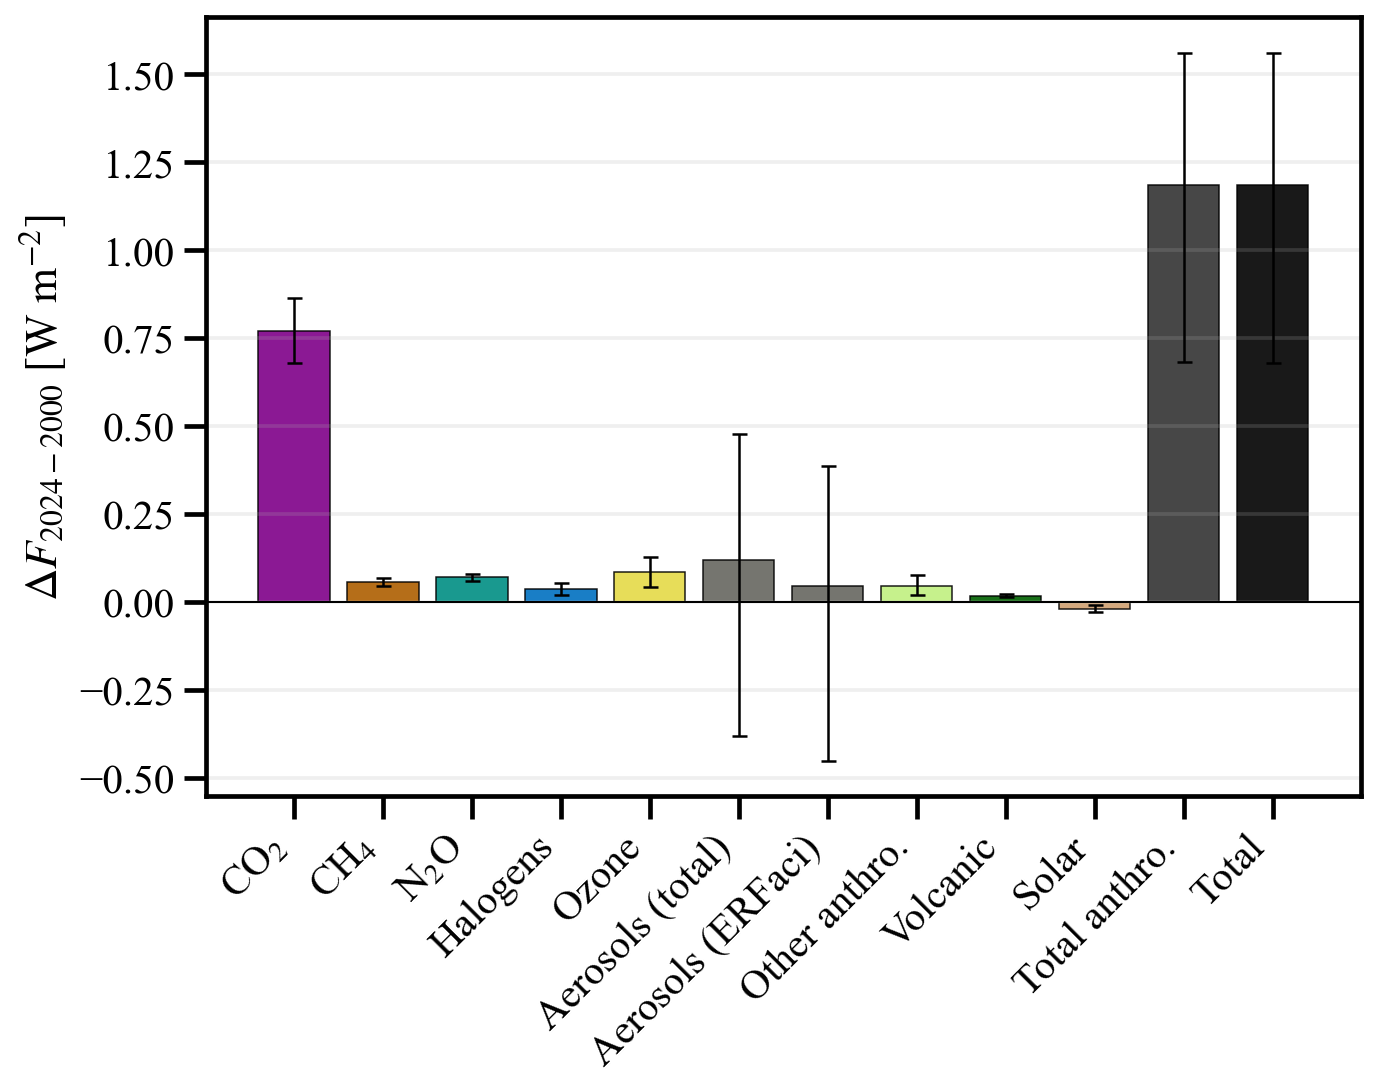

,mean,q05,q95
group,,,
CO2,0.771,0.678,0.863
CH4,0.058,0.046,0.069
N2O,0.070,0.060,0.080
halogen,0.037,0.020,0.053
O3,0.085,0.043,0.128
aerosol,0.120,-0.381,0.476
aerosol (ERFaci),0.045,-0.451,0.385
minor,0.046,0.019,0.076
volcanic,0.017,0.013,0.021


In [410]:
sns.set_context('talk')
## ERF group changes from 2000 to 2024, grouped like forcing-timeseries ERF_timeseries plot
y0, y1 = 2000, 2024
tdim = "time"

base_vars = set(ds_erf.data_vars)

halogen_vars = [
    v for v in ds_erf.data_vars
    if v not in [
        "solar", "volcanic",
        "aerosol-radiation_interactions", "aerosol-cloud_interactions",
        "CO2", "CH4", "N2O", "O3",
        "H2O_stratospheric", "contrails", "BC_on_snow", "land_use",
    ]
]

erf_groups = {
    "CO2": ["CO2"],
    "CH4": ["CH4"],
    "N2O": ["N2O"],
    "halogen": halogen_vars,
    "O3": ["O3"],
    "aerosol": ["aerosol-radiation_interactions", "aerosol-cloud_interactions"],
    "aerosol (ERFaci)": ["aerosol-cloud_interactions"],
    "minor": ["H2O_stratospheric", "contrails", "BC_on_snow", "land_use"],
    "volcanic": ["volcanic"],
    "solar": ["solar"],
    "anthro": [v for v in ds_erf.data_vars if v not in ["solar", "volcanic"]],
    "total": list(ds_erf.data_vars),
}

## edit this list to plot a subset
plot_groups = ["CO2", "CH4", "N2O", "halogen", "O3", "aerosol", "aerosol (ERFaci)", "minor", "volcanic", "solar", "anthro", "total"]

labels = {
    "CO2": "CO$_2$",
    "CH4": "CH$_4$",
    "N2O": "N$_2$O",
    "halogen": "Halogens",
    "O3": "Ozone",
    "aerosol": "Aerosols (total)",
    "aerosol (ERFaci)": "Aerosols (ERFaci)",
    "minor": "Other anthro.",
    "volcanic": "Volcanic",
    "solar": "Solar",
    "anthro": "Total anthro.",
    "total": "Total",
}

colors = {
    "CO2": "#7f0089",
    "CH4": "#ad5e00",
    "N2O": "#008e83",
    "halogen": "#0070c0",
    "O3": "#e5da47",
    "aerosol": "#66665f",
    "aerosol (ERFaci)": "#66665f",
    "minor": "#c0f080",
    "volcanic": "#006000",
    "solar": "#d0a070",
    "anthro": "0.2",
    "total": "k",
}

def _sum_group(varlist):
    varlist = [v for v in varlist if v in ds_erf]
    if len(varlist) == 0:
        raise ValueError("No variables found for group")
    out = ds_erf[varlist[0]]
    for v in varlist[1:]:
        out = out + ds_erf[v]
    return out

rows = []
for group in plot_groups:
    da = _sum_group(erf_groups[group])
    diff = da.sel({tdim: y1}) - da.sel({tdim: y0})

    vals = np.asarray(diff.values).ravel()
    vals = vals[np.isfinite(vals)]

    rows.append({
        "group": group,
        "mean": np.mean(vals),
        "q05": np.quantile(vals, 0.05),
        "q95": np.quantile(vals, 0.95),
    })

erf_change_grouped = pd.DataFrame(rows).set_index("group")

fig, ax = plt.subplots(figsize=(8, 6.4), dpi=180)

x = np.arange(len(erf_change_grouped))
y = erf_change_grouped["mean"].values
yerr = np.vstack([
    y - erf_change_grouped["q05"].values,
    erf_change_grouped["q95"].values - y,
])

ax.bar(
    x,
    y,
    color=[colors[g] for g in erf_change_grouped.index],
    alpha=0.9,
    edgecolor="k",
    lw=0.6,
)
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="k", capsize=3, lw=1)

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([labels[g] for g in erf_change_grouped.index], rotation=45, ha="right")
ax.set_ylabel(r"$\Delta F_{2024-2000}$ [W m$^{-2}$]")
ax.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

display(erf_change_grouped.round(3))

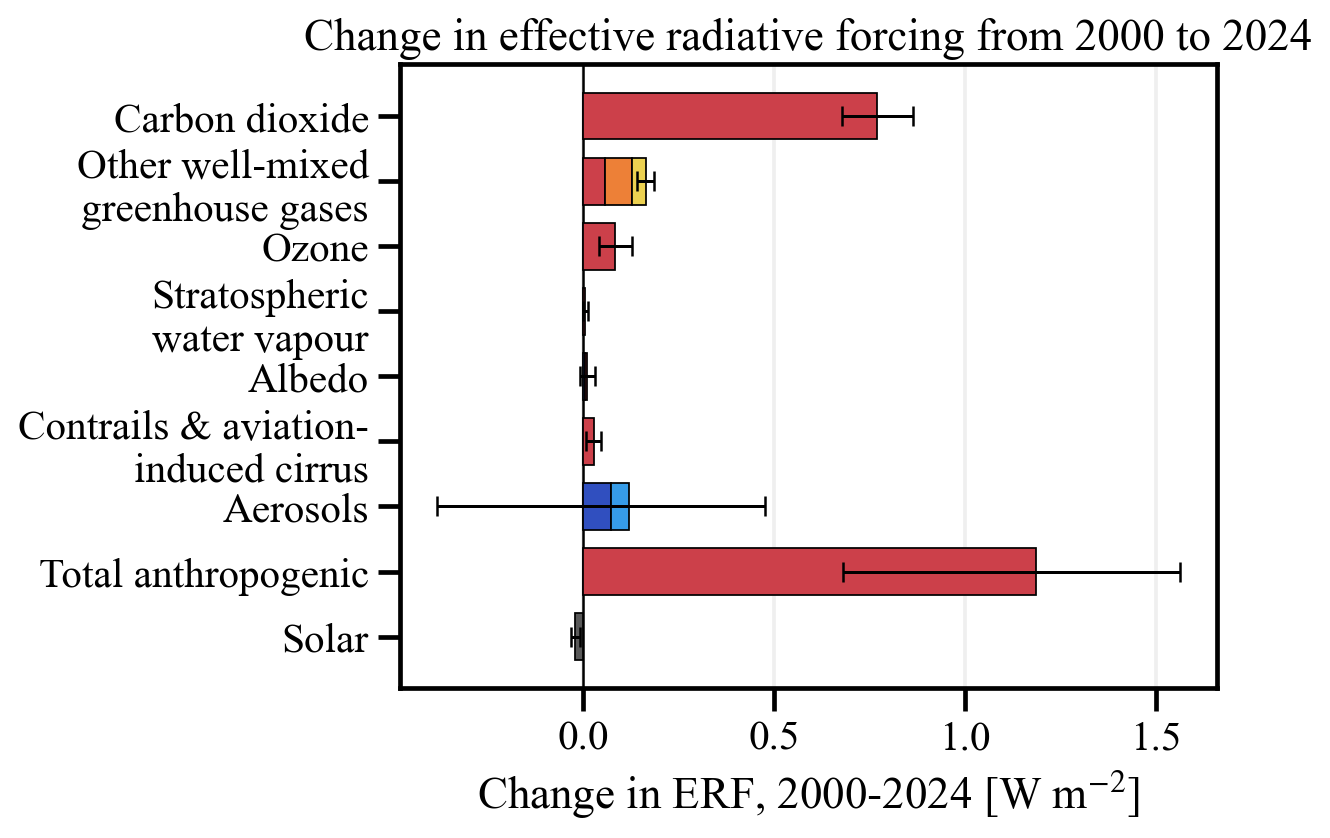

,mean,q05,q95
forcing,,,
Carbon dioxide,0.771,0.678,0.863
Other well-mixed greenhouse gases,0.164,0.142,0.187
Ozone,0.085,0.043,0.128
Stratospheric water vapour,0.007,-0.000,0.014
Albedo,0.011,-0.006,0.033
Contrails & aviation- induced cirrus,0.028,0.009,0.048
Aerosols,0.120,-0.381,0.476
Total anthropogenic,1.187,0.682,1.562
Solar,-0.019,-0.030,-0.008


In [411]:
## IPCC-style horizontal ERF change plot: 2024 minus 2000
y0, y1 = 2000, 2024
tdim = "time" if "time" in ds_erf.dims else "year"

halogen_vars = [
    v for v in ds_erf.data_vars
    if v not in [
        "solar", "volcanic",
        "aerosol-radiation_interactions", "aerosol-cloud_interactions",
        "CO2", "CH4", "N2O", "O3",
        "H2O_stratospheric", "contrails", "BC_on_snow", "land_use",
    ]
]

rows = [
    ("Carbon dioxide", [("CO2", "CO2")]),
    ("Other well-mixed\ngreenhouse gases", [("CH4", "CH4"), ("N2O", "N2O"), ("Halogens", halogen_vars)]),
    ("Ozone", [("O3", "O3")]),
    ("Stratospheric\nwater vapour", [("H2O stratospheric", "H2O_stratospheric")]),
    ("Albedo", [("Land use", "land_use"), ("BC on snow", "BC_on_snow")]),
    ("Contrails & aviation-\ninduced cirrus", [("Contrails", "contrails")]),
    ("Aerosols", [("Aerosol-radiation", "aerosol-radiation_interactions"), ("Aerosol-cloud", "aerosol-cloud_interactions")]),
    ("Total anthropogenic", [("Total anthropogenic", [v for v in ds_erf.data_vars if v not in ["solar", "volcanic"]])]),
    ("Solar", [("Solar", "solar")]),
]

## edit this to plot a subset of rows
plot_rows = [r[0] for r in rows]

colors = {
    "CO2": "#cc404a",
    "CH4": "#cc404a",
    "N2O": "#ed8037",
    "Halogens": "#ecd151",
    "O3": "#cc404a",
    "H2O stratospheric": "#cc404a",
    "BC on snow": "#cc404a",
    "Contrails": "#cc404a",
    "Land use": "#304fbf",
    "Aerosol-radiation": "#304fbf",
    "Aerosol-cloud": "#369ce8",
    "Total anthropogenic": "#cc404a",
    "Solar": "0.35",
}

def _as_list(v):
    return v if isinstance(v, list) else [v]

def _diff_vals(varlist):
    varlist = [v for v in _as_list(varlist) if v in ds_erf]
    da = sum(ds_erf[v] for v in varlist)
    diff = da.sel({tdim: y1}) - da.sel({tdim: y0})
    vals = np.asarray(diff.values).ravel()
    return vals[np.isfinite(vals)]

fig, ax = plt.subplots(figsize=(7.2, 5.0), dpi=180)

yticks, ylabels = [], []
summary = []

ypos = 0
for row_label, parts in rows:
    if row_label not in plot_rows:
        continue

    total_vals = _diff_vals(sum([_as_list(v) for _, v in parts], []))
    total_mean = np.mean(total_vals)
    q05, q95 = np.quantile(total_vals, [0.05, 0.95])

    left_pos, left_neg = 0.0, 0.0
    for part_label, varlist in parts:
        vals = _diff_vals(varlist)
        mean = np.mean(vals)
        left = left_pos if mean >= 0 else left_neg

        ax.barh(
            ypos,
            mean,
            left=left,
            height=0.72,
            color=colors.get(part_label, "0.6"),
            edgecolor="k",
            lw=0.7,
            zorder=3,
        )

        if mean >= 0:
            left_pos += mean
        else:
            left_neg += mean

    ax.errorbar(
        total_mean,
        ypos,
        xerr=np.array([[total_mean - q05], [q95 - total_mean]]),
        fmt="none",
        ecolor="k",
        capsize=4,
        lw=1.2,
        zorder=5,
    )

    summary.append({
        "forcing": row_label.replace("\n", " "),
        "mean": total_mean,
        "q05": q05,
        "q95": q95,
    })

    yticks.append(ypos)
    ylabels.append(row_label)
    ypos += 1

ax.axvline(0, color="k", lw=1.0)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.invert_yaxis()
ax.set_xlabel(rf"Change in ERF, {y0}-{y1} [W m$^{{-2}}$]")
ax.set_title(rf"Change in effective radiative forcing from {y0} to {y1}")
ax.grid(alpha=0.2, axis="x", zorder=0)

plt.tight_layout()
plt.show()

erf_ipcc_style_df = pd.DataFrame(summary).set_index("forcing")
display(erf_ipcc_style_df.round(3))

In [100]:
path = '/glade/campaign/collections/cdg/data/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/tas/gn/latest/'
fname = 'tas_Amon_CESM2_piControl_r1i1p1f1_gn_000101-009912.nc'
xr.open_dataset(path + fname)['tas'].groupby('time.year').mean()

/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.DataArray 'tas' (time: 1188, lat: 192, lon: 288)> Size: 263MB
[65691648 values with dtype=float32]
Coordinates:
  * time     (time) object 10kB 0001-01-15 12:00:00 ... 0099-12-15 12:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      mon
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

In [ ]:
from pathlib import Path

path = Path(
    "/glade/campaign/collections/cdg/data/CMIP6/CMIP/NCAR/CESM2/"
    "piControl/r1i1p1f1/Amon/tas/gn/latest/"
)

files = sorted(path.glob("tas_Amon_CESM2_piControl_r1i1p1f1_gn_*.nc"))
print("n files:", len(files))
print(files[0].name, "to", files[-1].name)

tas_ann = (
    xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks={"time": 120},
        use_cftime=True,
    )["tas"]
    .groupby("time.year")
    .mean("time")
)

tas_ann

In [101]:
from pathlib import Path

path = Path(
    "/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP/MOHC/UKESM1-0-LL/"
    "piControl/r1i1p1f2/Amon/tas/gn/v20190410/tas/"
)

files = sorted(path.glob("tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_*.nc"))
print("n files:", len(files))
print(files[0].name, "to", files[-1].name)

tas_ann = (
    xr.open_mfdataset(
        files,
        combine="by_coords",
        chunks={"time": 120},
        use_cftime=True,
    )["tas"]
    .groupby("time.year")
    .mean("time")
)

tas_ann

n files: 8
tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_196001-204912.nc to tas_Amon_UKESM1-0-LL_piControl_r1i1p1f2_gn_265001-270912.nc


/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  xr.open_mfdataset(
/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  xr.open_mfdataset(
/glade/derecho/scratch/vcooper/tmp/ipykernel_40010/1528056895.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the '

<xarray.DataArray 'tas' (year: 750, lat: 144, lon: 192)> Size: 83MB
dask.array<stack, shape=(750, 144, 192), dtype=float32, chunksize=(1, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 6kB 1960 1961 1962 1963 1964 ... 2706 2707 2708 2709
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    original_name:  mo: (stash: m01s03i236, lbproc: 128)
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-04-05T15:19:17Z altered by CMOR: Treated scalar dime...

# Clean configurable CERES trend analysis

The cells below keep the analysis period, pattern-effect parameters, uncertainty scaling, and internal-variability treatment in one place. They produce the compact likelihood/prior/posterior plot, energy-budget component time-series panels, and a simple sensitivity comparison.

In [414]:
## clean analysis configuration
analysis_period = slice(2006,2024)          ## e.g., slice(2001, 2023)
analysis_period_alt = slice(2001,2024)       ## e.g., slice(2006, 2023)
# analysis_temp_key = "Thorne" ## wait until published
analysis_temp_key = "HadCRUT5.1"
# analysis_temp_key = "C25"
analysis_mc_n = 500_000
posterior_score = "N"                  ## "N" or "T"
include_internal_variability = True

## default pattern-effect assumptions
analysis_dlamb_mu = 0.0 #dlamb_mu
analysis_dlamb_sig = 0.2 #dlamb_sig

## structural uncertainty in Fdot, per Park and Soden and Yuan et al. 2026
Fdot_struct_sig = 0.10  # W m-2 dec-1, example

## change these independently for the 2006-2023 sensitivity case
analysis_dlamb_mu_2001_2024 = analysis_dlamb_mu
analysis_dlamb_sig_2001_2024 = analysis_dlamb_sig

## forcing and prior settings
analysis_F2x_mu = 3.93
analysis_F2x_sig = 0.29
lam_prior_lo = -30.0
lam_prior_hi = -0.02

## piControl internal low-frequency variability, order [dTdt, dNdt]
## 2001-2024
iv_cov_cesm2_2001_2023 = np.array([
    [0.048707**2, -0.001062],
    [-0.001062,  0.104263**2],
])

iv_cov_mpi_2001_2023 = np.array([
    [0.063137**2, -0.003081],
    [-0.003081,  0.080356**2],
])

## 2006-2024 (63 blocks CESM2, 52 for MPI)
iv_cov_cesm2_2006_2024 = np.array([
    [0.074407**2, -0.002356],
    [-0.002356,  0.131178**2],
])

iv_cov_mpi_2006_2024 = np.array([
    [0.065739**2, -0.003584],
    [-0.003584,  0.118013**2],
])


analysis_iv_cov = 0.5 * (iv_cov_cesm2_2006_2024 + iv_cov_mpi_2006_2024)
analysis_iv_cov_alt = 0.5 * (iv_cov_cesm2_2001_2023 + iv_cov_mpi_2001_2023) # 2023 vs 2024 insignificant

In [415]:
## clean helper functions
analysis_rng = np.random.default_rng(20260720)


def _period_label(period):
    return f"{period.start}-{period.stop}"


def _area_norm(pdf, x):
    pdf = np.asarray(pdf, dtype=float)
    x = np.asarray(x, dtype=float)
    pdf = np.where(np.isfinite(pdf), pdf, 0.0)
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf


def _pdf_summary(x, pdf):
    x = np.asarray(x, dtype=float)
    pdf = _area_norm(pdf, x)
    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))
    cdf = cdf / cdf[-1]
    return {
        "mode": x[np.nanargmax(pdf)],
        "p05": np.interp(0.05, cdf, x),
        "p17": np.interp(0.17, cdf, x),
        "p50": np.interp(0.50, cdf, x),
        "p83": np.interp(0.83, cdf, x),
        "p95": np.interp(0.95, cdf, x),
    }


def _ens_dims(da, time_dim):
    return [dim for dim in da.dims if dim != time_dim]


def _trend_params(period, temp_key="Thorne"):
    Ftrend = 10 * erf_total.sel(time=period).polyfit(dim="time", deg=1).polyfit_coefficients.sel(degree=1)
    F_vals = np.asarray(Ftrend.values, dtype=float).ravel()
    F_vals = F_vals[np.isfinite(F_vals)]

    N_period = ceres["gtoa_net_all_mon"].sel(year=period)
    N_fit = linregress(N_period.year, N_period)

    Ttrend = 10 * gmst_dict[temp_key].sel(year=period).polyfit(dim="year", deg=1).polyfit_coefficients.sel(degree=1)
    T_vals = np.asarray(Ttrend.values, dtype=float).ravel()
    T_vals = T_vals[np.isfinite(T_vals)]

    return {
        "F_mu": float(np.mean(F_vals)),
        "F_sig": float(np.std(F_vals, ddof=1)),
        "F_vals": F_vals,
        "N_mu": float(10 * N_fit.slope),
        "N_sig": float(10 * N_fit.stderr),
        "T_mu": float(np.mean(T_vals)),
        "T_sig": float(np.std(T_vals, ddof=1)),
        "T_vals": T_vals,
    }


def _draw_case_samples(
    params,
    dlamb_mu,
    dlamb_sig,
    uncertainty_scale=1.0,
    mc_n=analysis_mc_n,
    iv_cov=None,
    temp_key=None,
):
    if iv_cov is None:
        iv_cov = analysis_iv_cov
    if temp_key is None:
        temp_key = analysis_temp_key

    F2x = analysis_rng.normal(
        analysis_F2x_mu,
        analysis_F2x_sig * uncertainty_scale,
        mc_n,
    )

    Fdot_sig_total = np.sqrt(params["F_sig"]**2 + Fdot_struct_sig**2) * uncertainty_scale
    Fdot = analysis_rng.normal(params["F_mu"], Fdot_sig_total, mc_n)

    ## Thorne temperature draws are non-Gaussian, so resample their empirical ensemble.
    ## Other temperature products are treated as approximately normal.
    if "thorne" in str(temp_key).lower():
        Tdot = params["T_mu"] + uncertainty_scale * (
            analysis_rng.choice(params["T_vals"], mc_n, replace=True) - params["T_mu"]
        )
    else:
        Tdot = analysis_rng.normal(
            params["T_mu"],
            params["T_sig"] * uncertainty_scale,
            mc_n,
        )

    Ndot = analysis_rng.normal(
        params["N_mu"],
        params["N_sig"] * uncertainty_scale,
        mc_n,
    )

    dlamb = analysis_rng.normal(
        dlamb_mu,
        dlamb_sig * uncertainty_scale,
        mc_n,
    )

    if include_internal_variability:
        iv_err = analysis_rng.multivariate_normal(
            mean=[0.0, 0.0],
            cov=iv_cov * uncertainty_scale**2,
            size=mc_n,
        )
        Tdot = Tdot + iv_err[:, 0]
        Ndot = Ndot + iv_err[:, 1]

    T_score_sig = params["T_sig"] * uncertainty_scale
    N_score_sig = params["N_sig"] * uncertainty_scale
    TN_score_cov = 0.0

    if include_internal_variability:
        T_score_sig = np.sqrt(T_score_sig**2 + iv_cov[0, 0] * uncertainty_scale**2)
        N_score_sig = np.sqrt(N_score_sig**2 + iv_cov[1, 1] * uncertainty_scale**2)
        TN_score_cov = iv_cov[0, 1] * uncertainty_scale**2

    return {
        "F2x": F2x,
        "Fdot": Fdot,
        "Tdot": Tdot,
        "Ndot": Ndot,
        "dlamb": dlamb,
        "T_score_sig": T_score_sig,
        "N_score_sig": N_score_sig,
        "TN_score_cov": TN_score_cov,
    }


def _conditional_N_score_terms(params, draws):
    """Return the covariance-conditioned N-location adjustment and residual sigma."""
    var_T = float(draws["T_score_sig"]**2)
    var_N = float(draws["N_score_sig"]**2)
    cov_TN = float(draws.get("TN_score_cov", 0.0))

    if var_T <= 0:
        raise ValueError("T-score variance must be positive.")
    conditional_N_var = var_N - cov_TN**2 / var_T
    if conditional_N_var <= 0:
        raise ValueError("The Tdot-Ndot score covariance is not positive definite.")

    T_departure = draws["Tdot"] - params["T_mu"]
    N_location_adjustment = -(cov_TN / var_T) * T_departure
    return N_location_adjustment, np.sqrt(conditional_N_var)


def _calc_likelihood_case(
    period,
    label=None,
    temp_key=analysis_temp_key,
    dlamb_mu=analysis_dlamb_mu,
    dlamb_sig=analysis_dlamb_sig,
    uncertainty_scale=1.0,
    lam_grid=None,
    S_grid=None,
    iv_cov=None,
):
    if label is None:
        label = _period_label(period)
    if lam_grid is None:
        lam_grid = np.linspace(-4.0, 2.0, 500)
    if S_grid is None:
        S_grid = np.linspace(0.05, 20.0, 600)

    params = _trend_params(period, temp_key=temp_key)
    draws = _draw_case_samples(
        params,
        dlamb_mu,
        dlamb_sig,
        uncertainty_scale=uncertainty_scale,
        iv_cov=iv_cov,
        temp_key=temp_key,
    )

    N_location_adjustment, N_conditional_sig = _conditional_N_score_terms(params, draws)

    like_lam_N = np.zeros_like(lam_grid)
    like_lam_T = np.zeros_like(lam_grid)
    for i, lam in enumerate(lam_grid):
        lam_eff = lam - draws["dlamb"]
        Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
        Tpred = np.where(np.abs(lam_eff) > 1e-8, (draws["Ndot"] - draws["Fdot"]) / lam_eff, np.nan)
        like_lam_N[i] = np.nanmean(
            norm.pdf(params["N_mu"], loc=Npred + N_location_adjustment, scale=N_conditional_sig)
        )
        like_lam_T[i] = np.nanmean(norm.pdf(params["T_mu"], loc=Tpred, scale=draws["T_score_sig"]))

    like_S_N = np.zeros_like(S_grid)
    like_S_T = np.zeros_like(S_grid)
    for i, S in enumerate(S_grid):
        lam = -draws["F2x"] / S
        lam_eff = lam - draws["dlamb"]
        Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
        Tpred = np.where(np.abs(lam_eff) > 1e-8, (draws["Ndot"] - draws["Fdot"]) / lam_eff, np.nan)
        like_S_N[i] = np.nanmean(
            norm.pdf(params["N_mu"], loc=Npred + N_location_adjustment, scale=N_conditional_sig)
        )
        like_S_T[i] = np.nanmean(norm.pdf(params["T_mu"], loc=Tpred, scale=draws["T_score_sig"]))

    S_prior_lo = -analysis_F2x_mu / lam_prior_lo
    S_prior_hi = -analysis_F2x_mu / lam_prior_hi
    S_prior_mask = (S_grid >= S_prior_lo) & (S_grid <= S_prior_hi)

    prior_S_unif_lam = np.where(S_prior_mask, analysis_F2x_mu / S_grid**2, 0.0)
    prior_S_log = np.where(S_prior_mask, 1 / S_grid, 0.0)
    prior_S_unif_S = np.where(S_prior_mask, 1.0, 0.0)

    postS_N_unif_lam = _area_norm(like_S_N * prior_S_unif_lam, S_grid)
    postS_N_log = _area_norm(like_S_N * prior_S_log, S_grid)
    postS_N_unif_S = _area_norm(like_S_N * prior_S_unif_S, S_grid)

    postS_T_unif_lam = _area_norm(like_S_T * prior_S_unif_lam, S_grid)
    postS_T_log = _area_norm(like_S_T * prior_S_log, S_grid)
    postS_T_unif_S = _area_norm(like_S_T * prior_S_unif_S, S_grid)

    return {
        "label": label,
        "period": period,
        "params": params,
        "draws": draws,
        "lam_grid": lam_grid,
        "S_grid": S_grid,
        "like_lam_N": like_lam_N,
        "like_lam_T": like_lam_T,
        "like_S_N": like_S_N,
        "like_S_T": like_S_T,
        "postS_N_unif_lam": postS_N_unif_lam,
        "postS_N_log": postS_N_log,
        "postS_N_unif_S": postS_N_unif_S,
        "postS_T_unif_lam": postS_T_unif_lam,
        "postS_T_log": postS_T_log,
        "postS_T_unif_S": postS_T_unif_S,
        "uncertainty_scale": uncertainty_scale,
        "dlamb_mu": dlamb_mu,
        "dlamb_sig": dlamb_sig,
        "iv_cov": iv_cov if iv_cov is not None else analysis_iv_cov,
    }

def _post_S_scoreN_from_draws(S_grid, res, prior_kind):
    d = res["draws"]
    p = res["params"]

    N_location_adjustment, N_conditional_sig = _conditional_N_score_terms(p, d)

    post = np.zeros_like(S_grid, dtype=float)

    for i, S0 in enumerate(S_grid):
        if (not np.isfinite(S0)) or (S0 <= 0):
            post[i] = 0.0
            continue

        lam_draw = -d["F2x"] / S0
        ok_lam = (
            (lam_draw >= posterior_lam_bounds[0])
            & (lam_draw <= posterior_lam_bounds[1])
            & (lam_draw < 0)
        )

        lam_eff = lam_draw - d["dlamb"]
        Npred = d["Fdot"] + lam_eff * d["Tdot"]
        pN = norm.pdf(
            p["N_mu"], loc=Npred + N_location_adjustment, scale=N_conditional_sig
        )

        if prior_kind == "uniform_lambda":
            weight = np.where(ok_lam, np.abs(d["F2x"]) / S0**2, 0.0)

        elif prior_kind == "log_lambda":
            weight = np.where(ok_lam, 1.0 / S0, 0.0)

        elif prior_kind == "uniform_S":
            ok_S = (S0 >= posterior_S_bounds[0]) & (S0 <= posterior_S_bounds[1])
            weight = np.ones_like(pN) if ok_S else np.zeros_like(pN)

        else:
            raise ValueError("prior_kind must be 'uniform_lambda', 'log_lambda', or 'uniform_S'")

        post[i] = np.nanmean(pN * weight)

    post = _area_norm(post, S_grid)
    ok = np.isfinite(post) & (post > 0)
    return post, ok

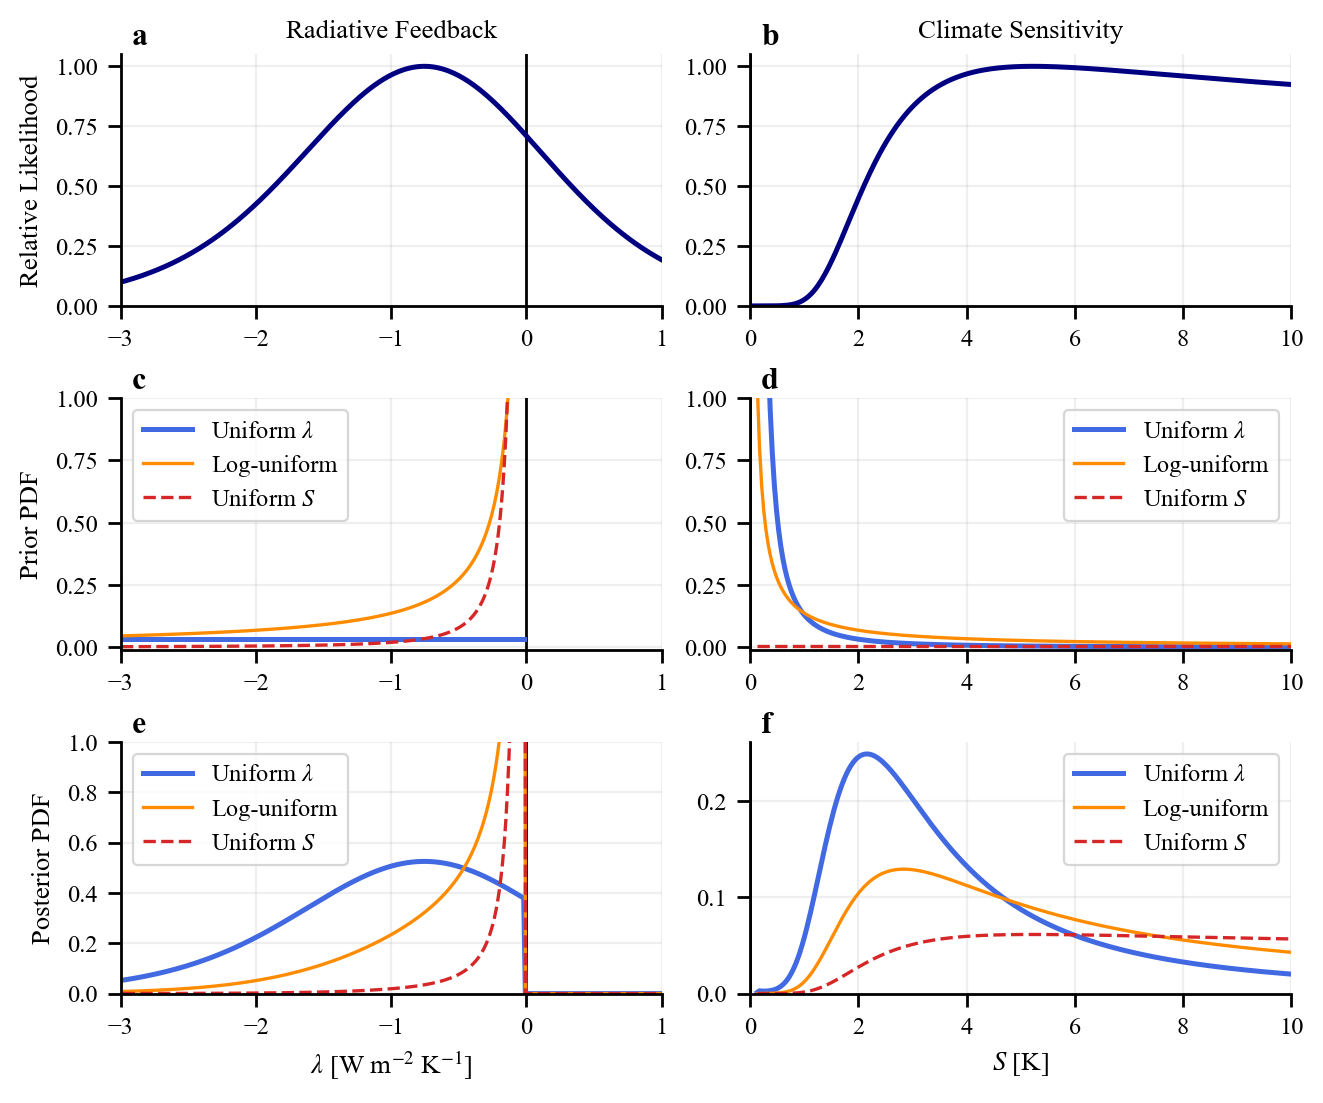

,posterior,mode,p05,p17,p50,p83,p95
0,Uniform lambda,2.174,1.361,1.946,3.452,7.378,13.039
1,Log-uniform,2.841,1.902,2.902,6.117,13.022,17.571
2,Uniform S,5.238,2.928,4.992,10.574,16.688,19.009


In [416]:
sns.set_context('paper')

dpis = 200
save = False

if save == True:
    dpis = 700

## Main compact likelihood, prior, and posterior plot
main_case = _calc_likelihood_case(
    analysis_period,
    label=_period_label(analysis_period),
    dlamb_mu=analysis_dlamb_mu,
    dlamb_sig=analysis_dlamb_sig,
)

lam_grid = main_case["lam_grid"]
S_grid = main_case["S_grid"]
like_N_rel = main_case["like_lam_N"] / np.nanmax(main_case["like_lam_N"])
like_T_rel = main_case["like_lam_T"] / np.nanmax(main_case["like_lam_T"])
S_like_N_rel = main_case["like_S_N"] / np.nanmax(main_case["like_S_N"])
S_like_T_rel = main_case["like_S_T"] / np.nanmax(main_case["like_S_T"])

# lam_plot = np.linspace(-10, -0.001, 4000)
lam_plot = np.linspace(lam_prior_lo, lam_prior_hi, 5000)
S_plot = np.linspace(-analysis_F2x_mu/lam_prior_lo, -analysis_F2x_mu/lam_prior_hi, 5000)

## priors for display
pL_uniform = np.where((lam_plot >= lam_prior_lo) & (lam_plot <= lam_prior_hi), 1.0, 0.0)
pL_log = np.where((lam_plot >= lam_prior_lo) & (lam_plot <= lam_prior_hi), 1 / np.abs(lam_plot), 0.0)
pL_uniform_S = np.where((lam_plot >= lam_prior_lo) & (lam_plot <= lam_prior_hi), analysis_F2x_mu / lam_plot**2, 0.0)
pL_uniform = _area_norm(pL_uniform, lam_plot)
pL_log = _area_norm(pL_log, lam_plot)
pL_uniform_S = _area_norm(pL_uniform_S, lam_plot)

S_prior_lo = -analysis_F2x_mu / lam_prior_lo
S_prior_hi = -analysis_F2x_mu / lam_prior_hi
S_prior_mask = (S_plot >= S_prior_lo) & (S_plot <= S_prior_hi)
pS_uniform_lam = _area_norm(np.where(S_prior_mask, analysis_F2x_mu / S_plot**2, 0.0), S_plot)
pS_log = _area_norm(np.where(S_prior_mask, 1 / S_plot, 0.0), S_plot)
pS_uniform_S = _area_norm(np.where(S_prior_mask, 1.0, 0.0), S_plot)

## posteriors from selected score
if posterior_score.upper() == "N":
    postS_uniform_lam = main_case["postS_N_unif_lam"]
    postS_log = main_case["postS_N_log"]
    postS_uniform_S = main_case["postS_N_unif_S"]
else:
    postS_uniform_lam = main_case["postS_T_unif_lam"]
    postS_log = main_case["postS_T_log"]
    postS_uniform_S = main_case["postS_T_unif_S"]

postS_uniform_lam_i = np.interp(S_plot, S_grid, postS_uniform_lam, left=0, right=0)
postS_log_i = np.interp(S_plot, S_grid, postS_log, left=0, right=0)
postS_uniform_S_i = np.interp(S_plot, S_grid, postS_uniform_S, left=0, right=0)

## posterior PDFs in lambda space for the bottom-left panel
if posterior_score.upper() == "N":
    like_lam_for_post = main_case["like_lam_N"]
else:
    like_lam_for_post = main_case["like_lam_T"]

lam_prior_mask = (lam_grid >= lam_prior_lo) & (lam_grid <= lam_prior_hi) & (lam_grid < 0)
prior_lam_uniform = np.where(lam_prior_mask, 1.0, 0.0)
prior_lam_log = np.where(lam_prior_mask, 1 / np.abs(lam_grid), 0.0)
prior_lam_uniform_S = np.where(lam_prior_mask, analysis_F2x_mu / lam_grid**2, 0.0)

postL_uniform_lam = _area_norm(like_lam_for_post * prior_lam_uniform, lam_grid)
postL_log = _area_norm(like_lam_for_post * prior_lam_log, lam_grid)
postL_uniform_S = _area_norm(like_lam_for_post * prior_lam_uniform_S, lam_grid)

c_unilamb = "royalblue"
c_log = "darkorange"
c_unifS = "tab:red"
comc = "navy"

lw_main = 1.8   ## likelihoods + uniform lambda
lw_alt = 1.2    ## log-uniform + uniform S
lw_ref = 1.0    ## zero lines

fig, axs = plt.subplots(
    3, 2,
    figsize=(6.5, 5.4),
    sharex="col",
    constrained_layout=True,
    dpi=dpis,
)

axs[0, 0].axvline(0, c="k", lw=lw_ref)
axs[0, 0].plot(lam_grid, like_N_rel, c=comc, lw=lw_main)
axs[0, 0].set_ylabel("Relative Likelihood")
axs[0, 0].set_xlim(-3, 1)
axs[0, 0].set_ylim(0, 1.05)
axs[0, 0].grid(alpha=0.2)

axs[0, 1].axvline(0, c="k", lw=lw_ref)
axs[0, 1].plot(S_grid, S_like_N_rel, c=comc, lw=lw_main)
axs[0, 1].set_xlim(-5, 10)
axs[0, 1].set_ylim(0, 1.05)
axs[0, 1].grid(alpha=0.2)

axs[1, 0].axvline(0, c="k", lw=lw_ref)
axs[1, 0].plot(lam_plot, pL_uniform, label=r"Uniform $\lambda$", c=c_unilamb, lw=lw_main)
axs[1, 0].plot(lam_plot, pL_log, label="Log-uniform", c=c_log, lw=lw_alt)
axs[1, 0].plot(lam_plot, pL_uniform_S, label=r"Uniform $S$", c=c_unifS, ls="--", lw=lw_alt)
axs[1, 0].set_ylabel("Prior PDF")
axs[1, 0].set_xlim(-3, 1)
axs[1, 0].set_ylim(-0.01, 1.0)
axs[1, 0].grid(alpha=0.2)
axs[1, 0].legend(frameon=True)

axs[1, 1].axvline(0, c="k", lw=lw_ref)
axs[1, 1].plot(S_plot, pS_uniform_lam, label=r"Uniform $\lambda$", c=c_unilamb, lw=lw_main)
axs[1, 1].plot(S_plot, pS_log, label="Log-uniform", c=c_log, lw=lw_alt)
axs[1, 1].plot(S_plot, pS_uniform_S, label=r"Uniform $S$", c=c_unifS, ls="--", lw=lw_alt)
axs[1, 1].set_xlim(-5, 10)
axs[1, 1].set_ylim(-0.01, 1.0)
axs[1, 1].grid(alpha=0.2)
axs[1, 1].legend(frameon=True)

axs[2, 0].axvline(0, c="k", lw=lw_ref)
axs[2, 0].plot(lam_grid, postL_uniform_lam, label=r"Uniform $\lambda$", c=c_unilamb, lw=lw_main)
axs[2, 0].plot(lam_grid, postL_log, label="Log-uniform", c=c_log, lw=lw_alt)
axs[2, 0].plot(lam_grid, postL_uniform_S, label=r"Uniform $S$", c=c_unifS, ls="--", lw=lw_alt)
axs[2, 0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[2, 0].set_ylabel("Posterior PDF")
axs[2, 0].set_xlim(-3, 1)
axs[2, 0].set_ylim(0, 1)
axs[2, 0].grid(alpha=0.2)
axs[2, 0].legend(frameon=True)

axs[2, 1].axvline(0, c="k", lw=lw_ref)
axs[2, 1].plot(S_plot, postS_uniform_lam_i, label=r"Uniform $\lambda$", c=c_unilamb, lw=lw_main)
axs[2, 1].plot(S_plot, postS_log_i, label="Log-uniform", c=c_log, lw=lw_alt)
axs[2, 1].plot(S_plot, postS_uniform_S_i, label=r"Uniform $S$", c=c_unifS, ls="--", lw=lw_alt)
axs[2, 1].set_xlabel(r"$S$ [K]")
axs[2, 1].set_xlim(-5, 10)
axs[2, 1].set_ylim(bottom=0)
axs[2, 1].set_ylabel("Posterior PDF")
axs[2, 1].grid(alpha=0.2)
axs[2, 1].legend(frameon=True)

# axs[0, 0].set_title(r"$\lambda$ Space")
axs[0, 0].set_title(r"Radiative Feedback")
axs[0, 1].set_title(r"Climate Sensitivity")
axs[2, 1].set_xlabel(r"$S$ [K]")

for ax in axs[:,1]:
    ax.set_xlim(0,10)
    ax.set_ylabel('')
for ax in axs[:,0]:
    ax.set_xlim(-3,1.002)

sns.despine()
for ax in axs.ravel():
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), visible=True)

panel_labels = ["a", "b", "c", "d", "e", "f"]

for ax, lab in zip(axs.ravel(), panel_labels):
    ax.text(
        0.02, 1.01,
        lab,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontweight="bold",
        fontsize="large",
    )

if save == True:
    # Save as PDF
    figpath = './figures/' + 'grl/'
    fname = 'fig_main_v0.pdf'
    if save == True:
        plt.savefig(figpath + fname, 
                    format='pdf', 
                    bbox_inches='tight',
                    dpi=dpis)
        print('saved ' + figpath + fname)
plt.show()

summary_rows = []
for name, pdf in [
    ("Uniform lambda", postS_uniform_lam_i),
    ("Log-uniform", postS_log_i),
    ("Uniform S", postS_uniform_S_i),
]:
    row = {"posterior": name}
    row.update(_pdf_summary(S_plot, pdf))
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).round(3))


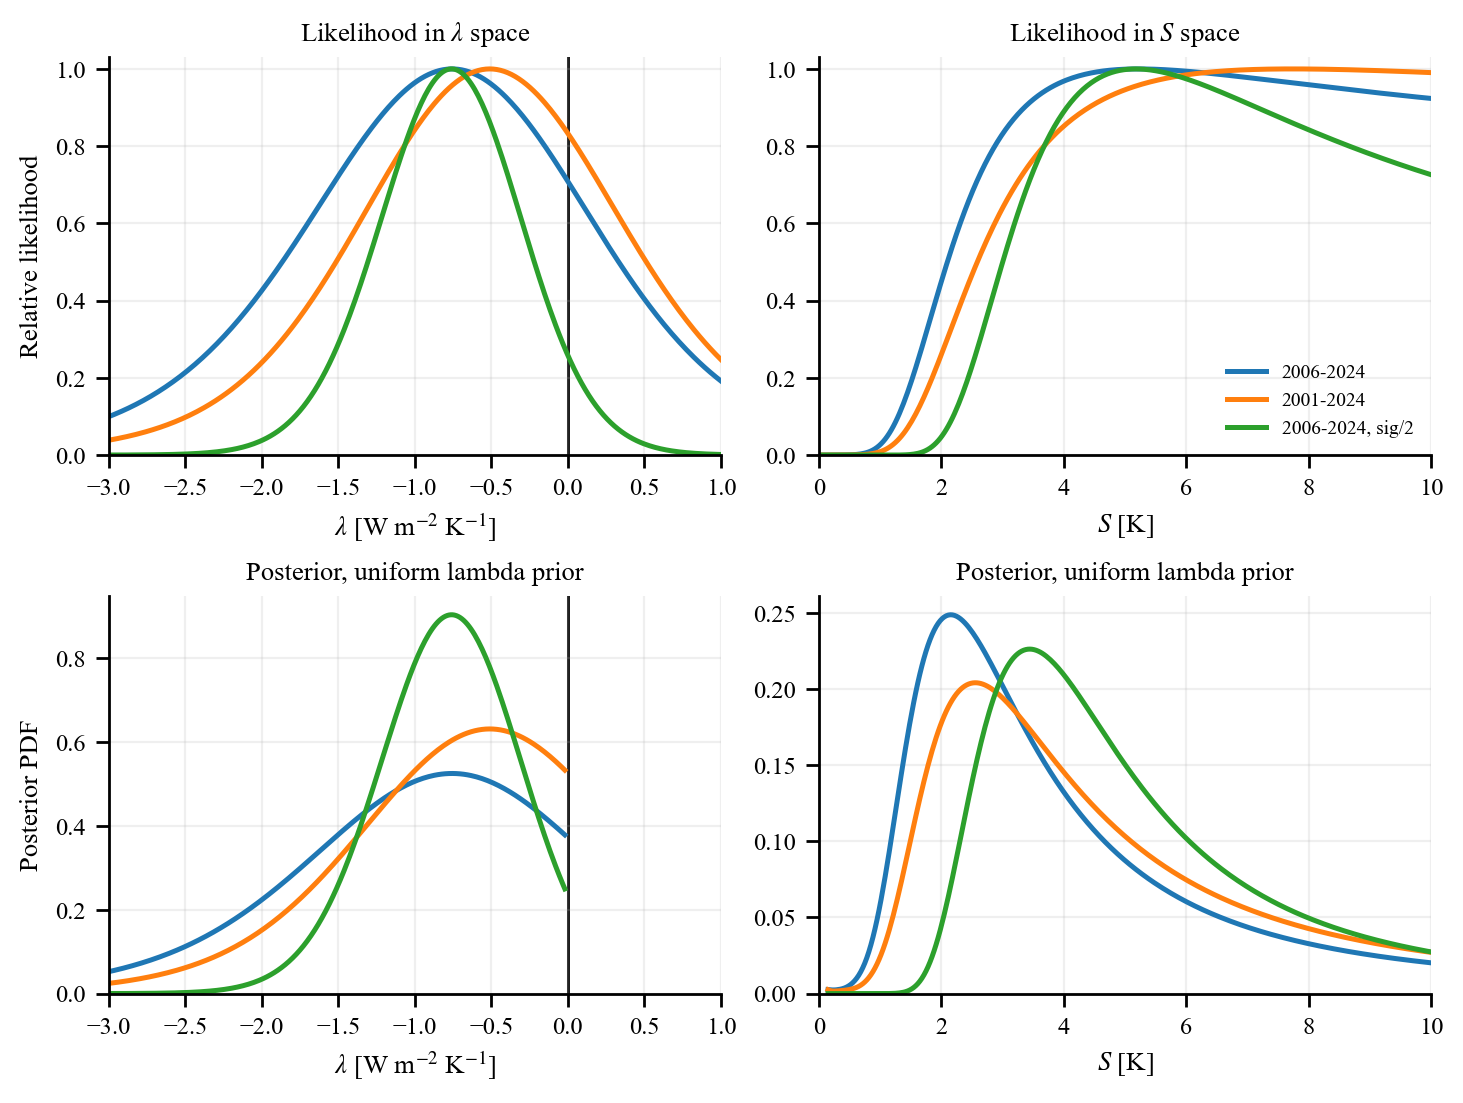

,case,posterior_prior,mode,p05,p17,p50,p83,p95
0,2006-2024,uniform_lambda,2.148,1.361,1.945,3.450,7.374,13.037
1,2001-2024,uniform_lambda,2.548,1.632,2.332,4.176,8.773,14.429
2,"2006-2024, sig/2",uniform_lambda,3.447,2.468,3.124,4.721,8.360,13.362


,case,F_mu,F_sig,N_mu,N_sig_reg,N_sig_score,T_mu,T_sig_ens,T_sig_score,dlamb_mu,dlamb_sig,uncertainty_scale
0,2006-2024,0.6792,0.1460,0.4524,0.1615,0.2041,0.2974,0.0074,0.0706,0.0,0.2,1.0
1,2001-2024,0.5696,0.1074,0.4474,0.1031,0.1389,0.2418,0.0054,0.0566,0.0,0.2,1.0
2,"2006-2024, sig/2",0.6792,0.1460,0.4524,0.1615,0.1020,0.2974,0.0074,0.0353,0.0,0.2,0.5


In [417]:
## Simple sensitivity comparison: periods, uncertainty scaling, and prior choice

save = False
dpis = 200
if save == True:
    dpis = 700

sensitivity_posterior_prior = "uniform_lambda"  ## "uniform_lambda", "log_lambda", or "uniform_S"
posterior_lam_bounds = (lam_prior_lo, lam_prior_hi)             ## used for lambda-defined priors
posterior_S_bounds = (0.01, 20.0)                ## used for uniform-S prior

sensitivity_cases = [
    {
        "label": _period_label(analysis_period),
        "period": analysis_period,
        "uncertainty_scale": 1.0,
        "dlamb_mu": analysis_dlamb_mu,
        "dlamb_sig": analysis_dlamb_sig,
        "iv_cov": analysis_iv_cov,
    },
    {
        "label": _period_label(analysis_period_alt),
        "period": analysis_period_alt,
        "uncertainty_scale": 1.0,
        "dlamb_mu": analysis_dlamb_mu_2001_2024,
        "dlamb_sig": analysis_dlamb_sig_2001_2024,
        "iv_cov": analysis_iv_cov_alt,
    },
    {
        "label": "2006-2024, sig/2",
        "period": slice(2006, 2024),
        "uncertainty_scale": 1 / 2,
        "dlamb_mu": analysis_dlamb_mu,
        "dlamb_sig": analysis_dlamb_sig,
        "iv_cov": analysis_iv_cov,
    },
]


def _prior_lambda_grid(lam, prior_kind):
    lam = np.asarray(lam, dtype=float)
    ok = (lam >= posterior_lam_bounds[0]) & (lam <= posterior_lam_bounds[1]) & (lam < 0)

    if prior_kind == "uniform_lambda":
        return np.where(ok, 1.0, 0.0)
    if prior_kind == "log_lambda":
        return np.where(ok, 1 / np.abs(lam), 0.0)
    if prior_kind == "uniform_S":
        S_from_lam = -analysis_F2x_mu / lam
        ok = ok & (S_from_lam >= posterior_S_bounds[0]) & (S_from_lam <= posterior_S_bounds[1])
        return np.where(ok, analysis_F2x_mu / lam**2, 0.0)

    raise ValueError("prior_kind must be 'uniform_lambda', 'log_lambda', or 'uniform_S'")


def _prior_S_grid(S, prior_kind):
    S = np.asarray(S, dtype=float)
    ok = np.isfinite(S) & (S > 0)

    if prior_kind in ["uniform_lambda", "log_lambda"]:
        lam_from_S = -analysis_F2x_mu / S
        ok = ok & (lam_from_S >= posterior_lam_bounds[0]) & (lam_from_S <= posterior_lam_bounds[1])
        if prior_kind == "uniform_lambda":
            return np.where(ok, analysis_F2x_mu / S**2, 0.0)
        return np.where(ok, 1 / S, 0.0)

    if prior_kind == "uniform_S":
        ok = ok & (S >= posterior_S_bounds[0]) & (S <= posterior_S_bounds[1])
        return np.where(ok, 1.0, 0.0)

    raise ValueError("prior_kind must be 'uniform_lambda', 'log_lambda', or 'uniform_S'")


sens_results = [
    _calc_likelihood_case(
        case["period"],
        label=case["label"],
        dlamb_mu=case["dlamb_mu"],
        dlamb_sig=case["dlamb_sig"],
        uncertainty_scale=case["uncertainty_scale"],
        iv_cov=case["iv_cov"],
    )
    for case in sensitivity_cases
]

fig, axs = plt.subplots(2, 2, figsize=(7.2, 5.4), dpi=dpis, constrained_layout=True)
colors = plt.cm.tab10(np.arange(len(sens_results)))

summary_rows = []
param_rows = []

for color, res in zip(colors, sens_results):
    lam = res["lam_grid"]
    S = res["S_grid"]
    label = res["label"]

    like_lam = res["like_lam_N"]
    like_S = res["like_S_N"]

    like_lam_rel = like_lam / np.nanmax(like_lam)
    like_S_rel = like_S / np.nanmax(like_S)

    prior_lam = _prior_lambda_grid(lam, sensitivity_posterior_prior)
    prior_S = _prior_S_grid(S, sensitivity_posterior_prior)

    post_lam = _area_norm(like_lam * prior_lam, lam)
    post_S = _area_norm(like_S * prior_S, S)

    ok_lam = prior_lam > 0
    ok_S = prior_S > 0

    axs[0, 0].plot(lam, like_lam_rel, color=color, lw=1.8, label=label)
    axs[0, 1].plot(S, like_S_rel, color=color, lw=1.8, label=label)
    axs[1, 0].plot(lam[ok_lam], post_lam[ok_lam], color=color, lw=1.8, label=label)
    axs[1, 1].plot(S[ok_S], post_S[ok_S], color=color, lw=1.8, label=label)

    row = {"case": label, "posterior_prior": sensitivity_posterior_prior}
    row.update(_pdf_summary(S[ok_S], post_S[ok_S]))
    summary_rows.append(row)

    p = res["params"]
    param_rows.append(
        {
            "case": label,
            "F_mu": p["F_mu"],
            "F_sig": p["F_sig"],
            "N_mu": p["N_mu"],
            "N_sig_reg": p["N_sig"],
            "N_sig_score": res["draws"]["N_score_sig"],
            "T_mu": p["T_mu"],
            "T_sig_ens": p["T_sig"],
            "T_sig_score": res["draws"]["T_score_sig"],
            "dlamb_mu": res["dlamb_mu"],
            "dlamb_sig": res["dlamb_sig"],
            "uncertainty_scale": res["uncertainty_scale"],
        }
    )

axs[0, 0].set_title(r"Likelihood in $\lambda$ space")
axs[0, 0].set_ylabel("Relative likelihood")
axs[0, 0].set_xlim(-3, 1)
axs[0, 0].set_ylim(0, 1.03)
axs[0, 0].grid(alpha=0.2)

axs[0, 1].set_title(r"Likelihood in $S$ space")
axs[0, 1].set_xlim(0, 10)
axs[0, 1].set_ylim(0, 1.03)
axs[0, 1].grid(alpha=0.2)
axs[0, 1].legend(frameon=False, fontsize=7)

axs[1, 0].set_title(f"Posterior, {sensitivity_posterior_prior.replace('_', ' ')} prior")
axs[1, 0].set_ylabel("Posterior PDF")
axs[1, 0].set_xlim(-3, 1)
axs[1, 0].set_ylim(bottom=0)
axs[1, 0].grid(alpha=0.2)

axs[1, 1].set_title(f"Posterior, {sensitivity_posterior_prior.replace('_', ' ')} prior")
axs[1, 1].set_xlim(0, 10)
axs[1, 1].set_ylim(bottom=0)
axs[1, 1].grid(alpha=0.2)

for ax in axs[:,0]:
    ax.axvline(0,c='k',lw=1.,zorder=0.1)

if sensitivity_posterior_prior in ["uniform_lambda", "log_lambda"]:
    S_lo = -analysis_F2x_mu / posterior_lam_bounds[0]
    S_hi = -analysis_F2x_mu / posterior_lam_bounds[1]
    # if S_lo < 12:
    #     axs[1, 1].axvline(S_lo, color="0.4", lw=0.8, ls=":")
    # if S_hi < 12:
    #     axs[1, 1].axvline(S_hi, color="0.4", lw=0.8, ls=":")

axs[1, 0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[1, 1].set_xlabel(r"$S$ [K]")
axs[0, 0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[0, 1].set_xlabel(r"$S$ [K]")

sns.despine()

if save == True:
    # Save as PDF
    figpath = './figures/' + 'grl/'
    fname = 'fig_tests_v0.pdf'
    if save == True:
        plt.savefig(figpath + fname, 
                    format='pdf', 
                    bbox_inches='tight',
                    dpi=dpis)
        print('saved ' + figpath + fname)

plt.show()

display(pd.DataFrame(summary_rows).round(3))
display(pd.DataFrame(param_rows).round(4))


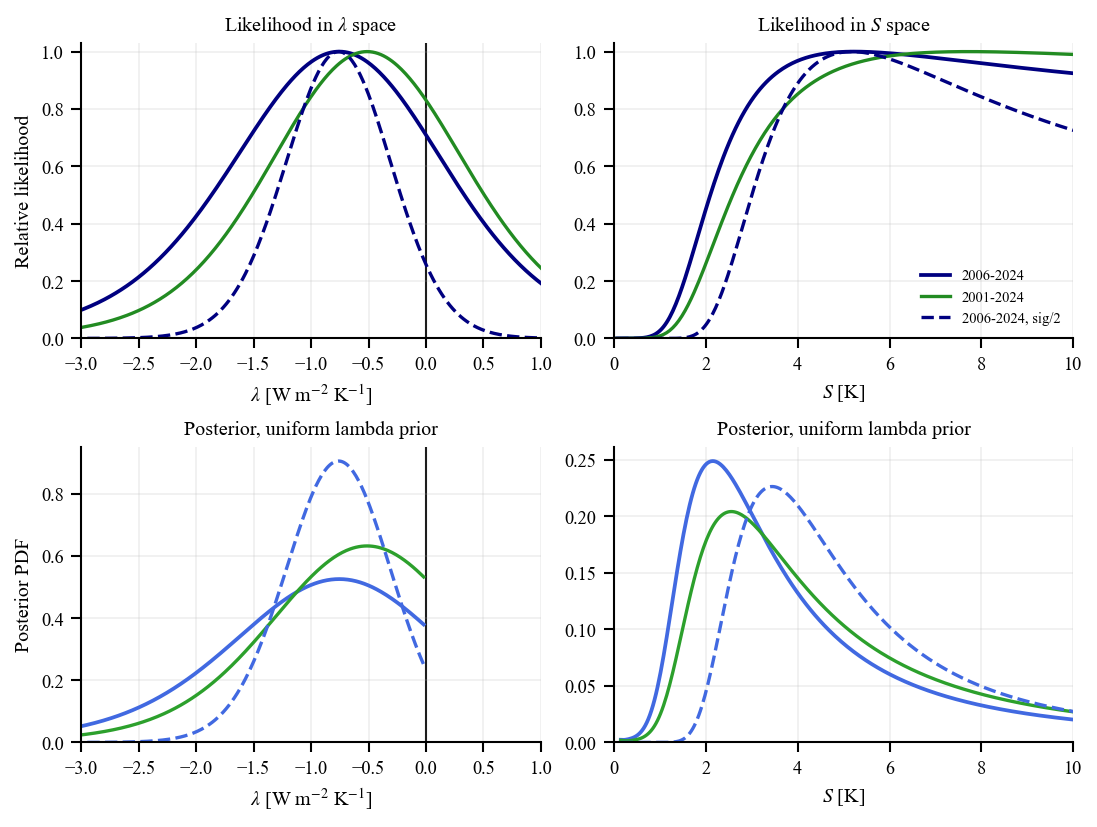

,case,posterior_prior,mode,p05,p17,p50,p83,p95
0,2006-2024,uniform_lambda,2.148,1.359,1.944,3.449,7.375,13.040
1,2001-2024,uniform_lambda,2.548,1.633,2.333,4.176,8.770,14.425
2,"2006-2024, sig/2",uniform_lambda,3.447,2.469,3.125,4.721,8.359,13.361


,case,F_mu,F_sig,N_mu,N_sig_reg,N_sig_score,T_mu,T_sig_ens,T_sig_score,dlamb_mu,dlamb_sig,uncertainty_scale
0,2006-2024,0.6792,0.1460,0.4524,0.1615,0.2041,0.2974,0.0074,0.0706,0.0,0.2,1.0
1,2001-2024,0.5696,0.1074,0.4474,0.1031,0.1389,0.2418,0.0054,0.0566,0.0,0.2,1.0
2,"2006-2024, sig/2",0.6792,0.1460,0.4524,0.1615,0.1020,0.2974,0.0074,0.0353,0.0,0.2,0.5


In [418]:
## Simple sensitivity comparison: periods, uncertainty scaling, and prior choice

save = False
dpis = 150
if save:
    dpis = 700

sensitivity_posterior_prior = "uniform_lambda"  ## "uniform_lambda", "log_lambda", or "uniform_S"
posterior_lam_bounds = (lam_prior_lo, lam_prior_hi)
posterior_S_bounds = (0.01, 20.0)

lw_main = 1.8
lw_alt = 1.6
lw_ref = 1.0

sensitivity_cases = [
    {
        "label": _period_label(analysis_period),
        "period": analysis_period,
        "uncertainty_scale": 1.0,
        "dlamb_mu": analysis_dlamb_mu,
        "dlamb_sig": analysis_dlamb_sig,
        "iv_cov": analysis_iv_cov,
        "like_color": "navy",
        "post_color": "royalblue",
        "ls": "-",
        "lw": lw_main,
    },
    {
        "label": _period_label(analysis_period_alt),
        "period": analysis_period_alt,
        "uncertainty_scale": 1.0,
        "dlamb_mu": analysis_dlamb_mu_2001_2024,
        "dlamb_sig": analysis_dlamb_sig_2001_2024,
        "iv_cov": analysis_iv_cov_alt,
        "like_color": "forestgreen",
        "post_color": "tab:green",
        "ls": "-",
        "lw": lw_alt,
    },
    {
        "label": "2006-2024, sig/2",
        "period": slice(2006, 2024),
        "uncertainty_scale": 1 / 2,
        "dlamb_mu": analysis_dlamb_mu,
        "dlamb_sig": analysis_dlamb_sig,
        "iv_cov": analysis_iv_cov,
        "like_color": "navy",
        "post_color": "royalblue",
        "ls": "--",
        "lw": lw_alt,
    },
]


def _prior_lambda_grid(lam, prior_kind):
    lam = np.asarray(lam, dtype=float)
    ok = (lam >= posterior_lam_bounds[0]) & (lam <= posterior_lam_bounds[1]) & (lam < 0)

    if prior_kind == "uniform_lambda":
        return np.where(ok, 1.0, 0.0)
    if prior_kind == "log_lambda":
        return np.where(ok, 1 / np.abs(lam), 0.0)
    if prior_kind == "uniform_S":
        S_from_lam = -analysis_F2x_mu / lam
        ok = ok & (S_from_lam >= posterior_S_bounds[0]) & (S_from_lam <= posterior_S_bounds[1])
        return np.where(ok, analysis_F2x_mu / lam**2, 0.0)

    raise ValueError("prior_kind must be 'uniform_lambda', 'log_lambda', or 'uniform_S'")


def _prior_S_grid(S, prior_kind):
    S = np.asarray(S, dtype=float)
    ok = np.isfinite(S) & (S > 0)

    if prior_kind in ["uniform_lambda", "log_lambda"]:
        lam_from_S = -analysis_F2x_mu / S
        ok = ok & (lam_from_S >= posterior_lam_bounds[0]) & (lam_from_S <= posterior_lam_bounds[1])
        if prior_kind == "uniform_lambda":
            return np.where(ok, analysis_F2x_mu / S**2, 0.0)
        return np.where(ok, 1 / S, 0.0)

    if prior_kind == "uniform_S":
        ok = ok & (S >= posterior_S_bounds[0]) & (S <= posterior_S_bounds[1])
        return np.where(ok, 1.0, 0.0)

    raise ValueError("prior_kind must be 'uniform_lambda', 'log_lambda', or 'uniform_S'")


sens_results = [
    _calc_likelihood_case(
        case["period"],
        label=case["label"],
        dlamb_mu=case["dlamb_mu"],
        dlamb_sig=case["dlamb_sig"],
        uncertainty_scale=case["uncertainty_scale"],
        iv_cov=case["iv_cov"],
    )
    for case in sensitivity_cases
]

fig, axs = plt.subplots(2, 2, figsize=(7.2, 5.4), dpi=dpis, constrained_layout=True)

summary_rows = []
param_rows = []

for case, res in zip(sensitivity_cases, sens_results):
    lam = res["lam_grid"]
    S = res["S_grid"]
    label = res["label"]

    like_lam = res["like_lam_N"]
    like_S = res["like_S_N"]

    like_lam_rel = like_lam / np.nanmax(like_lam)
    like_S_rel = like_S / np.nanmax(like_S)

    prior_lam = _prior_lambda_grid(lam, sensitivity_posterior_prior)
    prior_S = _prior_S_grid(S, sensitivity_posterior_prior)

    post_lam = _area_norm(like_lam * prior_lam, lam)
    post_S = _area_norm(like_S * prior_S, S)

    ok_lam = prior_lam > 0
    ok_S = prior_S > 0

    axs[0, 0].plot(
        lam, like_lam_rel,
        color=case["like_color"], ls=case["ls"], lw=case["lw"], label=label
    )
    axs[0, 1].plot(
        S, like_S_rel,
        color=case["like_color"], ls=case["ls"], lw=case["lw"], label=label
    )
    axs[1, 0].plot(
        lam[ok_lam], post_lam[ok_lam],
        color=case["post_color"], ls=case["ls"], lw=case["lw"], label=label
    )
    axs[1, 1].plot(
        S[ok_S], post_S[ok_S],
        color=case["post_color"], ls=case["ls"], lw=case["lw"], label=label
    )

    row = {"case": label, "posterior_prior": sensitivity_posterior_prior}
    row.update(_pdf_summary(S[ok_S], post_S[ok_S]))
    summary_rows.append(row)

    p = res["params"]
    param_rows.append(
        {
            "case": label,
            "F_mu": p["F_mu"],
            "F_sig": p["F_sig"],
            "N_mu": p["N_mu"],
            "N_sig_reg": p["N_sig"],
            "N_sig_score": res["draws"]["N_score_sig"],
            "T_mu": p["T_mu"],
            "T_sig_ens": p["T_sig"],
            "T_sig_score": res["draws"]["T_score_sig"],
            "dlamb_mu": res["dlamb_mu"],
            "dlamb_sig": res["dlamb_sig"],
            "uncertainty_scale": res["uncertainty_scale"],
        }
    )

axs[0, 0].set_title(r"Likelihood in $\lambda$ space")
axs[0, 0].set_ylabel("Relative likelihood")
axs[0, 0].set_xlim(-3, 1)
axs[0, 0].set_ylim(0, 1.03)
axs[0, 0].grid(alpha=0.2)

axs[0, 1].set_title(r"Likelihood in $S$ space")
axs[0, 1].set_xlim(0, 10)
axs[0, 1].set_ylim(0, 1.03)
axs[0, 1].grid(alpha=0.2)
axs[0, 1].legend(frameon=False, fontsize=7)

axs[1, 0].set_title(f"Posterior, {sensitivity_posterior_prior.replace('_', ' ')} prior")
axs[1, 0].set_ylabel("Posterior PDF")
axs[1, 0].set_xlim(-3, 1)
axs[1, 0].set_ylim(bottom=0)
axs[1, 0].grid(alpha=0.2)

axs[1, 1].set_title(f"Posterior, {sensitivity_posterior_prior.replace('_', ' ')} prior")
axs[1, 1].set_xlim(0, 10)
axs[1, 1].set_ylim(bottom=0)
axs[1, 1].grid(alpha=0.2)

for ax in axs[:, 0]:
    ax.axvline(0, c="k", lw=lw_ref, zorder=0.1)

axs[1, 0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[1, 1].set_xlabel(r"$S$ [K]")
axs[0, 0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[0, 1].set_xlabel(r"$S$ [K]")

sns.despine()

if save:
    figpath = "./figures/grl/"
    fname = "fig_tests_v0.pdf"
    plt.savefig(figpath + fname, format="pdf", bbox_inches="tight", dpi=dpis)
    print("saved " + figpath + fname)

plt.show()

display(pd.DataFrame(summary_rows).round(3))
display(pd.DataFrame(param_rows).round(4))

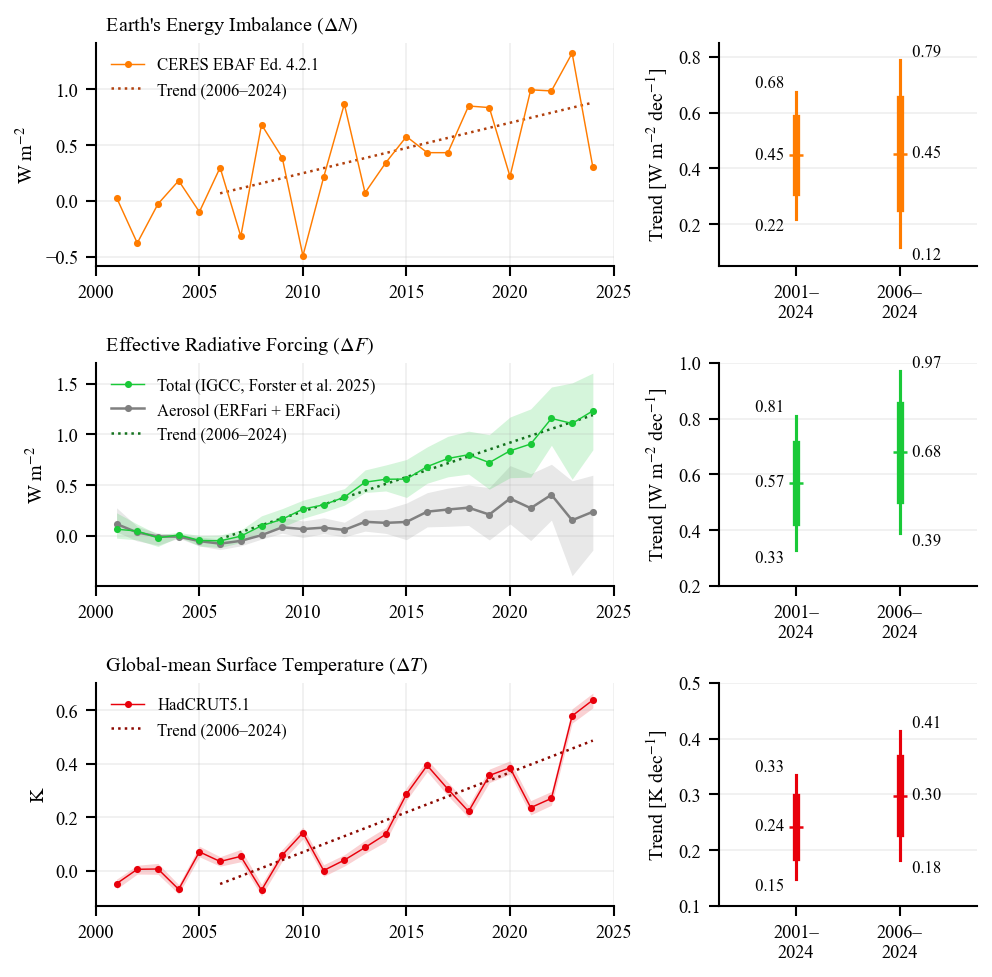

In [398]:
sns.set_context('paper')

save = False
dpis = 150
if save == True:
    dpis = 700

## Energy-budget component time series and trend summaries
add_trend_text = True  ## if True, label median and 5-95% ranges in right panels
trend_text_dx = 0.035
trend_text_fs = 'small'

plot_period = data_tsel
baseslice = slice(2001, 2006)

trend_summary_cases = [
    {
        # "label": _period_label(analysis_period_alt),
        "label": "2001–\n2024",
        "period": analysis_period_alt,
        "dlamb_mu": analysis_dlamb_mu_2001_2024,
        "dlamb_sig": analysis_dlamb_sig_2001_2024,
        "iv_cov": analysis_iv_cov_alt,
        "x": -0.22,
    },
    {
        # "label": _period_label(analysis_period),
        "label": "2006–\n2024",
        "period": analysis_period,
        "dlamb_mu": analysis_dlamb_mu,
        "dlamb_sig": analysis_dlamb_sig,
        "iv_cov": analysis_iv_cov,
        "x": 0.22,
    },
]

trend_draws = {}
for case in trend_summary_cases:
    params = _trend_params(case["period"], temp_key=analysis_temp_key)
    trend_draws[case["label"]] = _draw_case_samples(
        params,
        case["dlamb_mu"],
        case["dlamb_sig"],
        iv_cov=case["iv_cov"],
    )

fig, axs = plt.subplots(
    3, 2,
    figsize=(6.5, 6.4),
    width_ratios=[4, 2],
    dpi=dpis,
    constrained_layout=True,
)

palette = 'bright'
palette2 = 'dark'
component_specs = [
    {
        "name": "N",
        "draw_key": "Ndot",
        "title": r"  Earth's Energy Imbalance $(\Delta N)$",
        "unit": r"W m$^{-2}$",
        "trend_unit": r"Trend [W m$^{-2}$ dec$^{-1}$]",
        "series": ceres["gtoa_net_all_mon"].sel(year=plot_period) - ceres["gtoa_net_all_mon"].sel(year=baseslice).mean(dim="year"),
        "time_dim": "year",
        "label":'CERES EBAF Ed. 4.2.1',
        "color": sns.color_palette(palette)[1], #"royalblue",
        "colorline": sns.color_palette(palette2)[1], #"royalblue",
    },
    {
        "name": "F",
        "draw_key": "Fdot",
        "title": r"  Effective Radiative Forcing $(\Delta F)$",
        "unit": r"W m$^{-2}$",
        "trend_unit": r"Trend [W m$^{-2}$ dec$^{-1}$]",
        "series": erf_total.sel(time=plot_period) - erf_total.sel(time=baseslice).mean(dim="time"),
        "time_dim": "time",
        "label":'Total (IGCC, Forster et al. 2025)',
        "color": sns.color_palette(palette)[2], #"tab:orange",
        "colorline": sns.color_palette(palette2)[2], #"royalblue",
    },
    {
        "name": "T",
        "draw_key": "Tdot",
        "title": r"  Global-mean Surface Temperature $(\Delta T)$",
        "unit": r"K",
        "trend_unit": r"Trend [K dec$^{-1}$]",
        "series": gmst_dict[analysis_temp_key].sel(year=plot_period) - gmst_dict[analysis_temp_key].sel(year=baseslice).mean(dim="year"),
        "time_dim": "year",
        "label":analysis_temp_key,
        "color": sns.color_palette(palette)[3], #"royalblue",
        "colorline": sns.color_palette(palette2)[3], #"royalblue",
    },
]

for i, spec in enumerate(component_specs):
    ax = axs[i, 0]
    da = spec["series"]
    tdim = spec["time_dim"]
    edims = _ens_dims(da, tdim)

    if edims:
        mean = da.mean(edims)
        q = da.quantile([0.05, 0.95], dim=edims)
        ax.fill_between(mean[tdim], q.sel(quantile=0.05), q.sel(quantile=0.95), color=spec["color"], alpha=0.18, lw=0)
        ax.plot(mean[tdim], mean, color=spec["color"], lw=0.7, label=spec['label'], marker='.',zorder=4)
    else:
        ax.plot(da[tdim], da, color=spec["color"], lw=0.7, label=spec['label'], marker='.',zorder=4)

    if spec['name'] == 'F':
        aer_da = (ds_erf['aerosol-radiation_interactions'].sel(time=plot_period) + 
                  ds_erf['aerosol-cloud_interactions'].sel(time=plot_period))
        aer_da = aer_da - aer_da.sel(time=baseslice).mean(dim="time")
        q = aer_da.quantile([0.05, 0.95], dim=edims)
        ax.plot(aer_da.time, aer_da.mean(dim=edims),color='gray',ls='-',marker='.',label='Aerosol (ERFari + ERFaci)')
        ax.fill_between(aer_da.time, q.sel(quantile=0.05), q.sel(quantile=0.95), color='gray', alpha=0.18, lw=0,zorder=0)

    ## trend lines only: 2006-2024 for all; ERF also gets 2001-2024
    trend_line_periods = [
        {"period": analysis_period, "color": "0.25", "ls": ":", "label": "trend 2006-2024"},
    ]
    
    # if spec["name"] == "F":
    #     trend_line_periods.insert(
    #         0,
    #         {"period": analysis_period_alt, "color": , "ls": ":", "label": "trend 2001-2024"},
    #     )
    
    trend_source = mean if edims else da
    
    for regspec in trend_line_periods:
        reg = trend_source.sel({tdim: regspec["period"]})
    
        sns.regplot(
            x=reg[tdim].values,
            y=reg.values,
            scatter=False,
            ci=None,
            ax=ax,
            color=spec["colorline"],
            label=f'Trend ({analysis_period.start}–{analysis_period.stop})',
            line_kws={
                "linestyle": regspec["ls"],
                "linewidth": 1.2,
                "label": regspec["label"],
            },
        )
    ax.legend(frameon=False, fontsize="small", loc="best")
    ax.grid(alpha=0.2)
    ax.set_title(spec["title"], loc="left")
    ax.set_ylabel(spec["unit"])
    ax.set_xlabel("")

    ax = axs[i, 1]
    for case in trend_summary_cases:
        vals = np.asarray(trend_draws[case["label"]][spec["draw_key"]], dtype=float)
        x = case["x"]
        q05, q17, q50, q83, q95 = np.nanquantile(vals, [0.05, 0.17, 0.50, 0.83, 0.95])
        ax.scatter(x, np.nanmean(vals), color=spec["color"], s=45, marker="_", zorder=3)
        ax.plot([x, x], [q05, q95], c=spec["color"], lw=1.5)
        ax.plot([x, x], [q17, q83], c=spec["color"], lw=3.5)

        if add_trend_text:
            dx = -trend_text_dx if x < 0 else trend_text_dx
            ha = "right" if x < 0 else "left"
            for qval, qlabel, va in [
                (q95, "95%", "bottom"),
                (q50, "50%", "center"),
                (q05, "5%", "top"),
            ]:
                ax.text(
                    x + dx,
                    qval,
                    f" {qval:.2f} ",
                    color="k",
                    fontsize=trend_text_fs,
                    ha=ha,
                    va=va,
                    zorder=5,
                )

    ax.set_xlim(-0.55, 0.55)
    ax.set_xticks([case["x"] for case in trend_summary_cases])
    ax.set_xticklabels([case["label"] for case in trend_summary_cases], rotation=0)
    ax.set_ylabel(spec["trend_unit"])
    ax.grid(alpha=0.2, axis="y")

for ax in axs[:,0]:
    ax.set_xlim(2000,2025.005)

axs[0,1].set_ylim(0.05,0.85)
axs[1,1].set_ylim(0.2,1.0)
axs[2,1].set_ylim(0.1,0.5)

sns.despine()

if save == True:
    # Save as PDF
    figpath = './figures/' + 'grl/'
    fname = 'fig_timeseries.pdf'
    if save == True:
        plt.savefig(figpath + fname, 
                    format='pdf', 
                    bbox_inches='tight',
                    dpi=dpis)
        print('saved ' + figpath + fname)

plt.show()


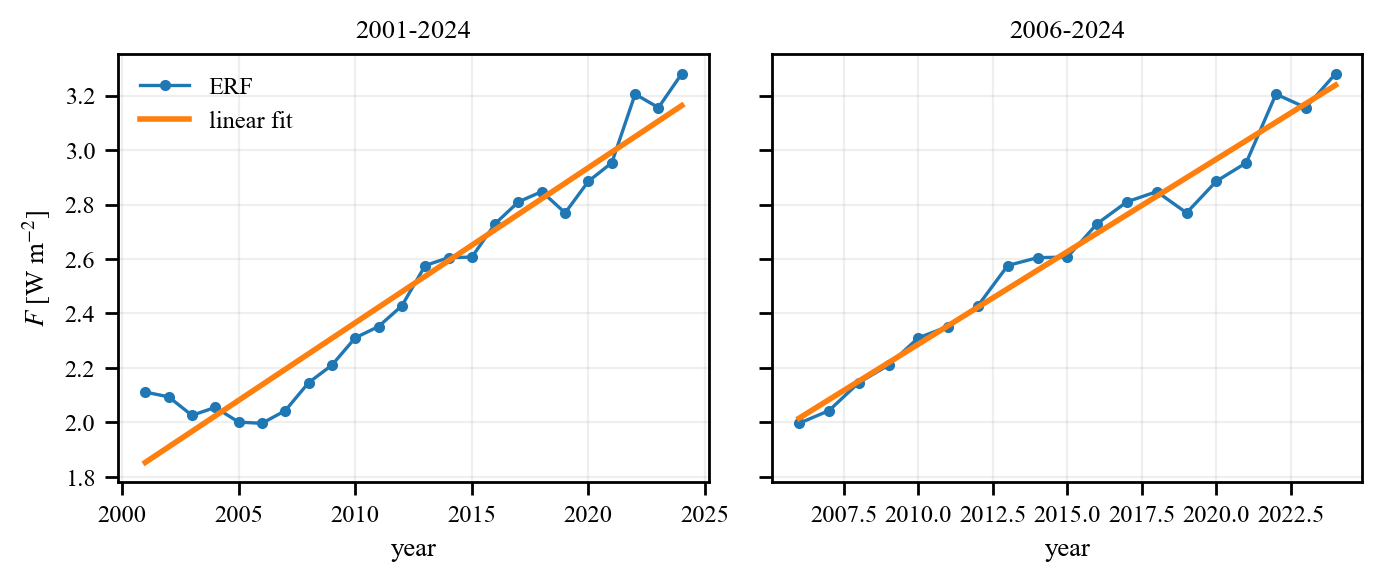

,slope_Wm2_dec,R2,RMSE_Wm2,MAE_Wm2,resid_lag1,quad_RMSE_gain_%
period,,,,,,
2001-2024,0.5696,0.9374,0.1019,0.0831,0.6800,25.2749
2006-2024,0.6792,0.9782,0.0555,0.0424,0.1799,0.5216


In [300]:
periods = {
    "2001-2024": slice(2001, 2024),
    "2006-2024": slice(2006, 2024),
}

rows = []

fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=200, sharey=True)

for ax, (label, tsel) in zip(axs, periods.items()):
    y = erf_total.sel(time=tsel)

    ## use ensemble mean for the fit diagnostic
    if "ensemble" in y.dims:
        y = y.mean("ensemble")

    x = y.time.values.astype(float)
    yy = y.values.astype(float)

    fit = linregress(x, yy)
    yhat = fit.intercept + fit.slope * x
    resid = yy - yhat

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    r2 = fit.rvalue**2
    rho1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]

    ## quadratic comparison
    p2 = np.polyfit(x, yy, 2)
    yhat2 = np.polyval(p2, x)
    rmse_quad = np.sqrt(np.mean((yy - yhat2)**2))

    rows.append({
        "period": label,
        "slope_Wm2_dec": 10 * fit.slope,
        "R2": r2,
        "RMSE_Wm2": rmse,
        "MAE_Wm2": mae,
        "resid_lag1": rho1,
        "quad_RMSE_gain_%": 100 * (rmse - rmse_quad) / rmse,
    })

    ax.plot(x, yy, "o-", ms=3, label="ERF")
    ax.plot(x, yhat, "-", lw=2, label="linear fit")
    ax.grid(alpha=0.2)
    ax.set_title(label)
    ax.set_xlabel("year")

axs[0].set_ylabel(r"$F$ [W m$^{-2}$]")
axs[0].legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame(rows).set_index("period").round(4)

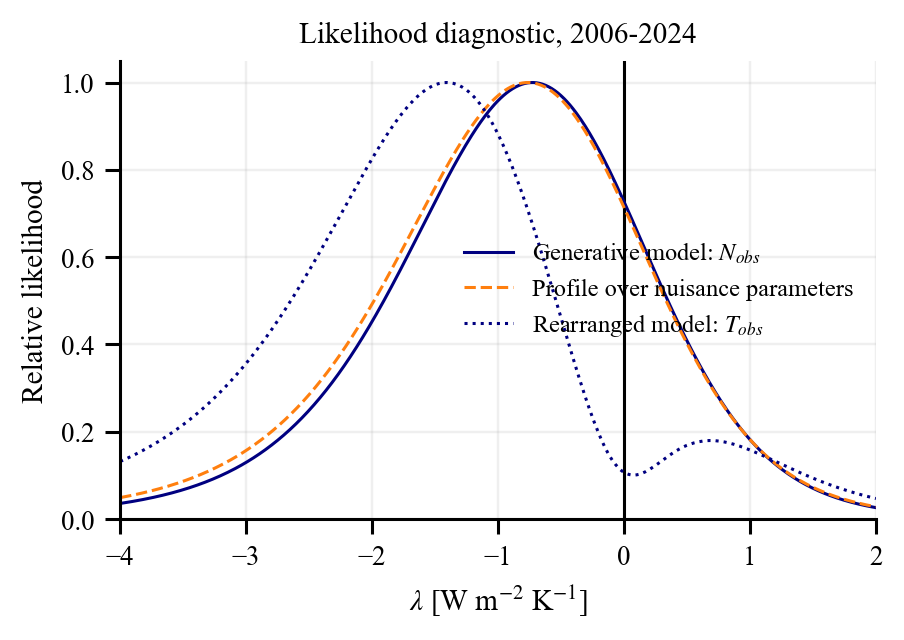

Modes [W m-2 K-1]
generative_Nobs_marginal   -0.729
nuisance_profile           -0.766
rearranged_Tobs_marginal   -1.415
dtype: float64
CPU times: user 14.2 s, sys: 36.2 ms, total: 14.3 s
Wall time: 15.6 s


In [350]:
%%time
## Diagnostic: generative marginal vs rearranged marginal vs profile likelihood
## This uses the same 2006-2024 inputs as the main analysis, but works directly in lambda space.

from scipy.optimize import minimize

## controls
diagnostic_mc_n = 1_000_000
# diagnostic_mc_n = 100_000
lam_grid_diag = np.linspace(-4, 2, 500)
show_direct_implied_lambda = False  ## keep hidden by default; useful only as a KDE diagnostic

## recalculate with more draws and a fine lambda grid
diagnostic_params = _trend_params(analysis_period, temp_key=analysis_temp_key)
draws = _draw_case_samples(
    diagnostic_params,
    analysis_dlamb_mu,
    analysis_dlamb_sig,
    mc_n=diagnostic_mc_n,
    iv_cov=analysis_iv_cov,
)

like_N_diag = np.zeros_like(lam_grid_diag)
like_T_diag = np.zeros_like(lam_grid_diag)

for i, lam in enumerate(lam_grid_diag):
    lam_eff = lam - draws["dlamb"]

    ## generative model: N_obs is observed; F, T, and delta-lambda are nuisance/latent quantities
    Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
    like_N_diag[i] = np.nanmean(
        norm.pdf(diagnostic_params["N_mu"], loc=Npred, scale=draws["N_score_sig"])
    )

    ## rearranged sensitivity: T_obs is placed on the left-hand side instead
    Tpred = np.where(np.abs(lam_eff) > 1e-8, (draws["Ndot"] - draws["Fdot"]) / lam_eff, np.nan)
    like_T_diag[i] = np.nanmean(
        norm.pdf(diagnostic_params["T_mu"], loc=Tpred, scale=draws["T_score_sig"])
    )

like_N_diag = like_N_diag / np.nanmax(like_N_diag)
like_T_diag = like_T_diag / np.nanmax(like_T_diag)

## Profile likelihood: maximize over nuisance values instead of averaging over them.
## This is a frequentist-style sensitivity check, not the Bayesian target likelihood.
_eps = 1e-10
Fdot_sig_profile = np.sqrt(diagnostic_params["F_sig"]**2 + Fdot_struct_sig**2)
Tdot_sig_profile = float(np.maximum(draws["T_score_sig"], _eps))
Ndot_sig_profile = float(np.maximum(draws["N_score_sig"], _eps))
dlamb_sig_profile = float(np.maximum(abs(analysis_dlamb_sig), _eps))

Tdot_mu = float(diagnostic_params["T_mu"])
Fdot_mu = float(diagnostic_params["F_mu"])
Ndot_mu = float(diagnostic_params["N_mu"])
dlamb_mu = float(analysis_dlamb_mu)


def _neg_log_profile_nuisance(theta, lam):
    Tdot_true, Fdot_true, dlamb_true = theta
    Ndot_pred = Fdot_true + (lam - dlamb_true) * Tdot_true
    return -(
        norm.logpdf(Tdot_true, loc=Tdot_mu, scale=Tdot_sig_profile)
        + norm.logpdf(Fdot_true, loc=Fdot_mu, scale=Fdot_sig_profile)
        + norm.logpdf(dlamb_true, loc=dlamb_mu, scale=dlamb_sig_profile)
        + norm.logpdf(Ndot_mu, loc=Ndot_pred, scale=Ndot_sig_profile)
    )

profile_loglike = np.full_like(lam_grid_diag, np.nan, dtype=float)
theta0 = np.array([Tdot_mu, Fdot_mu, dlamb_mu], dtype=float)

for i, lam in enumerate(lam_grid_diag):
    opt = minimize(_neg_log_profile_nuisance, theta0, args=(lam,), method="BFGS")
    if not opt.success:
        opt = minimize(
            _neg_log_profile_nuisance,
            np.array([Tdot_mu, Fdot_mu, dlamb_mu], dtype=float),
            args=(lam,),
            method="BFGS",
        )
    profile_loglike[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0 = opt.x

like_profile_diag = np.exp(profile_loglike - np.nanmax(profile_loglike))

if show_direct_implied_lambda:
    lam_implied = (draws["Ndot"] - draws["Fdot"]) / draws["Tdot"] + draws["dlamb"]
    lam_implied = lam_implied[np.isfinite(lam_implied)]
    kde_lam = gaussian_kde(lam_implied)
    like_direct = kde_lam(lam_grid_diag)
    like_direct = like_direct / np.nanmax(like_direct)

fig, ax = plt.subplots(figsize=(4.2, 3.0), dpi=220)
ax.axvline(0, c="k", lw=1)

if show_direct_implied_lambda:
    ax.plot(
        lam_grid_diag,
        like_direct,
        label=r"Transformed implied-$\lambda$ KDE",
        lw=2.4,
        c="0.25",
    )

ax.plot(
    lam_grid_diag,
    like_N_diag,
    label=r"Generative model: $N_{obs}$",
    ls="-",
    c="navy",
    lw=1.,
)
ax.plot(
    lam_grid_diag,
    like_profile_diag,
    label="Profile over nuisance parameters",
    ls="--",
    c="tab:orange",
    lw=1.,
)
ax.plot(
    lam_grid_diag,
    like_T_diag,
    label=r"Rearranged model: $T_{obs}$",
    ls=":",
    c="navy",
    lw=1.,
)

ax.set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
ax.set_ylabel("Relative likelihood")
ax.set_title(f"Likelihood diagnostic, {_period_label(analysis_period)}")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize="small")
ax.set_xlim(-4, 2)
ax.set_ylim(0, 1.05)
sns.despine()

plt.tight_layout()
plt.show()

mode_values = {
    "generative_Nobs_marginal": lam_grid_diag[np.nanargmax(like_N_diag)],
    "nuisance_profile": lam_grid_diag[np.nanargmax(like_profile_diag)],
    "rearranged_Tobs_marginal": lam_grid_diag[np.nanargmax(like_T_diag)],
}
if show_direct_implied_lambda:
    mode_values["transformed_implied_lambda_KDE"] = lam_grid_diag[np.nanargmax(like_direct)]

print("Modes [W m-2 K-1]")
print(pd.Series(mode_values).round(3))


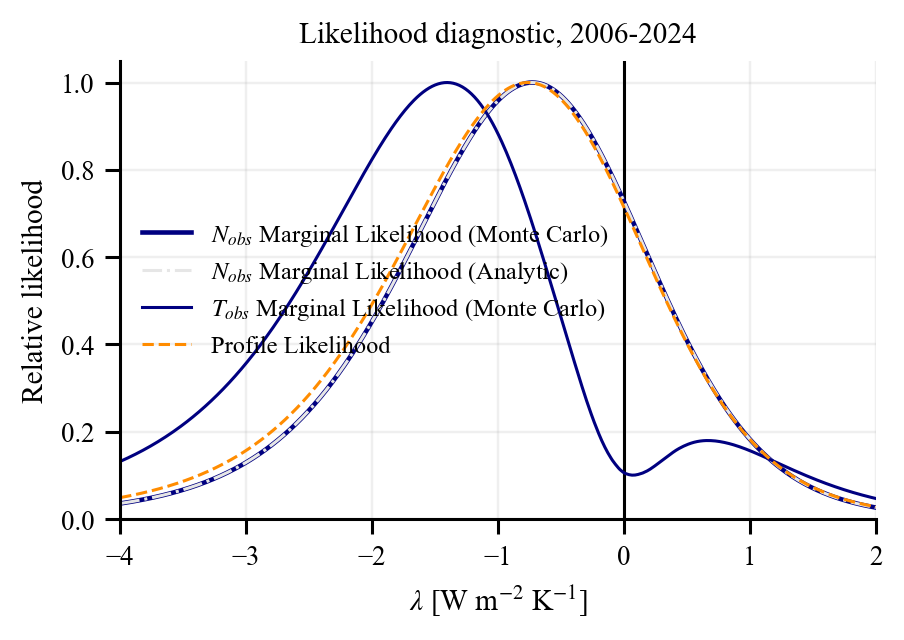

Modes [W m-2 K-1]
MC_marginal_Nobs           -0.729
analytic_marginal_Nobs     -0.729
profile_nuisance           -0.766
rearranged_marginal_Tobs   -1.403
dtype: float64
CPU times: user 14.1 s, sys: 20.2 ms, total: 14.1 s
Wall time: 17.1 s


In [356]:
%%time
## Diagnostic: generative marginal vs rearranged marginal vs profile likelihood
## This uses the same 2006-2024 inputs as the main analysis, but works directly in lambda space.

from scipy.optimize import minimize

## controls
diagnostic_mc_n = 1_000_000
lam_grid_diag = np.linspace(-4, 2, 500)
show_direct_implied_lambda = False  ## keep hidden by default; useful only as a KDE diagnostic

## recalculate with more draws and a fine lambda grid
diagnostic_params = _trend_params(analysis_period, temp_key=analysis_temp_key)
draws = _draw_case_samples(
    diagnostic_params,
    analysis_dlamb_mu,
    analysis_dlamb_sig,
    mc_n=diagnostic_mc_n,
    iv_cov=analysis_iv_cov,
    temp_key=analysis_temp_key,
)

like_N_diag = np.zeros_like(lam_grid_diag)
like_T_diag = np.zeros_like(lam_grid_diag)

for i, lam in enumerate(lam_grid_diag):
    lam_eff = lam - draws["dlamb"]

    ## Monte Carlo marginal for the generative model
    Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
    like_N_diag[i] = np.nanmean(
        norm.pdf(diagnostic_params["N_mu"], loc=Npred, scale=draws["N_score_sig"])
    )

    ## Rearranged sensitivity
    Tpred = np.where(np.abs(lam_eff) > 1e-8, (draws["Ndot"] - draws["Fdot"]) / lam_eff, np.nan)
    like_T_diag[i] = np.nanmean(
        norm.pdf(diagnostic_params["T_mu"], loc=Tpred, scale=draws["T_score_sig"])
    )

like_N_diag = like_N_diag / np.nanmax(like_N_diag)
like_T_diag = like_T_diag / np.nanmax(like_T_diag)

## Profile likelihood: maximize over nuisance values instead of averaging over them.
_eps = 1e-10
Fdot_sig_profile = np.sqrt(diagnostic_params["F_sig"]**2 + Fdot_struct_sig**2)
Tdot_sig_profile = float(np.maximum(draws["T_score_sig"], _eps))
Ndot_sig_profile = float(np.maximum(draws["N_score_sig"], _eps))
dlamb_sig_profile = float(np.maximum(abs(analysis_dlamb_sig), _eps))

Tdot_mu = float(diagnostic_params["T_mu"])
Fdot_mu = float(diagnostic_params["F_mu"])
Ndot_mu = float(diagnostic_params["N_mu"])
dlamb_mu = float(analysis_dlamb_mu)


def _neg_log_profile_nuisance(theta, lam):
    Tdot_true, Fdot_true, dlamb_true = theta
    Ndot_pred = Fdot_true + (lam - dlamb_true) * Tdot_true
    return -(
        norm.logpdf(Tdot_true, loc=Tdot_mu, scale=Tdot_sig_profile)
        + norm.logpdf(Fdot_true, loc=Fdot_mu, scale=Fdot_sig_profile)
        + norm.logpdf(dlamb_true, loc=dlamb_mu, scale=dlamb_sig_profile)
        + norm.logpdf(Ndot_mu, loc=Ndot_pred, scale=Ndot_sig_profile)
    )


profile_loglike = np.full_like(lam_grid_diag, np.nan, dtype=float)
theta0 = np.array([Tdot_mu, Fdot_mu, dlamb_mu], dtype=float)

for i, lam in enumerate(lam_grid_diag):
    opt = minimize(_neg_log_profile_nuisance, theta0, args=(lam,), method="BFGS")
    if not opt.success:
        opt = minimize(
            _neg_log_profile_nuisance,
            np.array([Tdot_mu, Fdot_mu, dlamb_mu], dtype=float),
            args=(lam,),
            method="BFGS",
        )
    profile_loglike[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0 = opt.x

like_profile_diag = np.exp(profile_loglike - np.nanmax(profile_loglike))

## Analytic marginal likelihood for the same score-N generative model.
## Exact for Gaussian Fdot, Tdot, and dlambda.
n_gh = 100
xgh, wgh = np.polynomial.hermite.hermgauss(n_gh)

Fdot_sig_analytic = Fdot_sig_profile
Tdot_sig_analytic = Tdot_sig_profile
Ndot_sig_analytic = Ndot_sig_profile

dlamb_nodes = dlamb_mu + np.sqrt(2) * dlamb_sig_profile * xgh
dlamb_weights = wgh / np.sqrt(np.pi)

beta = lam_grid_diag[:, None] - dlamb_nodes[None, :]

Npred_mu = Fdot_mu + beta * Tdot_mu
Npred_sig = np.sqrt(
    Ndot_sig_analytic**2
    + Fdot_sig_analytic**2
    + (beta * Tdot_sig_analytic)**2
)

like_analytic_diag = np.sum(
    dlamb_weights[None, :]
    * norm.pdf(Ndot_mu, loc=Npred_mu, scale=Npred_sig),
    axis=1,
)
like_analytic_diag = like_analytic_diag / np.nanmax(like_analytic_diag)

if show_direct_implied_lambda:
    lam_implied = (draws["Ndot"] - draws["Fdot"]) / draws["Tdot"] + draws["dlamb"]
    lam_implied = lam_implied[np.isfinite(lam_implied)]
    kde_lam = gaussian_kde(lam_implied)
    like_direct = kde_lam(lam_grid_diag)
    like_direct = like_direct / np.nanmax(like_direct)

fig, ax = plt.subplots(figsize=(4.2, 3.0), dpi=220)
ax.axvline(0, c="k", lw=1)

if show_direct_implied_lambda:
    ax.plot(
        lam_grid_diag,
        like_direct,
        label=r"Transformed implied-$\lambda$ KDE",
        lw=2.4,
        c="0.25",
    )

ax.plot(
    lam_grid_diag,
    like_N_diag,
    # label=r"Monte Carlo marginal: $N_{obs}$",
    label=r"$N_{obs}$ Marginal Likelihood (Monte Carlo)",
    ls="-",
    c="navy",
    lw=1.5,
)
ax.plot(
    lam_grid_diag,
    like_analytic_diag,
    label=r"$N_{obs}$ Marginal Likelihood (Analytic)", 
    ls="-.",
    c="0.9",
    lw=1.0,
)
ax.plot(
    lam_grid_diag,
    like_T_diag,
    label=r"$T_{obs}$ Marginal Likelihood (Monte Carlo)",
    ls="-",
    c="tab:red",
    lw=1.0,
)

ax.plot(
    lam_grid_diag,
    like_profile_diag,
    label="Profile Likelihood",
    ls="--",
    c="darkorange",
    lw=1.0,
)


ax.set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
ax.set_ylabel("Relative likelihood")
ax.set_title(f"Likelihood diagnostic, {_period_label(analysis_period)}")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize="small")
ax.set_xlim(-4, 2)
ax.set_ylim(0, 1.05)
sns.despine()

plt.tight_layout()
plt.show()

mode_values = {
    "MC_marginal_Nobs": lam_grid_diag[np.nanargmax(like_N_diag)],
    "analytic_marginal_Nobs": lam_grid_diag[np.nanargmax(like_analytic_diag)],
    "profile_nuisance": lam_grid_diag[np.nanargmax(like_profile_diag)],
    "rearranged_marginal_Tobs": lam_grid_diag[np.nanargmax(like_T_diag)],
}
if show_direct_implied_lambda:
    mode_values["transformed_implied_lambda_KDE"] = lam_grid_diag[np.nanargmax(like_direct)]

print("Modes [W m-2 K-1]")
print(pd.Series(mode_values).round(3))

saved ./figures/grl/fig_appendix_likelihood.pdf


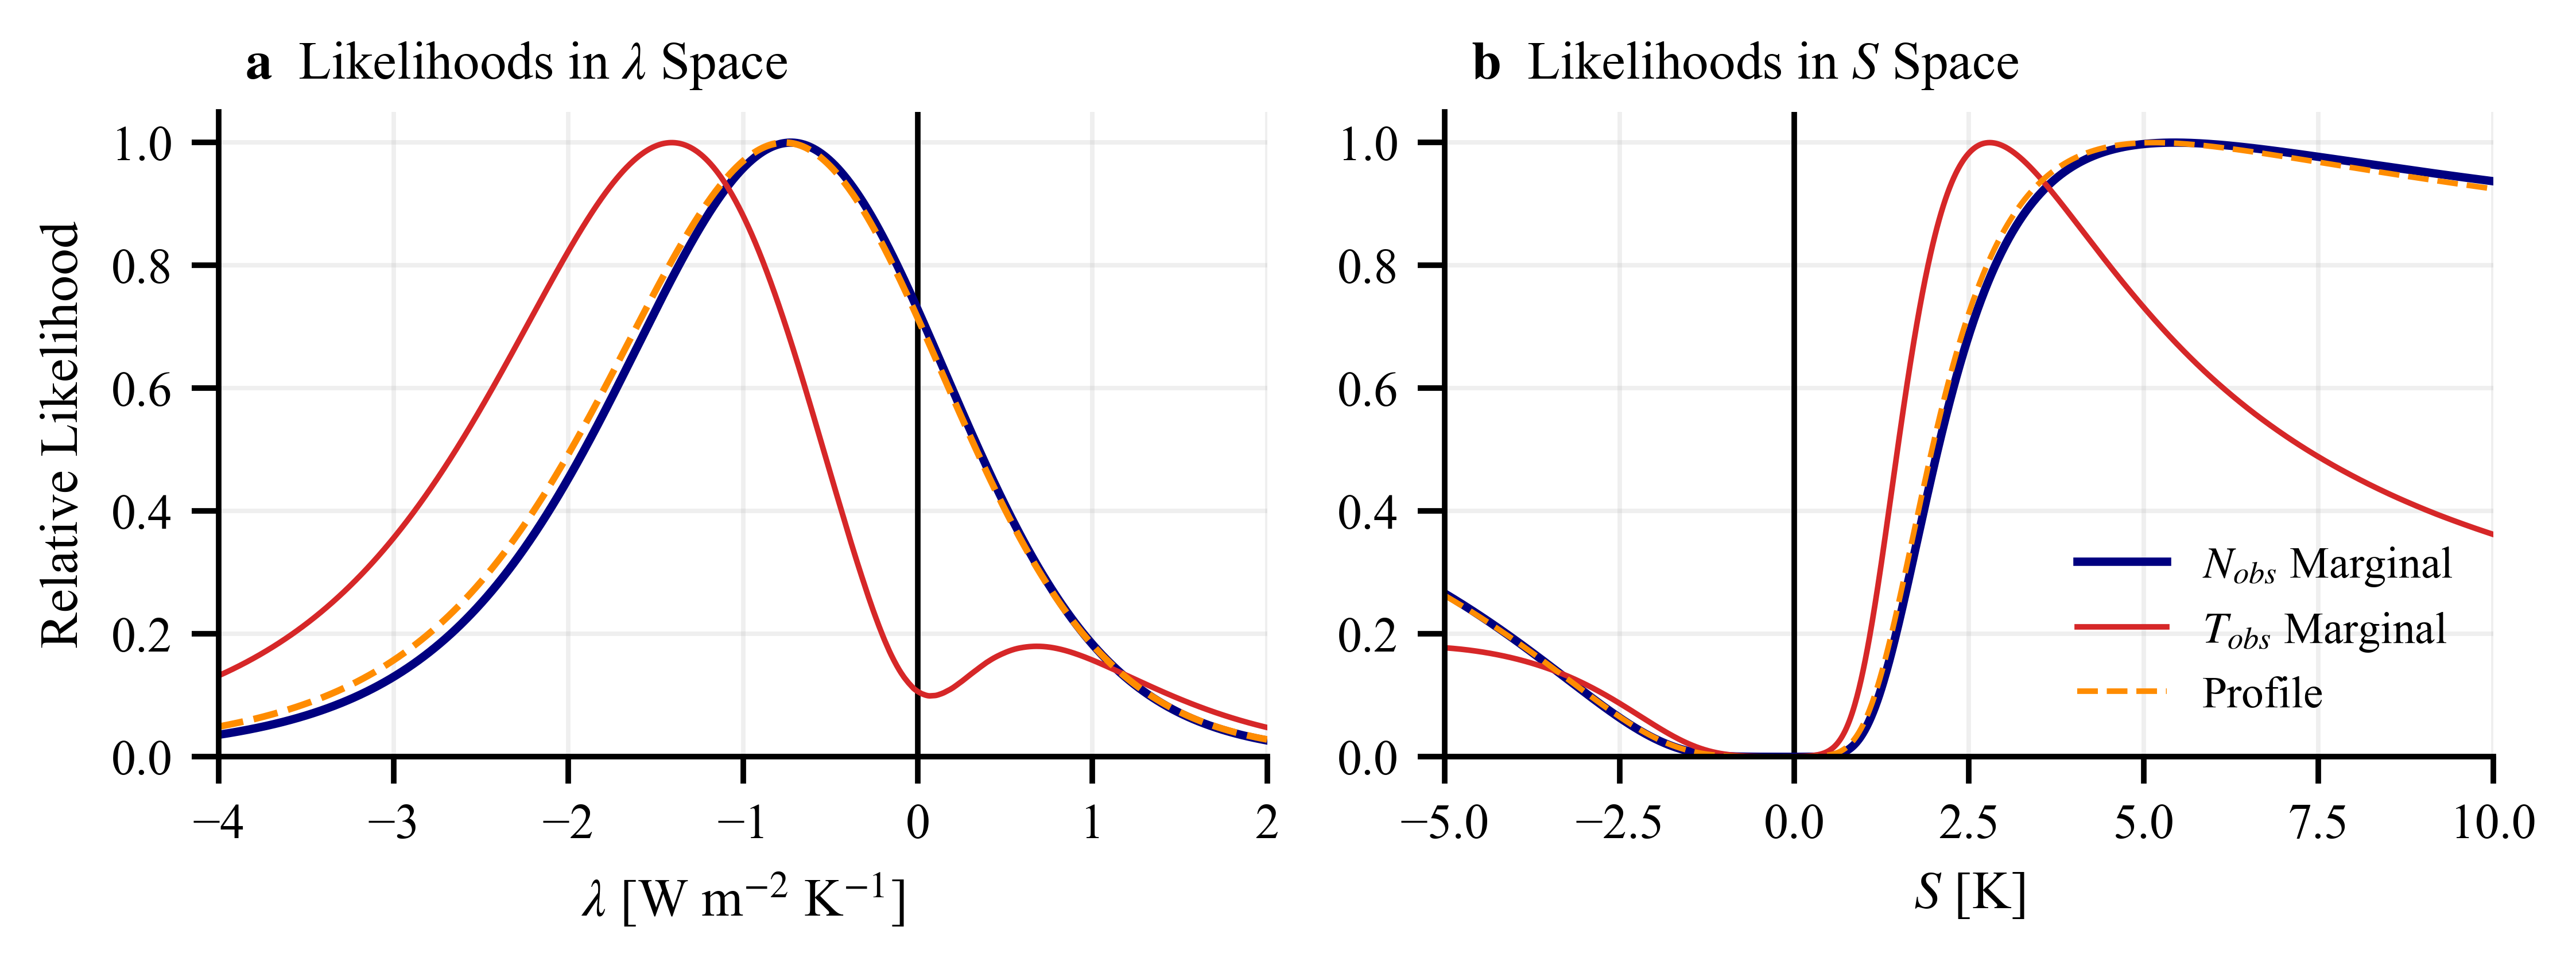

Modes


,lambda_mode_Wm2_K,S_mode_K
MC marginal Nobs,-0.726,5.438
analytic marginal Nobs,-0.728,5.428
profile,-0.762,5.149
MC marginal Tobs,-1.407,2.799


CPU times: user 2min 49s, sys: 263 ms, total: 2min 49s
Wall time: 3min 7s


In [363]:
%%time
## Diagnostic: lambda-space and S-space likelihoods

save = True

## controls
diagnostic_mc_n = 100_000
lam_grid_diag = np.linspace(-4, 2, 500)
S_grid_diag = np.r_[np.linspace(-5, -0.05, 250), np.linspace(0.05, 10, 500)]
dpis = 100

if save == True:
    dpis = 700
    diagnostic_mc_n = 500_000
    lam_grid_diag = np.linspace(-4, 2, 1000)
    S_grid_diag = np.r_[np.linspace(-5, -0.05, 200), np.linspace(0.05, 10, 1000)]
    
## inputs/draws
diagnostic_params = _trend_params(analysis_period, temp_key=analysis_temp_key)
draws = _draw_case_samples(
    diagnostic_params,
    analysis_dlamb_mu,
    analysis_dlamb_sig,
    mc_n=diagnostic_mc_n,
    iv_cov=analysis_iv_cov,
    temp_key=analysis_temp_key,
)

_eps = 1e-10
Fdot_mu = float(diagnostic_params["F_mu"])
Tdot_mu = float(diagnostic_params["T_mu"])
Ndot_mu = float(diagnostic_params["N_mu"])
dlamb_mu = float(analysis_dlamb_mu)

Fdot_sig = np.sqrt(diagnostic_params["F_sig"]**2 + Fdot_struct_sig**2)
Tdot_sig = float(np.maximum(draws["T_score_sig"], _eps))
Ndot_sig = float(np.maximum(draws["N_score_sig"], _eps))
dlamb_sig = float(np.maximum(abs(analysis_dlamb_sig), _eps))
F2x_sig = float(np.maximum(analysis_F2x_sig, _eps))


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


def _Tpred_from_lameff(lam_eff):
    out = np.full_like(lam_eff, np.nan, dtype=float)
    ok = np.abs(lam_eff) > 1e-8
    out[ok] = (draws["Ndot"][ok] - draws["Fdot"][ok]) / lam_eff[ok]
    return out


## -------------------------
## lambda-space likelihoods
## -------------------------
like_N_lam = np.zeros_like(lam_grid_diag)
like_T_lam = np.zeros_like(lam_grid_diag)

for i, lam in enumerate(lam_grid_diag):
    lam_eff = lam - draws["dlamb"]

    Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
    like_N_lam[i] = np.nanmean(norm.pdf(Ndot_mu, loc=Npred, scale=Ndot_sig))

    Tpred = _Tpred_from_lameff(lam_eff)
    like_T_lam[i] = np.nanmean(norm.pdf(Tdot_mu, loc=Tpred, scale=Tdot_sig))

like_N_lam = _rel(like_N_lam)
like_T_lam = _rel(like_T_lam)


def _neg_log_profile_lam(theta, lam):
    Tdot_true, Fdot_true, dlamb_true = theta
    Ndot_pred = Fdot_true + (lam - dlamb_true) * Tdot_true
    return -(
        norm.logpdf(Tdot_true, loc=Tdot_mu, scale=Tdot_sig)
        + norm.logpdf(Fdot_true, loc=Fdot_mu, scale=Fdot_sig)
        + norm.logpdf(dlamb_true, loc=dlamb_mu, scale=dlamb_sig)
        + norm.logpdf(Ndot_mu, loc=Ndot_pred, scale=Ndot_sig)
    )


profile_loglike_lam = np.full_like(lam_grid_diag, np.nan, dtype=float)
theta0 = np.array([Tdot_mu, Fdot_mu, dlamb_mu], dtype=float)

for i, lam in enumerate(lam_grid_diag):
    opt = minimize(_neg_log_profile_lam, theta0, args=(lam,), method="BFGS")
    profile_loglike_lam[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0 = opt.x

like_profile_lam = _rel(np.exp(profile_loglike_lam - np.nanmax(profile_loglike_lam)))


## analytic marginal in lambda space
n_gh = 100
xgh, wgh = np.polynomial.hermite.hermgauss(n_gh)

dlamb_nodes = dlamb_mu + np.sqrt(2) * dlamb_sig * xgh
dlamb_weights = wgh / np.sqrt(np.pi)

beta = lam_grid_diag[:, None] - dlamb_nodes[None, :]
Npred_mu = Fdot_mu + beta * Tdot_mu
Npred_sig = np.sqrt(Ndot_sig**2 + Fdot_sig**2 + (beta * Tdot_sig)**2)

like_analytic_lam = np.sum(
    dlamb_weights[None, :] * norm.pdf(Ndot_mu, loc=Npred_mu, scale=Npred_sig),
    axis=1,
)
like_analytic_lam = _rel(like_analytic_lam)


## -------------------------
## S-space likelihoods
## -------------------------
like_N_S = np.zeros_like(S_grid_diag)
like_T_S = np.zeros_like(S_grid_diag)

for i, S in enumerate(S_grid_diag):
    lam = -draws["F2x"] / S
    lam_eff = lam - draws["dlamb"]

    Npred = draws["Fdot"] + lam_eff * draws["Tdot"]
    like_N_S[i] = np.nanmean(norm.pdf(Ndot_mu, loc=Npred, scale=Ndot_sig))

    Tpred = _Tpred_from_lameff(lam_eff)
    like_T_S[i] = np.nanmean(norm.pdf(Tdot_mu, loc=Tpred, scale=Tdot_sig))

like_N_S = _rel(like_N_S)
like_T_S = _rel(like_T_S)


def _neg_log_profile_S(theta, S):
    Tdot_true, Fdot_true, dlamb_true, F2x_true = theta
    lam_true = -F2x_true / S
    Ndot_pred = Fdot_true + (lam_true - dlamb_true) * Tdot_true
    return -(
        norm.logpdf(Tdot_true, loc=Tdot_mu, scale=Tdot_sig)
        + norm.logpdf(Fdot_true, loc=Fdot_mu, scale=Fdot_sig)
        + norm.logpdf(dlamb_true, loc=dlamb_mu, scale=dlamb_sig)
        + norm.logpdf(F2x_true, loc=analysis_F2x_mu, scale=F2x_sig)
        + norm.logpdf(Ndot_mu, loc=Ndot_pred, scale=Ndot_sig)
    )


profile_loglike_S = np.full_like(S_grid_diag, np.nan, dtype=float)
theta0 = np.array([Tdot_mu, Fdot_mu, dlamb_mu, analysis_F2x_mu], dtype=float)

for i, S in enumerate(S_grid_diag):
    if i > 0 and np.sign(S_grid_diag[i]) != np.sign(S_grid_diag[i - 1]):
        theta0 = np.array([Tdot_mu, Fdot_mu, dlamb_mu, analysis_F2x_mu], dtype=float)

    opt = minimize(
        _neg_log_profile_S,
        theta0,
        args=(S,),
        method="L-BFGS-B",
        bounds=[(None, None), (None, None), (None, None), (_eps, None)],
    )
    profile_loglike_S[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0 = opt.x

like_profile_S = _rel(np.exp(profile_loglike_S - np.nanmax(profile_loglike_S)))


## analytic marginal in S space: integrates over F2x and dlambda with quadrature
F2x_nodes = analysis_F2x_mu + np.sqrt(2) * F2x_sig * xgh
F2x_weights = wgh / np.sqrt(np.pi)

like_analytic_S = np.zeros_like(S_grid_diag)

for i, S in enumerate(S_grid_diag):
    beta = -F2x_nodes[:, None] / S - dlamb_nodes[None, :]
    weights = F2x_weights[:, None] * dlamb_weights[None, :]

    Npred_mu = Fdot_mu + beta * Tdot_mu
    Npred_sig = np.sqrt(Ndot_sig**2 + Fdot_sig**2 + (beta * Tdot_sig)**2)

    like_analytic_S[i] = np.sum(
        weights * norm.pdf(Ndot_mu, loc=Npred_mu, scale=Npred_sig)
    )

like_analytic_S = _rel(like_analytic_S)


## insert a gap at S=0 so matplotlib does not connect across the singularity
gap_i = np.where(S_grid_diag < 0)[0][-1] + 1
S_plot = np.insert(S_grid_diag, gap_i, np.nan)

def _gap(y):
    return np.insert(y, gap_i, np.nan)


## plot
fig, axs = plt.subplots(1, 2, figsize=(6.5, 2.5), dpi=dpis)

axs[0].axvline(0, c="k", lw=1)
# axs[0].plot(lam_grid_diag, like_analytic_lam, label=r"$N_{obs}$ Marginal (Analytic)", ls="--", c="0.5", lw=1.0,zorder=4)
axs[0].plot(lam_grid_diag, like_N_lam, label=r"$N_{obs}$ Marginal", ls="-", c="navy", lw=1.5)
axs[0].plot(lam_grid_diag, like_T_lam, label=r"$T_{obs}$ Marginal", ls="-", c="tab:red", lw=1.0)
axs[0].plot(lam_grid_diag, like_profile_lam, label="Profile", ls="--", c="darkorange", lw=1.2)
axs[0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[0].set_ylabel("Relative Likelihood")
axs[0].set_title(r"  $\mathbf{a} \ \ $Likelihoods in $\lambda$ Space", loc='left')
axs[0].set_xlim(-4, 2)
axs[0].set_ylim(0, 1.05)
axs[0].grid(alpha=0.2)

axs[1].axvline(0, c="k", lw=1)
# axs[1].plot(S_plot, _gap(like_analytic_S), label=r"$N_{obs}$ Marginal (Analytic)", ls="--", c="0.5", lw=1.0,zorder=4)
axs[1].plot(S_plot, _gap(like_N_S), label=r"$N_{obs}$ Marginal", ls="-", c="navy", lw=1.5)
axs[1].plot(S_plot, _gap(like_T_S), label=r"$T_{obs}$ Marginal", ls="-", c="tab:red", lw=1.0)
axs[1].plot(S_plot, _gap(like_profile_S), label="Profile", ls="--", c="darkorange", lw=1.)
axs[1].set_xlabel(r"$S$ [K]")
axs[1].set_title(r"  $\mathbf{b} \ \ $Likelihoods in $S$ Space", loc='left')
axs[1].set_xlim(-5, 10)
axs[1].set_ylim(0, 1.05)
axs[1].grid(alpha=0.2)
axs[1].legend(frameon=False, fontsize="small")

sns.despine()
plt.tight_layout()

if save == True:
    # Save as PDF
    figpath = './figures/' + 'grl/'
    fname = 'fig_appendix_likelihood.pdf'
    if save == True:
        plt.savefig(figpath + fname, 
                    format='pdf', 
                    bbox_inches='tight',
                    dpi=dpis)
        print('saved ' + figpath + fname)

plt.show()

print("Modes")
display(
    pd.DataFrame(
        {
            "lambda_mode_Wm2_K": {
                "MC marginal Nobs": lam_grid_diag[np.nanargmax(like_N_lam)],
                "analytic marginal Nobs": lam_grid_diag[np.nanargmax(like_analytic_lam)],
                "profile": lam_grid_diag[np.nanargmax(like_profile_lam)],
                "MC marginal Tobs": lam_grid_diag[np.nanargmax(like_T_lam)],
            },
            "S_mode_K": {
                "MC marginal Nobs": S_grid_diag[np.nanargmax(like_N_S)],
                "analytic marginal Nobs": S_grid_diag[np.nanargmax(like_analytic_S)],
                "profile": S_grid_diag[np.nanargmax(like_profile_S)],
                "MC marginal Tobs": S_grid_diag[np.nanargmax(like_T_S)],
            },
        }
    ).round(3)
)

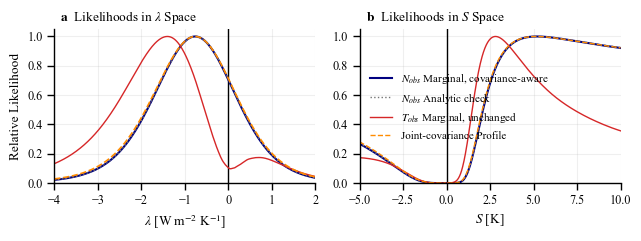

Covariance-aware modes


,lambda_mode_Wm2_K,S_mode_K
MC marginal Nobs,-0.766,5.194
analytic marginal Nobs,-0.754,5.234
profile,-0.766,5.155
MC marginal Tobs (unchanged),-1.403,2.822


CPU times: user 10.8 s, sys: 8.32 ms, total: 10.8 s
Wall time: 11.7 s


In [419]:
%%time
## Covariance-aware version of the likelihood-methods diagnostic above.
## The existing diagnostic cell is intentionally left unchanged for comparison.

from scipy.stats import multivariate_normal

save_covdiag = False
diagnostic_mc_n_cov = 100_000
lam_grid_covdiag = np.linspace(-4, 2, 500)
S_grid_covdiag = np.r_[np.linspace(-5, -0.05, 250), np.linspace(0.05, 10, 500)]
dpis_covdiag = 100

if save_covdiag:
    dpis_covdiag = 700
    diagnostic_mc_n_cov = 1_000_000
    lam_grid_covdiag = np.linspace(-4, 2, 4000)
    S_grid_covdiag = np.r_[np.linspace(-5, -0.05, 500), np.linspace(0.05, 10, 1000)]

params_covdiag = _trend_params(analysis_period, temp_key=analysis_temp_key)

## Fixed local seed makes the revised diagnostic reproducible without advancing analysis_rng.
_saved_analysis_rng_covdiag = analysis_rng
try:
    analysis_rng = np.random.default_rng(20260721)
    draws_covdiag = _draw_case_samples(
        params_covdiag,
        analysis_dlamb_mu,
        analysis_dlamb_sig,
        mc_n=diagnostic_mc_n_cov,
        iv_cov=analysis_iv_cov,
        temp_key=analysis_temp_key,
    )
finally:
    analysis_rng = _saved_analysis_rng_covdiag

_eps_covdiag = 1e-10
Fdot_mu_covdiag = float(params_covdiag["F_mu"])
Tdot_mu_covdiag = float(params_covdiag["T_mu"])
Ndot_mu_covdiag = float(params_covdiag["N_mu"])
dlamb_mu_covdiag = float(analysis_dlamb_mu)
Fdot_sig_covdiag = np.sqrt(params_covdiag["F_sig"]**2 + Fdot_struct_sig**2)
Tdot_sig_covdiag = float(np.maximum(draws_covdiag["T_score_sig"], _eps_covdiag))
Ndot_sig_covdiag = float(np.maximum(draws_covdiag["N_score_sig"], _eps_covdiag))
TN_cov_covdiag = float(draws_covdiag["TN_score_cov"])
dlamb_sig_covdiag = float(np.maximum(abs(analysis_dlamb_sig), _eps_covdiag))
F2x_sig_covdiag = float(np.maximum(analysis_F2x_sig, _eps_covdiag))

obs_cov_covdiag = np.array([
    [Tdot_sig_covdiag**2, TN_cov_covdiag],
    [TN_cov_covdiag, Ndot_sig_covdiag**2],
])
obs_covdiag = np.array([Tdot_mu_covdiag, Ndot_mu_covdiag])
N_adjust_covdiag, N_cond_sig_covdiag = _conditional_N_score_terms(
    params_covdiag, draws_covdiag
)

def _rel_covdiag(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


def _Tpred_covdiag(lam_eff):
    return np.where(
        np.abs(lam_eff) > _eps_covdiag,
        (draws_covdiag["Ndot"] - draws_covdiag["Fdot"]) / lam_eff,
        np.nan,
    )


## Lambda-space Monte Carlo marginal likelihoods. Score T is retained unchanged
## so this new cell isolates the covariance revision to the primary score-N model.
like_N_lam_covdiag = np.zeros_like(lam_grid_covdiag)
like_T_lam_covdiag = np.zeros_like(lam_grid_covdiag)
for i, lam in enumerate(lam_grid_covdiag):
    lam_eff = lam - draws_covdiag["dlamb"]
    Npred = draws_covdiag["Fdot"] + lam_eff * draws_covdiag["Tdot"]
    like_N_lam_covdiag[i] = np.nanmean(
        norm.pdf(Ndot_mu_covdiag, loc=Npred + N_adjust_covdiag, scale=N_cond_sig_covdiag)
    )
    Tpred = _Tpred_covdiag(lam_eff)
    like_T_lam_covdiag[i] = np.nanmean(
        norm.pdf(Tdot_mu_covdiag, loc=Tpred, scale=Tdot_sig_covdiag)
    )
like_N_lam_covdiag = _rel_covdiag(like_N_lam_covdiag)
like_T_lam_covdiag = _rel_covdiag(like_T_lam_covdiag)


## Covariance-aware profile likelihood: one bivariate T-N observation term.
def _neg_log_profile_lam_covdiag(theta, lam):
    Tdot_true, Fdot_true, dlamb_true = theta
    Ndot_pred = Fdot_true + (lam - dlamb_true) * Tdot_true
    pred = np.array([Tdot_true, Ndot_pred])
    return -(
        multivariate_normal.logpdf(obs_covdiag, mean=pred, cov=obs_cov_covdiag)
        + norm.logpdf(Fdot_true, loc=Fdot_mu_covdiag, scale=Fdot_sig_covdiag)
        + norm.logpdf(dlamb_true, loc=dlamb_mu_covdiag, scale=dlamb_sig_covdiag)
    )

profile_loglike_lam_covdiag = np.full_like(lam_grid_covdiag, np.nan, dtype=float)
theta0_covdiag = np.array([Tdot_mu_covdiag, Fdot_mu_covdiag, dlamb_mu_covdiag])
for i, lam in enumerate(lam_grid_covdiag):
    opt = minimize(_neg_log_profile_lam_covdiag, theta0_covdiag, args=(lam,), method="BFGS")
    profile_loglike_lam_covdiag[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0_covdiag = opt.x
like_profile_lam_covdiag = _rel_covdiag(
    np.exp(profile_loglike_lam_covdiag - np.nanmax(profile_loglike_lam_covdiag))
)


## Analytic score-N marginal. The cross term is the covariance correction.
n_gh_covdiag = 100
xgh_covdiag, wgh_covdiag = np.polynomial.hermite.hermgauss(n_gh_covdiag)
dlamb_nodes_covdiag = (
    dlamb_mu_covdiag + np.sqrt(2) * dlamb_sig_covdiag * xgh_covdiag
)
dlamb_weights_covdiag = wgh_covdiag / np.sqrt(np.pi)
beta_covdiag = lam_grid_covdiag[:, None] - dlamb_nodes_covdiag[None, :]
Npred_mu_covdiag = Fdot_mu_covdiag + beta_covdiag * Tdot_mu_covdiag
Npred_var_covdiag = (
    Ndot_sig_covdiag**2
    + Fdot_sig_covdiag**2
    + beta_covdiag**2 * Tdot_sig_covdiag**2
    - 2 * beta_covdiag * TN_cov_covdiag
)
Npred_sig_covdiag = np.sqrt(np.maximum(Npred_var_covdiag, _eps_covdiag))
like_analytic_lam_covdiag = np.sum(
    dlamb_weights_covdiag[None, :]
    * norm.pdf(Ndot_mu_covdiag, loc=Npred_mu_covdiag, scale=Npred_sig_covdiag),
    axis=1,
)
like_analytic_lam_covdiag = _rel_covdiag(like_analytic_lam_covdiag)


## S-space Monte Carlo marginal likelihoods.
like_N_S_covdiag = np.zeros_like(S_grid_covdiag)
like_T_S_covdiag = np.zeros_like(S_grid_covdiag)
for i, S in enumerate(S_grid_covdiag):
    lam = -draws_covdiag["F2x"] / S
    lam_eff = lam - draws_covdiag["dlamb"]
    Npred = draws_covdiag["Fdot"] + lam_eff * draws_covdiag["Tdot"]
    like_N_S_covdiag[i] = np.nanmean(
        norm.pdf(Ndot_mu_covdiag, loc=Npred + N_adjust_covdiag, scale=N_cond_sig_covdiag)
    )
    Tpred = _Tpred_covdiag(lam_eff)
    like_T_S_covdiag[i] = np.nanmean(
        norm.pdf(Tdot_mu_covdiag, loc=Tpred, scale=Tdot_sig_covdiag)
    )
like_N_S_covdiag = _rel_covdiag(like_N_S_covdiag)
like_T_S_covdiag = _rel_covdiag(like_T_S_covdiag)


def _neg_log_profile_S_covdiag(theta, S):
    Tdot_true, Fdot_true, dlamb_true, F2x_true = theta
    lam_true = -F2x_true / S
    Ndot_pred = Fdot_true + (lam_true - dlamb_true) * Tdot_true
    pred = np.array([Tdot_true, Ndot_pred])
    return -(
        multivariate_normal.logpdf(obs_covdiag, mean=pred, cov=obs_cov_covdiag)
        + norm.logpdf(Fdot_true, loc=Fdot_mu_covdiag, scale=Fdot_sig_covdiag)
        + norm.logpdf(dlamb_true, loc=dlamb_mu_covdiag, scale=dlamb_sig_covdiag)
        + norm.logpdf(F2x_true, loc=analysis_F2x_mu, scale=F2x_sig_covdiag)
    )

profile_loglike_S_covdiag = np.full_like(S_grid_covdiag, np.nan, dtype=float)
theta0_covdiag = np.array([
    Tdot_mu_covdiag, Fdot_mu_covdiag, dlamb_mu_covdiag, analysis_F2x_mu
])
for i, S in enumerate(S_grid_covdiag):
    if i > 0 and np.sign(S_grid_covdiag[i]) != np.sign(S_grid_covdiag[i - 1]):
        theta0_covdiag = np.array([
            Tdot_mu_covdiag, Fdot_mu_covdiag, dlamb_mu_covdiag, analysis_F2x_mu
        ])
    opt = minimize(
        _neg_log_profile_S_covdiag, theta0_covdiag, args=(S,),
        method="L-BFGS-B",
        bounds=[(None, None), (None, None), (None, None), (_eps_covdiag, None)],
    )
    profile_loglike_S_covdiag[i] = -opt.fun
    if np.all(np.isfinite(opt.x)):
        theta0_covdiag = opt.x
like_profile_S_covdiag = _rel_covdiag(
    np.exp(profile_loglike_S_covdiag - np.nanmax(profile_loglike_S_covdiag))
)


## Analytic covariance-aware score-N marginal in S space.
F2x_nodes_covdiag = analysis_F2x_mu + np.sqrt(2) * F2x_sig_covdiag * xgh_covdiag
F2x_weights_covdiag = wgh_covdiag / np.sqrt(np.pi)
like_analytic_S_covdiag = np.zeros_like(S_grid_covdiag)
for i, S in enumerate(S_grid_covdiag):
    beta = (
        -F2x_nodes_covdiag[:, None] / S - dlamb_nodes_covdiag[None, :]
    )
    weights = F2x_weights_covdiag[:, None] * dlamb_weights_covdiag[None, :]
    Npred_mu = Fdot_mu_covdiag + beta * Tdot_mu_covdiag
    Npred_var = (
        Ndot_sig_covdiag**2
        + Fdot_sig_covdiag**2
        + beta**2 * Tdot_sig_covdiag**2
        - 2 * beta * TN_cov_covdiag
    )
    like_analytic_S_covdiag[i] = np.sum(
        weights * norm.pdf(
            Ndot_mu_covdiag, loc=Npred_mu,
            scale=np.sqrt(np.maximum(Npred_var, _eps_covdiag)),
        )
    )
like_analytic_S_covdiag = _rel_covdiag(like_analytic_S_covdiag)


## Gap at S=0 prevents plotting across the singularity.
gap_i_covdiag = np.where(S_grid_covdiag < 0)[0][-1] + 1
S_plot_covdiag = np.insert(S_grid_covdiag, gap_i_covdiag, np.nan)

def _gap_covdiag(y):
    return np.insert(y, gap_i_covdiag, np.nan)


fig, axs = plt.subplots(1, 2, figsize=(6.5, 2.5), dpi=dpis_covdiag)
axs[0].axvline(0, c="k", lw=1)
axs[0].plot(
    lam_grid_covdiag, like_N_lam_covdiag,
    label=r"$N_{obs}$ Marginal, covariance-aware", c="navy", lw=1.5,
)
axs[0].plot(
    lam_grid_covdiag, like_analytic_lam_covdiag,
    label=r"$N_{obs}$ Analytic check", c="0.45", ls=":", lw=1.0,
)
axs[0].plot(
    lam_grid_covdiag, like_T_lam_covdiag,
    label=r"$T_{obs}$ Marginal, unchanged", c="tab:red", lw=1.0,
)
axs[0].plot(
    lam_grid_covdiag, like_profile_lam_covdiag,
    label="Joint-covariance Profile", c="darkorange", ls="--", lw=1.2,
)
axs[0].set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
axs[0].set_ylabel("Relative Likelihood")
axs[0].set_title(r"  $\mathbf{a} \ \ $Likelihoods in $\lambda$ Space", loc="left")
axs[0].set_xlim(-4, 2)
axs[0].set_ylim(0, 1.05)
axs[0].grid(alpha=0.2)

axs[1].axvline(0, c="k", lw=1)
axs[1].plot(
    S_plot_covdiag, _gap_covdiag(like_N_S_covdiag),
    label=r"$N_{obs}$ Marginal, covariance-aware", c="navy", lw=1.5,
)
axs[1].plot(
    S_plot_covdiag, _gap_covdiag(like_analytic_S_covdiag),
    label=r"$N_{obs}$ Analytic check", c="0.45", ls=":", lw=1.0,
)
axs[1].plot(
    S_plot_covdiag, _gap_covdiag(like_T_S_covdiag),
    label=r"$T_{obs}$ Marginal, unchanged", c="tab:red", lw=1.0,
)
axs[1].plot(
    S_plot_covdiag, _gap_covdiag(like_profile_S_covdiag),
    label="Joint-covariance Profile", c="darkorange", ls="--", lw=1.0,
)
axs[1].set_xlabel(r"$S$ [K]")
axs[1].set_title(r"  $\mathbf{b} \ \ $Likelihoods in $S$ Space", loc="left")
axs[1].set_xlim(-5, 10)
axs[1].set_ylim(0, 1.05)
axs[1].grid(alpha=0.2)
axs[1].legend(frameon=False, fontsize="small")
sns.despine()
plt.tight_layout()

if save_covdiag:
    figpath = "./figures/grl/"
    fname = "fig_appendix_likelihood_covariance.pdf"
    plt.savefig(figpath + fname, format="pdf", bbox_inches="tight", dpi=dpis_covdiag)
    print("saved " + figpath + fname)
plt.show()

print("Covariance-aware modes")
display(
    pd.DataFrame(
        {
            "lambda_mode_Wm2_K": {
                "MC marginal Nobs": lam_grid_covdiag[np.nanargmax(like_N_lam_covdiag)],
                "analytic marginal Nobs": lam_grid_covdiag[np.nanargmax(like_analytic_lam_covdiag)],
                "profile": lam_grid_covdiag[np.nanargmax(like_profile_lam_covdiag)],
                "MC marginal Tobs (unchanged)": lam_grid_covdiag[np.nanargmax(like_T_lam_covdiag)],
            },
            "S_mode_K": {
                "MC marginal Nobs": S_grid_covdiag[np.nanargmax(like_N_S_covdiag)],
                "analytic marginal Nobs": S_grid_covdiag[np.nanargmax(like_analytic_S_covdiag)],
                "profile": S_grid_covdiag[np.nanargmax(like_profile_S_covdiag)],
                "MC marginal Tobs (unchanged)": S_grid_covdiag[np.nanargmax(like_T_S_covdiag)],
            },
        }
    ).round(3)
)

### Likelihood model for CERES trend evidence

We treat the observed GMST and TOA imbalance trends as noisy estimates of latent true trends, while the forcing trend and pattern-effect correction are nuisance quantities. For a candidate feedback parameter $\lambda$, the model is

$$
\dot{T}_{\mathrm{obs}} \sim \mathcal{N}
\left(\dot{T}^{\ast}, \sigma_T\right)
$$

$$
\dot{F}^{\ast} \sim p(\dot{F}), \qquad
\Delta\lambda^{\ast} \sim p(\Delta\lambda)
$$

with the energy-budget constraint

$$
\dot{N}^{\ast}
=
\dot{F}^{\ast}
+
\left(\lambda - \Delta\lambda^{\ast}\right)
\dot{T}^{\ast}.
$$

The CERES trend is then scored as

$$
\dot{N}_{\mathrm{obs}} \sim \mathcal{N}
\left(\dot{N}^{\ast}, \sigma_N\right).
$$

Thus the marginal likelihood for $\lambda$ is

$$
L(\lambda)
=
\int
p\left(
\dot{N}_{\mathrm{obs}}
\mid
\dot{F}^{\ast}
+
(\lambda-\Delta\lambda^{\ast})\dot{T}^{\ast},
\sigma_N
\right)
p(\dot{T}^{\ast}\mid \dot{T}_{\mathrm{obs}},\sigma_T)
p(\dot{F}^{\ast})
p(\Delta\lambda^{\ast})
\,d\dot{T}^{\ast}\,d\dot{F}^{\ast}\,d\Delta\lambda^{\ast}.
$$

In practice, this integral is evaluated by Monte Carlo sampling over the nuisance quantities $\dot{T}^{\ast}$, $\dot{F}^{\ast}$, and $\Delta\lambda^{\ast}$, and averaging the resulting normal likelihood for $\dot{N}_{\mathrm{obs}}$.

Primary: joint latent N,T generative likelihood
Implementation: sample latent T, F, delta lambda; score observed N

Then show sensitivities to:
1. score-N / latent-T vs score-T
2. direct implied-lambda Monte Carlo diagnostic
3. uniform lambda vs uniform S vs log-uniform prior
4. 2001-2024 vs 2006-2024 vs 2006-2023
5. internal variability covariance included/excluded, CESM2 vs MPI vs average
6. forcing structural uncertainty choices
7. delta-lambda prior mean and width

   I would phrase it this way in the paper: both \(N\) and \(T\) are observed, but \(T\) enters as a latent true trend constrained by observations, while \(N\) is the budget-predicted quantity scored against CERES. This is the generative joint likelihood for the observed \((T,N)\), not an arbitrary choice to privilege \(N\)

# New scratch

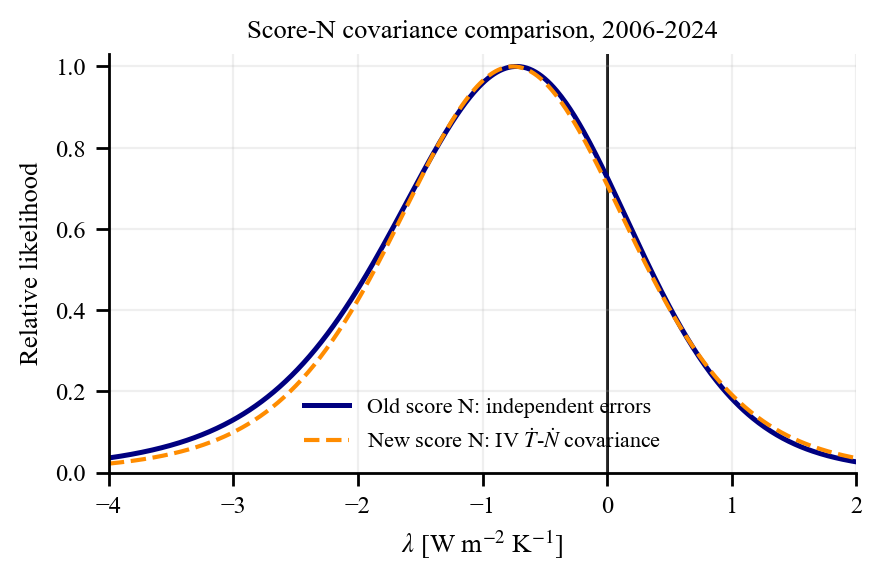

,method,lambda_mode_Wm2_K
0,Old independent score N,-0.7295
1,New covariance-aware score N,-0.7535


IV covariance = -0.002970; total-error correlation = -0.206; conditional N sigma = 0.1997


In [413]:
sns.set_context('paper')
## Isolate the effect of the off-diagonal Tdot-Ndot internal-variability covariance
## on the Monte Carlo score-N likelihood in lambda space.

comparison_mc_n = analysis_mc_n
comparison_lam_grid = np.linspace(-4.0, 2.0, 500)
comparison_uncertainty_scale = 1.0
comparison_seed = 20260721

comparison_params = _trend_params(analysis_period, temp_key=analysis_temp_key)

## Use a local, reproducible RNG while preserving the state of the notebook's global RNG.
_saved_analysis_rng = analysis_rng
try:
    analysis_rng = np.random.default_rng(comparison_seed)
    comparison_draws = _draw_case_samples(
        comparison_params,
        analysis_dlamb_mu,
        analysis_dlamb_sig,
        uncertainty_scale=comparison_uncertainty_scale,
        mc_n=comparison_mc_n,
        iv_cov=analysis_iv_cov,
        temp_key=analysis_temp_key,
    )
finally:
    analysis_rng = _saved_analysis_rng

## Independent observational/trend-estimation errors contribute only to the diagonal.
## The off-diagonal term comes only from the piControl internal-variability covariance.
comparison_obs_cov = comparison_uncertainty_scale**2 * (
    np.diag([comparison_params["T_sig"]**2, comparison_params["N_sig"]**2])
    + analysis_iv_cov
)

var_T = comparison_obs_cov[0, 0]
var_N = comparison_obs_cov[1, 1]
cov_TN = comparison_obs_cov[0, 1]
conditional_N_slope = cov_TN / var_T
conditional_N_var = var_N - cov_TN**2 / var_T
if conditional_N_var <= 0:
    raise ValueError("The Tdot-Ndot observational covariance is not positive definite.")
conditional_N_sig = np.sqrt(conditional_N_var)

## These checks ensure the comparison uses exactly the same marginal error variances
## as the existing score-N implementation.
assert np.isclose(var_T, comparison_draws["T_score_sig"]**2)
assert np.isclose(var_N, comparison_draws["N_score_sig"]**2)

like_N_old = np.zeros_like(comparison_lam_grid)
like_N_cov = np.zeros_like(comparison_lam_grid)

T_departure = comparison_draws["Tdot"] - comparison_params["T_mu"]
for i, lam in enumerate(comparison_lam_grid):
    beta = lam - comparison_draws["dlamb"]
    Npred = comparison_draws["Fdot"] + beta * comparison_draws["Tdot"]

    ## Existing method: treat the full N error as independent of the sampled T error.
    like_N_old[i] = np.nanmean(
        norm.pdf(
            comparison_params["N_mu"],
            loc=Npred,
            scale=comparison_draws["N_score_sig"],
        )
    )

    ## Covariance-aware method. Since Tdot - Tobs is the negative T error,
    ## E[N_error | Tdot] = -Cov(T,N)/Var(T) * (Tdot - Tobs).
    Npred_conditional = Npred - conditional_N_slope * T_departure
    like_N_cov[i] = np.nanmean(
        norm.pdf(
            comparison_params["N_mu"],
            loc=Npred_conditional,
            scale=conditional_N_sig,
        )
    )

like_N_old_rel = like_N_old / np.nanmax(like_N_old)
like_N_cov_rel = like_N_cov / np.nanmax(like_N_cov)

fig, ax = plt.subplots(figsize=(4.5, 3.0), dpi=200)
ax.axvline(0, color="k", lw=1.0, zorder=0)
ax.plot(
    comparison_lam_grid, like_N_old_rel,
    color="navy", lw=1.8, label="Old score N: independent errors",
)
ax.plot(
    comparison_lam_grid, like_N_cov_rel,
    color="darkorange", lw=1.5, ls="--",
    label=r"New score N: IV $\dot{T}$-$\dot{N}$ covariance",
)
ax.set_xlabel(r"$\lambda$ [W m$^{-2}$ K$^{-1}$]")
ax.set_ylabel("Relative likelihood")
ax.set_title(f"Score-N covariance comparison, {_period_label(analysis_period)}")
ax.set_xlim(-4, 2)
ax.set_ylim(0, 1.03)
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize="small")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "method": ["Old independent score N", "New covariance-aware score N"],
            "lambda_mode_Wm2_K": [
                comparison_lam_grid[np.nanargmax(like_N_old)],
                comparison_lam_grid[np.nanargmax(like_N_cov)],
            ],
        }
    ).round(4)
)
print(
    f"IV covariance = {cov_TN:.6f}; "
    f"total-error correlation = {cov_TN / np.sqrt(var_T * var_N):.3f}; "
    f"conditional N sigma = {conditional_N_sig:.4f}"
)